In [2]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from tools import *
from fit_funcs import *
from entropy import *
import costfun.costfun as cost
import utils.figures as fig_help
from RandomMatrixTheory import goe
import utils.tools as tools

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'cm'
# plt.rcParams["mathtext.fontset"] = "cm"
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

linestyle_ls = ['-','--',':', '-.']
linestyle = itertools.cycle(linestyle_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   
from scipy import stats

# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import lambertw
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import splrep, splev
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import interp1d
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import fsolve

from mpl_toolkits.axes_grid1 import make_axes_locatable

# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists


config_disorder = 0
scaled_disorder = 0

if config_disorder:
    base_dir = "../results_conf_dis/"
else:
    base_dir = "../results/"

print(base_dir[2:])
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}


/Users/rafal.swietek/Projects/CODES/QHamSolver/QuantumSun/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
/results/


In [ ]:
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,2), dpi = 200)
axis.set_axis_off()

def func(x, x0, a, b, c):
    return a*(x-x0)**2 + b*(x-x0)**4 + c*x

x = np.linspace(0, 1, 1000)
res = 0
for aa in range(10):
    x0 = a/10.
    a = random.random()
    b = random.random()
    c = random.random()
    print(x0)
    res += func(x, x0, a, b, c)
axis.plot(x, res)

1.1**13
    

1) Peak vs $\alpha$ of Sz (show other operators)

2) Show no ETH at critical point for $S^z_L$ for diagonals and low-$\omega$ offdiagonals

3) Peak vs $\bar{E}$ or $\beta$ at fixed alfa (mobility edge) of $S^z_L$ (best operator)

4) High precision of location of peak (inset -- zoom). How close to $\alpha_c$ from other measures

5) Scaling of the peak for both cases

## RUN AGP.PY

In [ ]:
#!/usr/bin/python -u

#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

import costfun.costfun as cost
import utils.figures as fig_help
from tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

colors_ls = (list(mcolors.TABLEAU_COLORS)[:120])
colors_ls_cyc = itertools.cycle(colors_ls)
markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import lambertw
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

from scipy import stats

from joblib import Parallel, delayed

if __name__ == '__main__':
    L=8
    J=1.0
    gamma=1
    alfa=1.0
    h=1.0
    w=0.5
    zeta=0.2
    N=3
    ini_ave=1
    scaled_disorder=0

    N=int(sys.argv[1])
    J=float(sys.argv[2])
    scaled_dis = int(sys.argv[3])
    # op = int(sys.argv[6])

    # op_names = ["", "Sx_dot_Sx_last", "Sz_dot_Sz_last", "SzSz_last"]
    # op_name  = op_names[op]

    conf_disorder = False
    base_dir = "../results_conf_dis/" if conf_disorder else "../results/"
    
    num_realis = 20000
    def loop_body(Lx, alfa):
        
        L = Lx
        dim = 2**(L + N)
        
        alfa = np.round(alfa, 6)
        
        counter = 0
        cutoffs = np.logspace(-5, 0, 200)
        
        susc     = np.zeros(cutoffs.shape)
        susc_typ = np.zeros(cutoffs.shape)
        
        print(info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', scaled_disorder=scaled_disorder), flush=True)
        realizations = []
        energy = []
        for real in range(num_realis):
            name = base_dir + 'AGP/CUTOFF/realisation=%d/'%real + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ini_ave=ini_ave, scaled_disorder=scaled_disorder, ext='.hdf5')
            if exists(name):
                try:
                    with h5py.File(name, "r") as file:
                        try:
                            realizations.append(real)
                            
                            E   = np.array(file.get('energies')[0])
                            dE = E[-1] - E[0]
                            Ex = (E - E[0]) / dE
                            energy = [*energy, *Ex]
                            
                            # REGULAR AGP NORMS
                            cutoffs   = np.array(file.get('cutoff')[0])
                            susc     += np.array(file.get('susc')[0])
                            susc_typ += np.array(file.get('susc_typ')[0])
                            
                            counter += 1
                        except TypeError:
                            print("Sth is missing or else shit! realis = ", real, flush=True)
                except OSError:
                    print("Corrupted file! realis = ", real, flush=True)
        # DENSITY OF STATES
        DOS, edges = np.histogram( np.array(energy), bins = 100)
        print(L, alfa, counter, realizations, flush=True)
        if counter > 0:
            stddev = np.array(stddev)
            bandwidth = np.array(bandwidth)
            name = base_dir + 'AGP/CUTOFF/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ini_ave=ini_ave, scaled_disorder=scaled_disorder, ext='.hdf5')
            
            hf = h5py.File(name, 'w')
            hf['realisations'] = counter

            hf.create_dataset('cutoff', cutoffs.shape, data = cutoffs)
            hf.create_dataset('susc', susc.shape, data = susc / counter)
            hf.create_dataset('susc_typ', susc_typ.shape, data = susc_typ / counter)
            
            hf.create_dataset('DOS', 	        DOS.shape, 	          data = DOS)
            hf.create_dataset('edges', 	        edges.shape, 	      data = edges)

            hf.close()


    L = int(sys.argv[4]);
    alfa = float(sys.argv[5]);
    loop_body(L, alfa)

    L = int(sys.argv[4]);
    alfa = float(sys.argv[5]);
    loop_body(L, alfa)

# TESTS

AA [0.0, 0.1112, 0.1624, 0.1979, 0.2258, 0.2493, 0.2697, 0.2879, 0.3045, 0.3199, 0.3343, 0.3479, 0.3608, 0.3732, 0.3851, 0.3965, 0.4077, 0.4186, 0.4292, 0.4397, 0.45, 0.4601, 0.4702, 0.4802, 0.4901, 0.5, 0.5099, 0.5198, 0.5298, 0.5399, 0.55, 0.5603, 0.5708, 0.5814, 0.5923, 0.6035, 0.6149, 0.6268, 0.6392, 0.6521, 0.6657, 0.6801, 0.6955, 0.7121, 0.7303, 0.7507, 0.7742, 0.8021, 0.8376, 0.8888, 1.0]
51
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


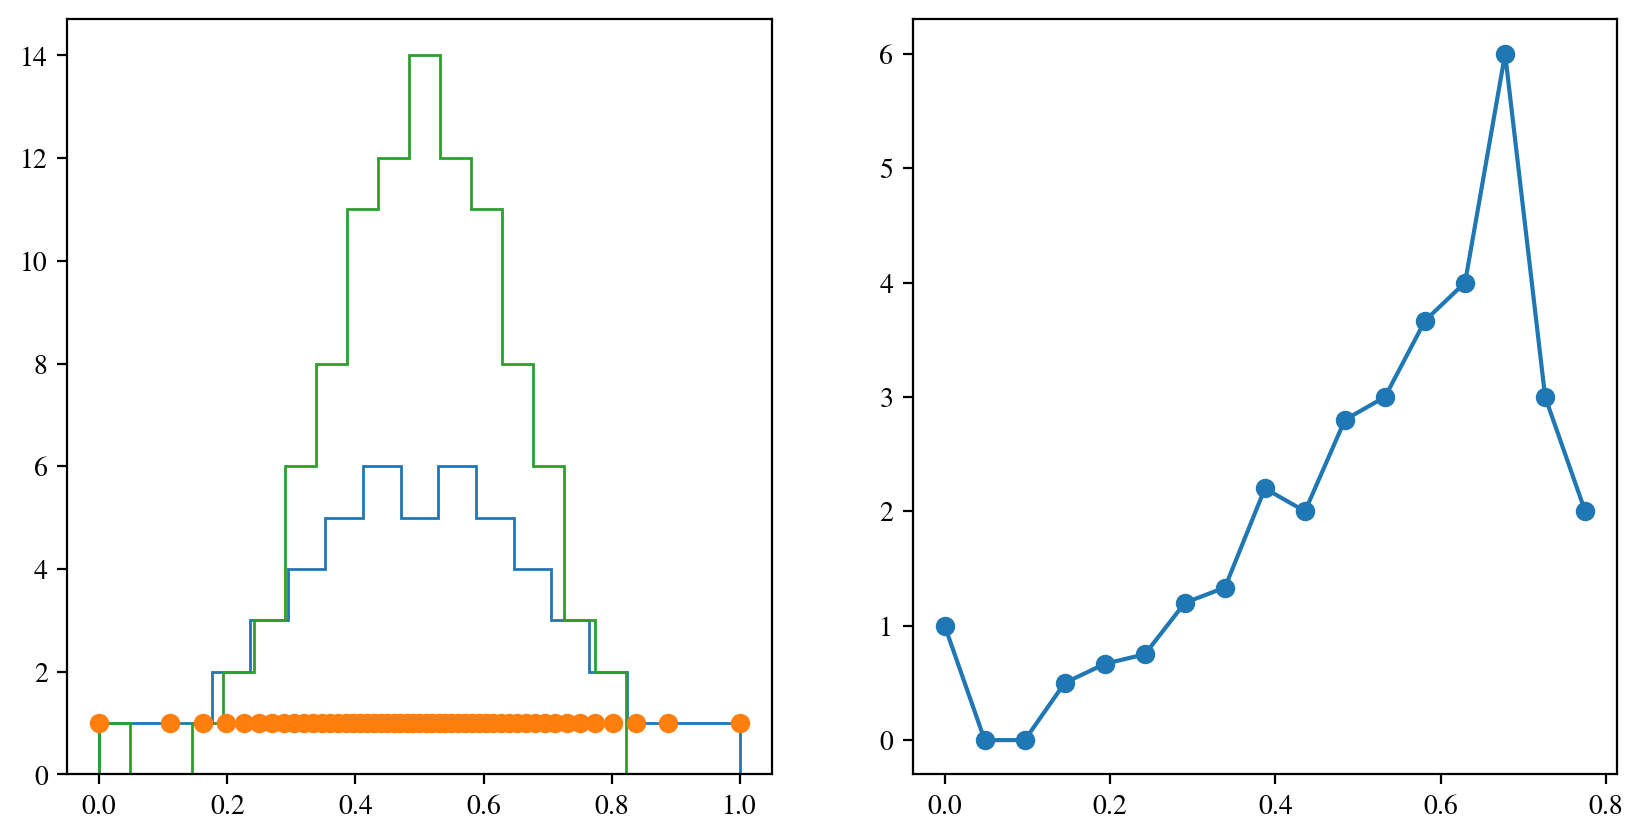

In [26]:

fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(10,5), dpi = 200)

x = [0.0, 0.184, 0.219, 0.241, 0.259, 0.273, 0.285, 0.296, 0.305, 0.314, 0.323, 0.33, 0.338, 0.344, 0.351, 0.357, 0.363, 0.369, 0.374, 0.38, 0.385, 0.39, 0.395, 0.4, 0.404, 0.409, 0.413, 0.418, 0.422, 0.426, 0.431, 0.435, 0.439, 0.443, 0.447, 0.451, 0.455, 0.459, 0.462, 0.466, 0.47, 0.474, 0.477, 0.481, 0.485, 0.488, 0.492, 0.496, 0.499, 0.503, 0.507, 0.51, 0.514, 0.518, 0.521, 0.525, 0.529, 0.532, 0.536, 0.54, 0.543, 0.547, 0.551, 0.555, 0.559, 0.563, 0.566, 0.57, 0.574, 0.578, 0.582, 0.587, 0.591, 0.595, 0.599, 0.604, 0.608, 0.613, 0.618, 0.622, 0.627, 0.633, 0.638, 0.643, 0.649, 0.655, 0.661, 0.667, 0.674, 0.681, 0.688, 0.697, 0.705, 0.715, 0.725, 0.737, 0.751, 0.768, 0.79, 0.823]

dist = stats.norm(loc=0.5, scale=0.2)
bounds = dist.cdf([0, 1])
pp = np.linspace(*bounds, num=51)
vals = np.round(dist.ppf(pp), 4)

hist, bins = np.histogram(vals, bins=17)

axis[0].stairs(hist, bins)
print( "AA", [*vals] )
print(len(vals))
axis[0].plot(vals, [1]*vals.size, 'o')

hist2, bins2 = np.histogram(x, bins=17)
axis[0].stairs(hist2, bins2)

y = hist2 / hist
indices = np.transpose(np.argwhere(~np.isnan(y)))[0]
print(indices)

axis[1].plot(bins2[:-1], y, marker='o')



In [ ]:
L_total=15

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745

alfa_vals = np.arange(0.6, 1., 0.01)
print(alfa_vals)


dim = 2**L_total
fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(10,5), dpi = 200)

_beta_ = np.arange(0, 2., 0.2)
_eps_  = np.arange(0.14, 0.52, 0.04)

# create a ScalarMappable and initialize a data structure
s_m_T = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(_beta_), vmax=max(_beta_) ))
s_m_T.set_array([])

s_m_E = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(_eps_), vmax=max(_eps_) ))
s_m_E.set_array([])
for jj in range(_beta_.size):
    beta = _beta_[jj]
    eps = _eps_[jj]
    col1 = s_m_T.to_rgba(beta)
    col2 = s_m_E.to_rgba(eps)
    
    agp1      = np.zeros((alfa_vals.size)); agp1.fill(np.nan)
    agp2      = np.zeros((alfa_vals.size)); agp2.fill(np.nan)
    for ii, alfa in enumerate(alfa_vals):
        name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    
        if exists(name):
            with h5py.File(name, "r") as file:
                R = np.array(file.get('realisations'))
                betas = np.array(file.get('betas'))
                idx1 = min(range(len(betas)), key=lambda i: abs(betas[i] - beta))
                Z = np.array(file.get('Z'))[idx1]
                agp1[ii] = np.array(file.get('susc_T_reg'))[idx1]
                
                E = np.array(file.get('energy_density'))
                idx2 = min(range(len(E)), key=lambda i: abs(E[i] - eps))
                DOS = ( np.array(file.get('DOS'))[idx2] + np.array(file.get('DOS'))[idx2+1] ) / 2 / R
                count = np.array(file.get('count'))[idx2] / R
                agp2[ii] = np.array(file.get('susc_E_r_typ'))[idx2] / R / DOS
        else:
            print(name)

    wH = np.sqrt(2**(N-1) * 0.3 + J**2 / 4 * ( (alfa_vals**(2*L+2) - alfa_vals**2) / (alfa_vals**2 - 1) ) + L / 4 * (1 + (w)**2 / 3)) / (0.3413 * dim)
    eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
    matelem = dim ** (-1/eta)
    norm = dim#max(agp2)#matelem**2 / wH**2
    axis[0].plot(alfa_vals, agp1 / norm, color=col1, marker='o', markersize=2)
    axis[1].plot(alfa_vals, agp2 / norm, color=col2, marker='o', markersize=2)

for ax in axis:
    ax.axvline(x=1/np.sqrt(2), ls=':', c='gray')
    ax.axvline(x=alfa_crit,    ls='--', c='k')
    
fig_help.set_plot_elements(axis[0], ylabel=r"$||\mathcal{A}_\lambda(\beta)||^2/D$",    xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$||\mathcal{A}_\lambda(\epsilon)||^2/D$", xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear', yscale='log')

divider = make_axes_locatable(axis[0])
cax = divider.new_vertical(size = '3%', pad = 0.05)
fig.add_axes(cax)
cbar = fig.colorbar(s_m_T, cax = cax, orientation = 'horizontal')
cax.xaxis.set_ticks_position('top')
cax.xaxis.set_label_position('top')
cbar.set_label(r"$\beta$", fontsize=16)

divider = make_axes_locatable(axis[1])
cax = divider.new_vertical(size = '3%', pad = 0.05)
fig.add_axes(cax)
cbar = fig.colorbar(s_m_E, cax = cax, orientation = 'horizontal')
cax.xaxis.set_ticks_position('top')
cax.xaxis.set_label_position('top')
cbar.set_label(r"$\epsilon$", fontsize=16)
fig.subplots_adjust(wspace = 0.23, hspace=0.13)

In [ ]:
L_total=14

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745
window=4
projected = 0

alfa_vals = np.arange(0.6, 1., 0.005)
print(alfa_vals)

alfa_plot = np.arange(0.71, 0.93, 0.01)

alfa_plot = [0.95]
dim = 2**L_total
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,5), dpi = 200)

alfa = 0.85

sizes = np.arange(10, 14, 1) - N
# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm= matplotlib.colors.Normalize(vmin=min(alfa_plot), vmax=max(alfa_plot) ))
s_m.set_array([])

for alfa in alfa_plot:
    col = s_m.to_rgba(alfa)
    agp1 = None
    agp2 = None
    name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    

    wH = np.sqrt(2**(N-1) * 0.3 + J**2 / 4 * ( (alfa_vals**(2*L+2) - alfa_vals**2) / (alfa_vals**2 - 1) ) + L / 4 * (1 + (w)**2 / 3)) / (0.3413 * dim)
    eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
    matelem = dim ** (-1/eta)
    norm = 1#matelem**2 / wH**2
    if exists(name):
        with h5py.File(name, "r") as file:
            Z = np.array(file.get('Z'))
            betas = np.array(file.get('betas'))
            energies = np.array(file.get('average energies'))
            Emean = np.array(file.get('mean_energy'))
            Emean = (Emean - energies[0]) / (energies[-1] - energies[0])
            
            R = np.array(file.get('realisations'))
            print(alfa, R)
            E = np.array(file.get('energy_density'))
            R = np.array(file.get('realisations'))
            DOS = np.array(file.get('DOS')) / R
            
            wH = np.array(file.get('wH_density'))
            
            count = np.array(file.get('count'))
            agp = np.array(file.get('susc_E_r_typ')) / R
            # agp = agp / count# / DOS**(1/eta)
            
            # agp = tools.remove_fluctuations(agp, bucket_size=window)[window//2:-window//2]
            # E = E[window//2:-window//2]
            
            axis.plot(E, agp, color=col, marker='o', markersize=2)
            
            count = np.array(file.get('Z'))
            agp = np.array(file.get('susc_T_reg'))
            axis.plot(Emean, agp, color=col, marker='s', markersize=3, markerfacecolor='None')
    else:
        print(name)
ylab = r"$||\mathcal{A}_\lambda(\epsilon)||^2\cdot D^{\frac{1}{\eta}}/\rho(\epsilon)$"# if projected else r"$||\mathcal{A}_\lambda(\epsilon)||^2\cdot D^{\frac{1}{\eta}}$"
fig_help.set_plot_elements(axis, ylabel=ylab, xlabel=r"$\epsilon$", font_size=16, set_legend=False, xscale='linear', yscale='linear')

fig.subplots_adjust(top=0.92)
cbar_ax = fig.add_axes([0.15, 0.95, 0.7, 0.04])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$\alpha$", fontsize=16)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')


fig.subplots_adjust(wspace = 0.23, hspace=0.13)

In [ ]:
L_total=15

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745

window = 6
projected = 1

alfa_vals = np.arange(0.7, 1., 0.01)
print(alfa_vals)

sizes = np.arange(8, 14, 1)
dim = 2**L_total
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)
# inset = axis.inset_axes([0.03, 0.03, 0.5, 0.45])

s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) ))
s_m.set_array([])
eps = 0.5
alfa_c = []
for jj, L in enumerate(sizes):
    dim = 2**(L+N)
    col2 = s_m.to_rgba(L)
    # print(eps)
    agp      = np.zeros((alfa_vals.size)); agp.fill(np.nan)
    for ii, alfa in enumerate(alfa_vals):
        eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
        name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    
        if exists(name):
            with h5py.File(name, "r") as file:
                R = np.array(file.get('realisations'))
                E = np.array(file.get('energy_density'))
                # print(indices)
                idx = min(range(len(E)), key=lambda i: abs(E[i] - eps))
                count = np.array(file.get('count'))[idx] / R
                _agp = np.array(file.get('susc_E_r_typ'))[idx] / R
                wH = np.array(file.get('wH_density'))[idx]
                
                DOS = np.mean( np.array(file.get('DOS'))[idx] ) / R
                # wH = 1/dim
                norm = dim**(-2/eta) * dim**2 if alfa >= alfa_crit else dim**2
                # norm = dim
                # agp[ii] = _agp[idx] / count[idx] / norm[idx2]
                agp[ii] = (_agp) / norm
        else:
            print(name)

    wH = np.sqrt(2**(N-1) * 0.3 + J**2 / 4 * ( (alfa_vals**(2*L+2) - alfa_vals**2) / (alfa_vals**2 - 1) ) + L / 4 * (1 + (w)**2 / 3)) / (0.3413 * dim)
    
    axis.plot(alfa_vals, agp, color=col2, marker='o', markersize=2)

axis.axvline(x=1/np.sqrt(2), ls='-', c='gray')
axis.axvline(x=alfa_crit,    ls=':', c='k')

ylab = ""#r"$||\mathcal{A}_\lambda(\epsilon)||^2/\rho(\epsilon)$"# if projected else r"$||\mathcal{A}_\lambda(\epsilon)||^2$"
fig_help.set_plot_elements(axis, ylabel=ylab, xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear', yscale='log')

divider = make_axes_locatable(axis)
cax = divider.new_vertical(size = '3%', pad = 0.05)
fig.add_axes(cax)
cbar = fig.colorbar(s_m, cax = cax, orientation = 'horizontal')
cax.xaxis.set_ticks_position('top')
cax.xaxis.set_label_position('top')
cbar.set_label(r"$L$", fontsize=16)
fig.subplots_adjust(wspace = 0.23, hspace=0.13)



In [ ]:
sizes = np.arange(8, 17, 1)
reals = [10000, 10000, 10000, 10000, 10000, 6000, 5000, 2000, 500]
datasize = 0
base = 50
for ii, L in enumerate(sizes):
    datasize += base * 2**(L - 8) * reals[ii]
print(datasize / 1e6)

In [ ]:
markers_ls2 = ['s','o', 'D', '<', 'X', '^', '*', '+']
markers2 = itertools.cycle(markers_ls2)
colors_ls_cyc = itertools.cycle(colors_ls)

L_total=14

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.74

alfa_vals = np.arange(0.6, 1., 0.01)
print(alfa_vals)


TYPICAL = 0


sizes = np.arange(10, 17, 1) - N

# create a ScalarMappable and initialize a data structure

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

dim = 2**(L+N)
susc = np.zeros((alfa_vals.size, 9)); susc.fill(np.nan)
norm = np.zeros((alfa_vals.size)); norm.fill(np.nan)
for ii, alfa in enumerate(alfa_vals):
    name = base_dir + 'AGP/CUTOFF/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
    
    if exists(name):
        with h5py.File(name, "r") as file:
            wHx = 1/dim
            
            norm[ii] = (1/wHx)**(-2 / eta) / wHx**2 if alfa >= alfa_crit else 1/wHx**2
            susc[ii] = np.array(file.get('susc_typ')) / dim if TYPICAL else np.array(file.get('susc')) / dim
            cutoff = np.array(file.get('cutoff'))
    else:
        print(name)
        
# s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm = matplotlib.colors.Normalize(vmin=min(sizes),vmax=max(sizes)) )
# s_m.set_array([])    

dim = 2**(L+N)
for iim, mu in enumerate(cutoff):
    yy = susc[:,iim]
    power = np.log(mu * dim) / np.log(L+N)
    axis.plot(alfa_vals, yy / yy[-1], marker=next(markers), label=r"$\mu=L^{%g}/D$"%(np.round(power, order_of_magnitude(power))))
    
fig_help.set_plot_elements(axis, ylabel=r"normalized $\chi^{\rm typ}$" if TYPICAL else r"normalized $\chi^{\rm av}$", xlabel=r"$\alpha$", font_size=16, set_legend=True, xscale='linear', yscale='log')
fig_help.set_legend(axis, fontsize=14, loc='upper left', anchor=(1.0, 1.02))

[0.5  0.51 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63
 0.64 0.65 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77
 0.78 0.79 0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91
 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99]
5 [7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 7500.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 10000.0, 

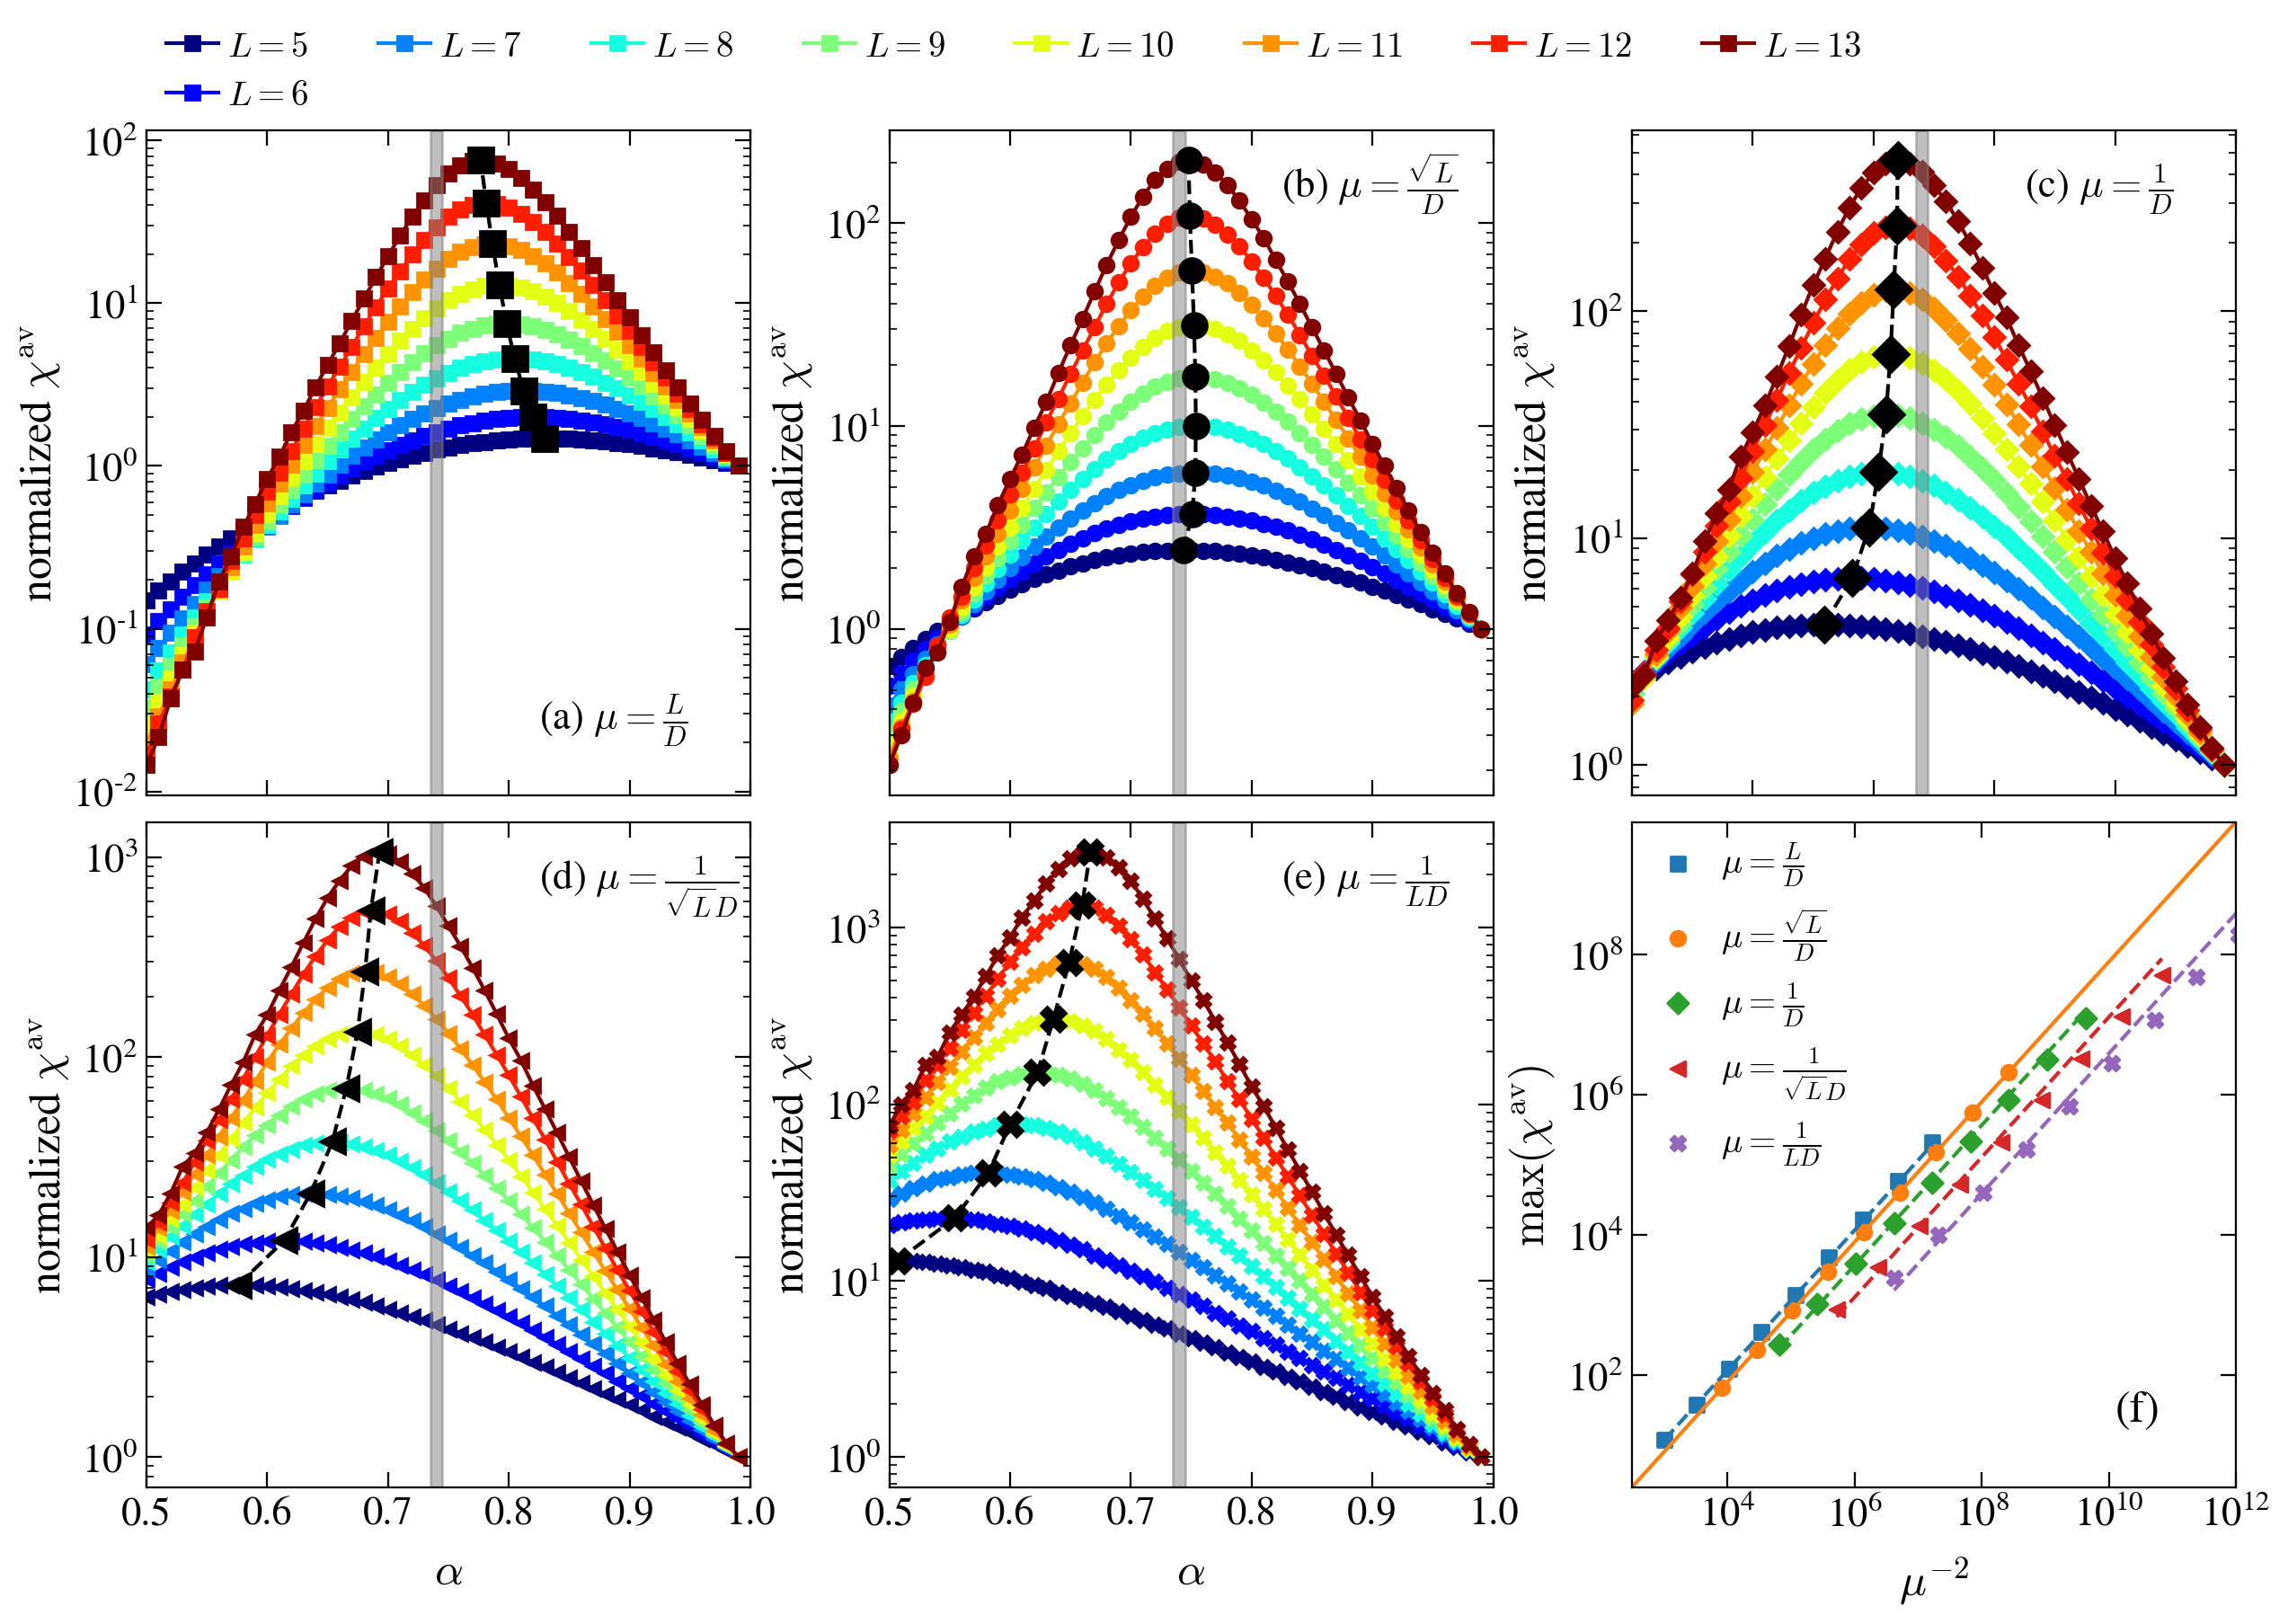

In [19]:
markers_ls2 = ['s','o', 'D', '<', 'X', '^', '*', '+']
markers2 = itertools.cycle(markers_ls2)
colors_ls_cyc = itertools.cycle(colors_ls)

L_total=14

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.74

alfa_vals = np.arange(0.5, 1., 0.01)
print(alfa_vals)


TYPICAL = 0


sizes = np.arange(8, 17, 1) - N
norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])
# create a ScalarMappable and initialize a data structure

fig, axis = plt.subplots( nrows=2, ncols=3, figsize=(15,10), dpi = 200, sharex=False)
axis = axis.flatten()

# figmu, ax_mu = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200, sharex=True)
ax_mu = axis[-1]

mu_indices = np.array([2,3,4,5,6])

ETH_norm = np.zeros((sizes.size, mu_indices.size))

susc_max = np.zeros((sizes.size, mu_indices.size))
alfa_max = np.zeros((sizes.size, mu_indices.size))
for iiL, L in enumerate(sizes):
    col = s_m.to_rgba(L)
    dim = 2**(L+N)
    susc = np.zeros((alfa_vals.size, mu_indices.size)); susc.fill(np.nan)
    norm = np.zeros((alfa_vals.size, mu_indices.size)); norm.fill(np.nan)
    realis = np.zeros((alfa_vals.size, mu_indices.size)); realis.fill(np.nan)
    
    for ii, alfa in enumerate(alfa_vals):
        name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                R = np.array(file.get('realisations'))
                DOS = max(np.array(file.get('DOS'))) / R
                wHx = np.array(file.get('wH'))[-2]
                wHx_typ = np.array(file.get('wH_typ'))[-2]
                
        name = base_dir + 'AGP/CUTOFF/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
        if exists(name):
            with h5py.File(name, "r") as file:
                # wHx = 1/dim
                realis[ii] = np.array(file.get('realisations'))
                cutoff = np.array(file.get('cutoff'))[mu_indices]
                
                susc[ii] = np.array(file.get('susc_typ'))[mu_indices] if TYPICAL else np.array(file.get('susc'))[mu_indices]
                
        else:
            print(name)
            
    # s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm = matplotlib.colors.Normalize(vmin=min(sizes),vmax=max(sizes)) )
    # s_m.set_array([])   
    print(L, list(np.sort(realis.flatten())) )
    markers2 = itertools.cycle(markers_ls2)
    for iim, mu in enumerate(cutoff):
        yy = susc[:,iim]
        power = np.log(mu * dim) / np.log(L+N)
        
        # norm = dim**((1 - np.log(alfa_vals) / np.log(alfa_crit))) / dim
        # axis[iim].plot(alfa_vals, yy / wHx * ((L+N)**power / dim)**2, marker=next(markers2), color=col, zorder=0, label=r"$L=%d$"%L)
        scaling = wHx / (wHx_typ)**2
        # scaling = dim**(-1) * mu**(-2)
        
        normama = yy[-1]
        axis[iim].plot(alfa_vals, yy / normama, marker=next(markers2), color=col, zorder=0, label=r"$L=%d$"%L)
        
        x = alfa_vals[~np.isnan(yy)]
        yy = yy[~np.isnan(yy)]
        indices = np.arange(max([np.argmax(yy) - 10, 0]), min([np.argmax(yy) + 10, alfa_vals.size]), 1)
        
        x = np.linspace(alfa_vals[indices][0], alfa_vals[indices][-1], 1000)
        f = splrep(alfa_vals[indices], yy[indices], k=5, s=10)
        yy = splev(x, f)
        
        idx = np.argmax(yy)
        susc_max[iiL, iim] = yy[idx]
        alfa_max[iiL, iim] = x[idx]
        ETH_norm[iiL, iim] = normama
    

markers2 = itertools.cycle(markers_ls2)
ylab = r"normalized $\chi^{\rm typ}$" if TYPICAL else r"normalized $\chi^{\rm av}$"

labs = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
nams = [r"$\frac{L}{D}$", r"$\frac{\sqrt{L}}{D}$", r"$\frac{1}{D}$", r"$\frac{1}{\sqrt{L}D}$", r"$\frac{1}{LD}$"]
sizes_tot = sizes + N

for iim, mu in enumerate(cutoff):
    mar = next(markers2)
    power = np.log(mu * dim) / np.log(L+N)
    power = np.round(power, order_of_magnitude(power))
    # if power < 0.0: power = 0.0
    
    lab = r" $\mu=$" + nams[iim]
    
    dat = susc_max[:, iim] #* (sizes_tot**power)**2 / 2**sizes_tot
    # dat = dat / dat[0]
    
    colo = next(colors_ls_cyc)
    ax_mu.scatter( 1/( sizes_tot**power / 2**sizes_tot)**2, dat, marker=mar, color=colo, label = lab)
    pars, pconv= fit(power_law,
                        xdata = sizes_tot[2:],
                        ydata = (dat * (sizes_tot**power / 2**sizes_tot)**2)[2:],
                        maxfev = 20000)
    # zz = np.linspace(sizes_tot[0], sizes_tot[-1] + 1, 100)
    # slope = power_law(zz, *pars)
    # ax_mu.plot(zz, slope, color=colo, ls='--')
    
    # slope = power_law(zz, -power, 1)
    # slope = slope/slope[0]
    # ax_mu.plot(zz, slope, color=colo, ls=':')
    pars2, pconv2 = fit(power_law,
                        xdata = sizes_tot,
                        ydata = dat / (2**sizes_tot)**2,
                        maxfev = 20000)
    print(power, "scaling above \mu:", pars[0], "\t\tscaling above D:", pars2[0])
    
    sasa = 1/( sizes_tot**power / 2**sizes_tot)**2
    idx = 2; val = sasa[2]
    if iim == 1:
        sasa = np.logspace(2.5, 12, 1000)
        idx = np.argmin(np.abs(sasa - val))
    ax_mu.plot(sasa, dat[2] * sasa / sasa[idx], ls='-' if iim == 1 else '--', color=colo)
    if iim == 1:
        axis[-1].set_xlim(min(sasa), max(sasa))
        axis[-1].set_ylim(min(dat[2] * sasa / sasa[idx]), max(dat[2] * sasa / sasa[idx]))
    
    axis[iim].plot(alfa_max[:, iim], susc_max[:, iim] / ETH_norm[:, iim], marker=mar, color='k', zorder=10, ls='--', markersize=10)
    fig_help.set_plot_elements(axis[iim], ylabel=ylab, xlabel=r"$\alpha$" if iim>2 else "", font_size=16, set_legend=False, xscale='linear', yscale='log')
    
    axis[iim].axvspan(xmin = alfa_crit - 0.005, xmax = alfa_crit + 0.005, color='gray', alpha=0.5 )
    axis[iim].annotate(labs[iim] + lab, fontsize=16, xy=(0.65, 0.9) if iim > 0 else (0.65, 0.1), xycoords='axes fraction')#, bbox=dict(facecolor='none', edgecolor='black', boxstyle='round,pad=0.1'))
    
    if iim < 3:
        axis[iim].xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "" ))
    axis[iim].set_xlim(0.5, 1)
        
axis[-1].annotate(r"(f)", fontsize=18, xy=(0.8, 0.1), xycoords='axes fraction')#, bbox=dict(facecolor='none', edgecolor='black', boxstyle='round,pad=0.1'))


# zz = np.logspace(3, 10, 1000)
# ax_mu.plot(zz, zz/250, ls='--', color='k')
fig.subplots_adjust(wspace = 0.23, hspace=0.04)
fig_help.set_legend(axis[0], fontsize=14, loc='lower left', anchor=(-0.02, 0.98), ncol=8)

fig_help.set_plot_elements(ax_mu, ylabel=r"$\max({\chi^{\rm av}})$", xlabel=r"$\mu^{-2}$", font_size=16, set_legend=False, xscale='log', yscale='log')
fig_help.set_legend(ax_mu, fontsize=14, loc='upper left', anchor=(-0.02, 1.02), ncol=1)

fig.savefig("plots_AGP/FigS6.pdf", bbox_inches = 'tight', pad_inches=0.02)
# figmu.savefig("plots_AGP/FigS7.pdf", bbox_inches = 'tight', pad_inches=0.02)

print("aCSF~SdFFDSAF", 2 / (1 - np.log(0.99) / np.log(alfa_crit)))

In [ ]:
50 * 1.45 / 750 * 266

[0.5  0.51 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63
 0.64 0.65 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77
 0.78 0.79 0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91
 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99]


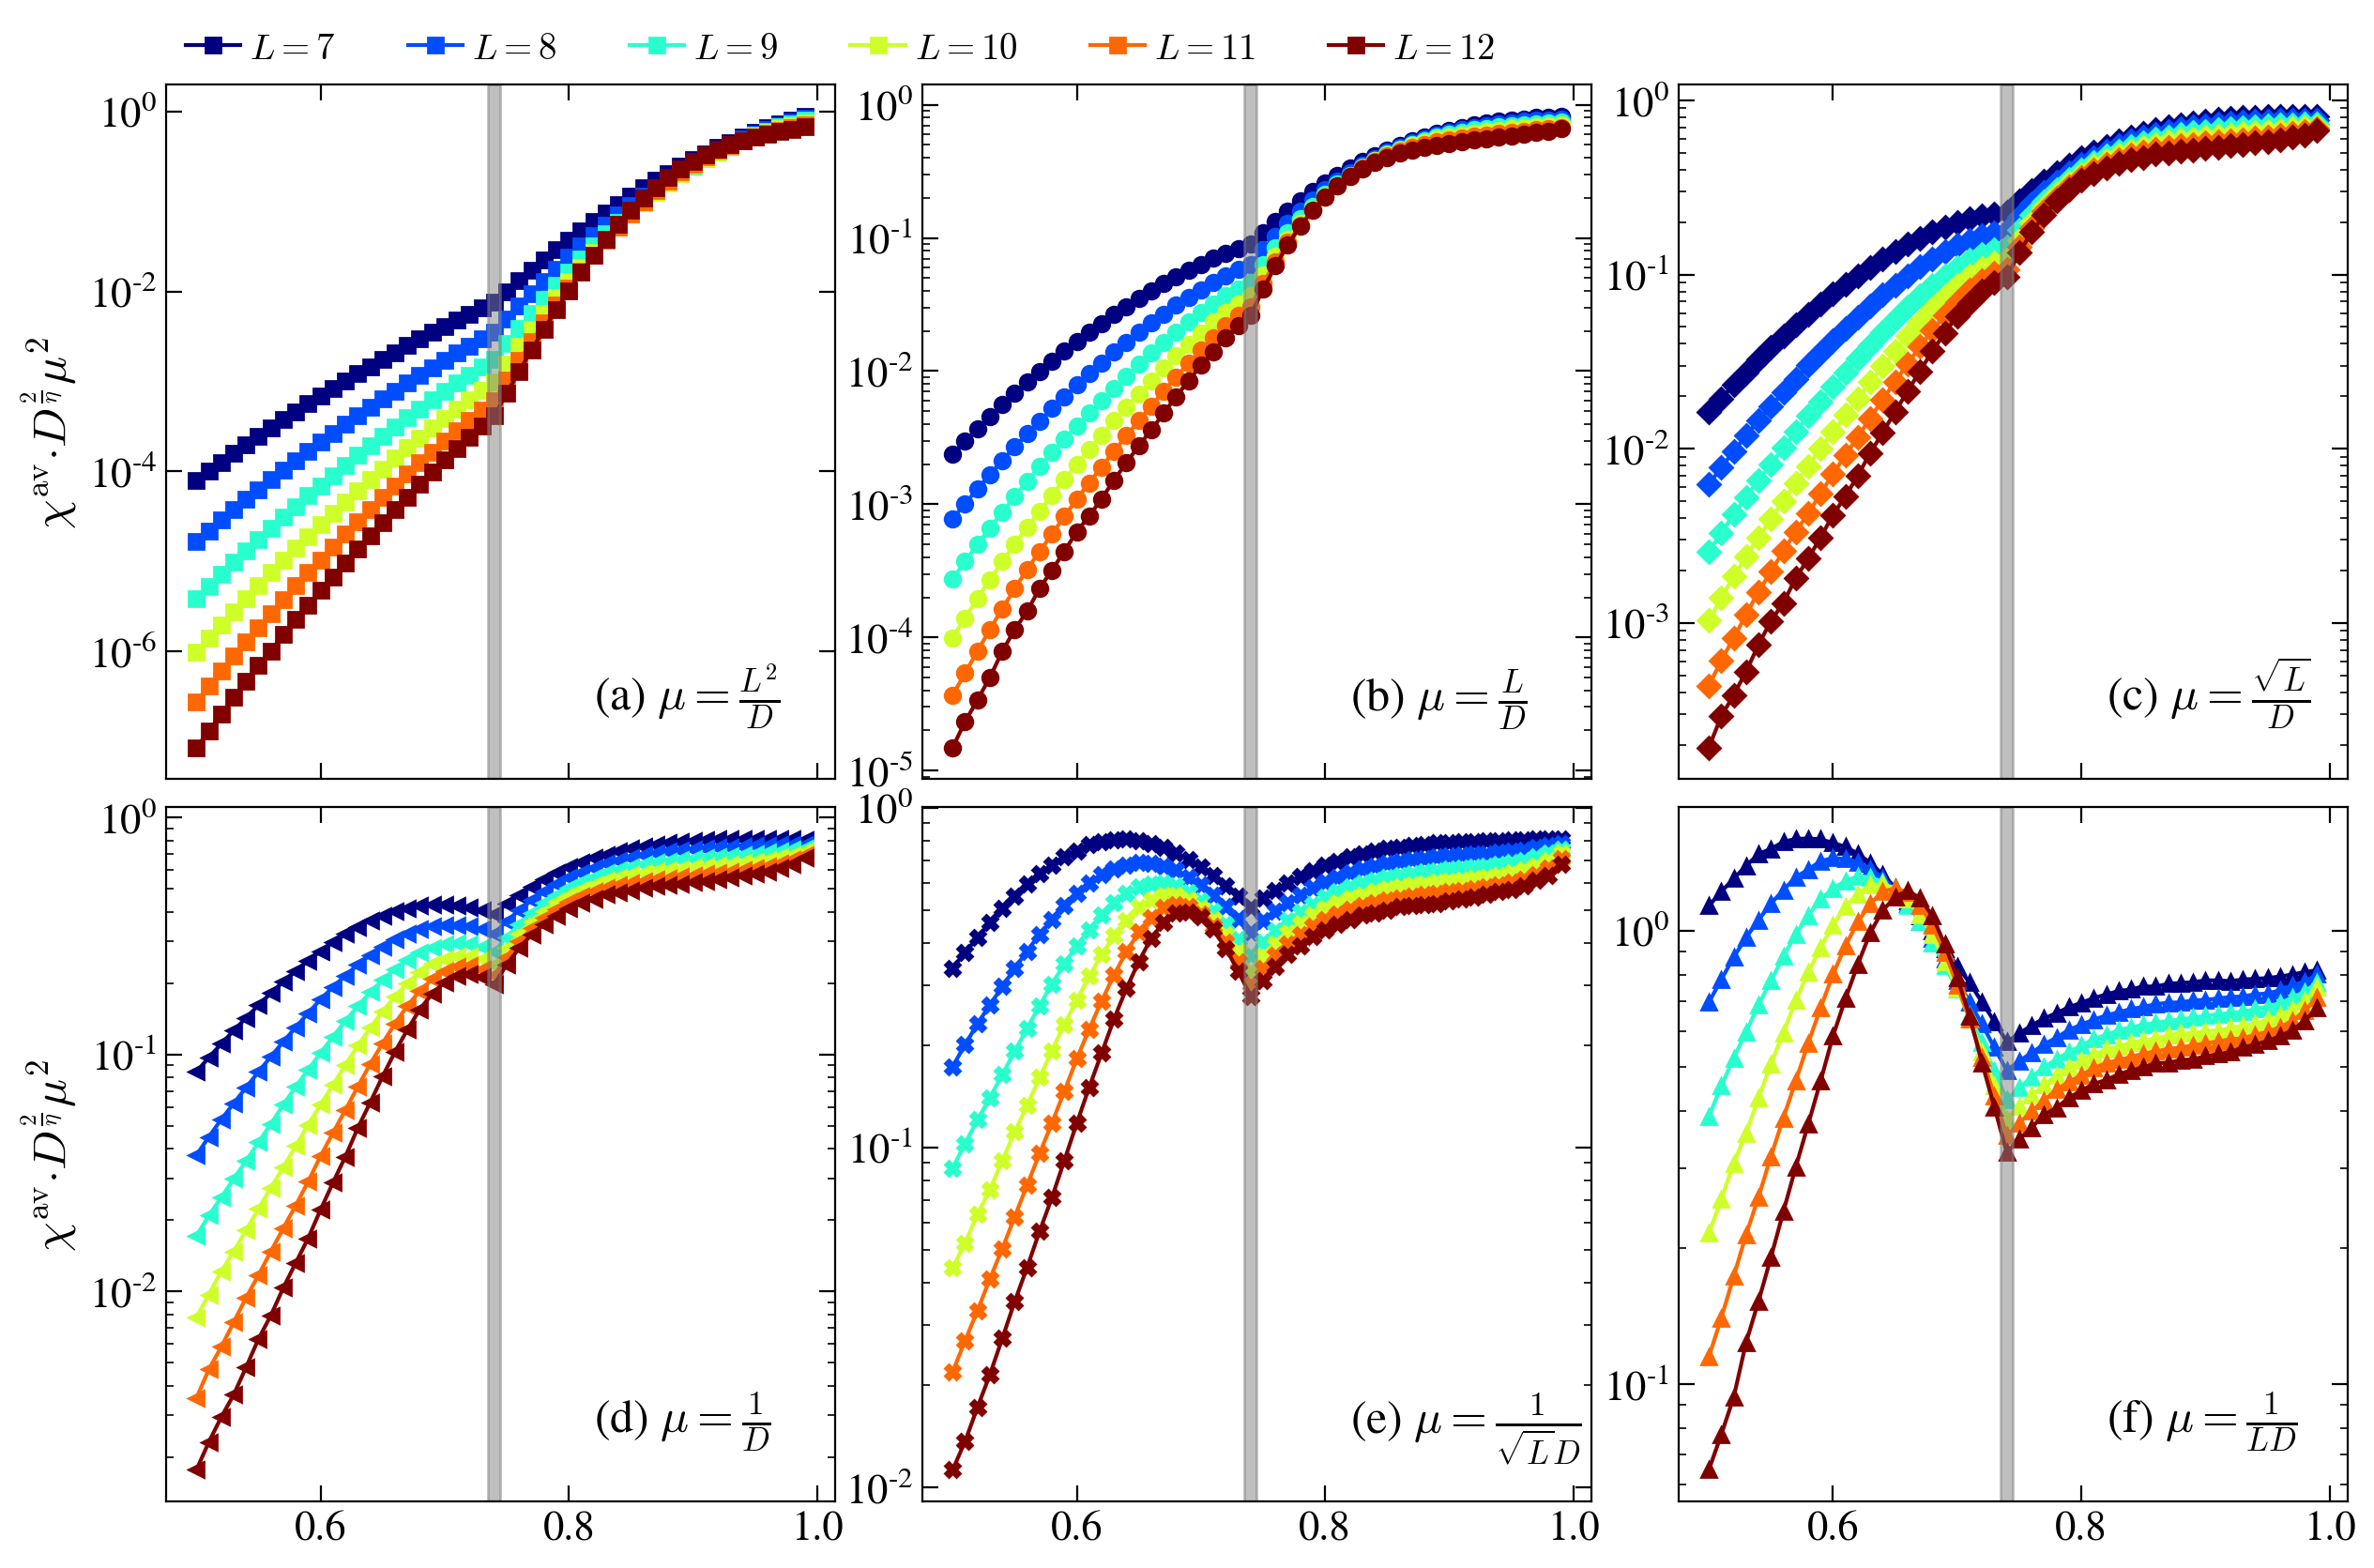

In [30]:
markers_ls2 = ['s','o', 'D', '<', 'X', '^', '*', '+']
markers2 = itertools.cycle(markers_ls2)
colors_ls_cyc = itertools.cycle(colors_ls)

L_total=14

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.74

alfa_vals = np.arange(0.5, 1., 0.01)
print(alfa_vals)


TYPICAL = 0
NORMALIZE_MU = 1

sizes = np.arange(10, 16, 1) - N
norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])
# create a ScalarMappable and initialize a data structure

fig, axis = plt.subplots( nrows=2, ncols=3, figsize=(15,10), dpi = 200, sharex=True)
axis = axis.flatten()

mu_indices = np.array([0,2,3,4,5,6])
susc_max = np.zeros((sizes.size, mu_indices.size))
alfa_max = np.zeros((sizes.size, mu_indices.size))
for iiL, L in enumerate(sizes):
    col = s_m.to_rgba(L)
    dim = 2**(L+N)
    susc = np.zeros((alfa_vals.size, mu_indices.size)); susc.fill(np.nan)
    norm = np.zeros((alfa_vals.size, mu_indices.size)); norm.fill(np.nan)
    
    for ii, alfa in enumerate(alfa_vals):
        name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                R = np.array(file.get('realisations'))
                DOS = max(np.array(file.get('DOS'))) / R
                wHx = np.array(file.get('wH'))[-2]
                # wHx = np.sqrt(L+N) / dim
                
        name = base_dir + 'AGP/CUTOFF/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
        if exists(name):
            with h5py.File(name, "r") as file:
                # wHx = 1/dim
                cutoff = np.array(file.get('cutoff'))[mu_indices]
                
                cutcut = cutoff if NORMALIZE_MU else 1/dim
                # cutcut = np.array( [mmu if mmu >= wHx else wHx for mmu in cutoff] )
                norm[ii] = DOS**(2 / eta - 1) if alfa >= alfa_crit else DOS**(-1)
                susc[ii] = np.array(file.get('susc_typ'))[mu_indices] if TYPICAL else np.array(file.get('susc'))[mu_indices]
                
        else:
            print(name)
            
    # s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm = matplotlib.colors.Normalize(vmin=min(sizes),vmax=max(sizes)) )
    # s_m.set_array([])    
    
    markers2 = itertools.cycle(markers_ls2)
    for iim, mu in enumerate(cutoff):
        yy = susc[:,iim]
        power = np.log(mu * dim) / np.log(L+N)
        
        # norm = dim**((1 - np.log(alfa_vals) / np.log(alfa_crit))) / dim
        axis[iim].plot(alfa_vals, yy * norm[:, iim] / yy[-2], marker=next(markers2), color=col, zorder=0, label=r"$L=%d$"%L)
        

markers2 = itertools.cycle(markers_ls2)
ylab = r"$\chi^{\rm typ}$" if TYPICAL else r"$\chi^{\rm av}$"
ylab = ylab + r"$\cdot D^\frac{2}{\eta}\mu^2$" if NORMALIZE_MU else ylab + r"$\cdot D^\frac{2}{\eta}/D^2$"

labs = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
nams = [r"$\frac{L^2}{D}$", r"$\frac{L}{D}$", r"$\frac{\sqrt{L}}{D}$", r"$\frac{1}{D}$", r"$\frac{1}{\sqrt{L}D}$", r"$\frac{1}{LD}$"]
sizes_tot = sizes + N

for iim, mu in enumerate(cutoff):
    lab = r" $\mu=$" + nams[iim]
    fig_help.set_plot_elements(axis[iim], ylabel=ylab if iim%3==0 else "", xlabel=r"$\alpha$" if iim>5 else "", font_size=16, set_legend=False, xscale='linear', yscale='log')
    
    axis[iim].axvspan(xmin = alfa_crit - 0.005, xmax = alfa_crit + 0.005, color='gray', alpha=0.5 )
    axis[iim].annotate(labs[iim] + lab, fontsize=18, xy=(0.64, 0.1), xycoords='axes fraction')#, bbox=dict(facecolor='none', edgecolor='black', boxstyle='round,pad=0.1'))
    
fig.subplots_adjust(wspace = 0.13, hspace=0.04)
fig_help.set_legend(axis[0], fontsize=14, loc='lower left', anchor=(-0.02, 0.98), ncol=6)

# fig.savefig("plots_AGP/FigS6.pdf", bbox_inches = 'tight', pad_inches=0.02)
# figmu.savefig("plots_AGP/FigS7.pdf", bbox_inches = 'tight', pad_inches=0.02)

# FINAL

## FIG. 2

In [5]:
max_typ = np.ones(sizes.shape)
max_susc = np.ones(sizes.shape)

[0.5  0.51 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63
 0.64 0.65 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77
 0.78 0.79 0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91
 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99]
7 SUSC	 0.7500000000000002 || 7500.0 10000.0 		TYP_SUSC	 0.7900000000000003 || 10000.0 10000.0
8 SUSC	 0.7500000000000002 || 7500.0 10000.0 		TYP_SUSC	 0.7800000000000002 || 10000.0 10000.0
9 SUSC	 0.7500000000000002 || 6000.0 8000.0 		TYP_SUSC	 0.7800000000000002 || 8000.0 8000.0
10 SUSC	 0.7500000000000002 || 3000.0 4500.0 		TYP_SUSC	 0.7700000000000002 || 5731.0 6000.0
11 SUSC	 0.7500000000000002 || 2450.0 3000.0 		TYP_SUSC	 0.7700000000000002 || 2806.0 3000.0
12 SUSC	 0.7500000000000002 || 694.0 1214.0 		TYP_SUSC	 0.7600000000000002 || 1052.0 1377.0
13 SUSC	 0.7500000000000002 || 184.0 214.0 		TYP_SUSC	 0.7600000000000002 || 702.0 787.0
[  411.67202942   884.94636645  1850.3872492   3785.94289516
  7645.21768101 15286.52690318 3115

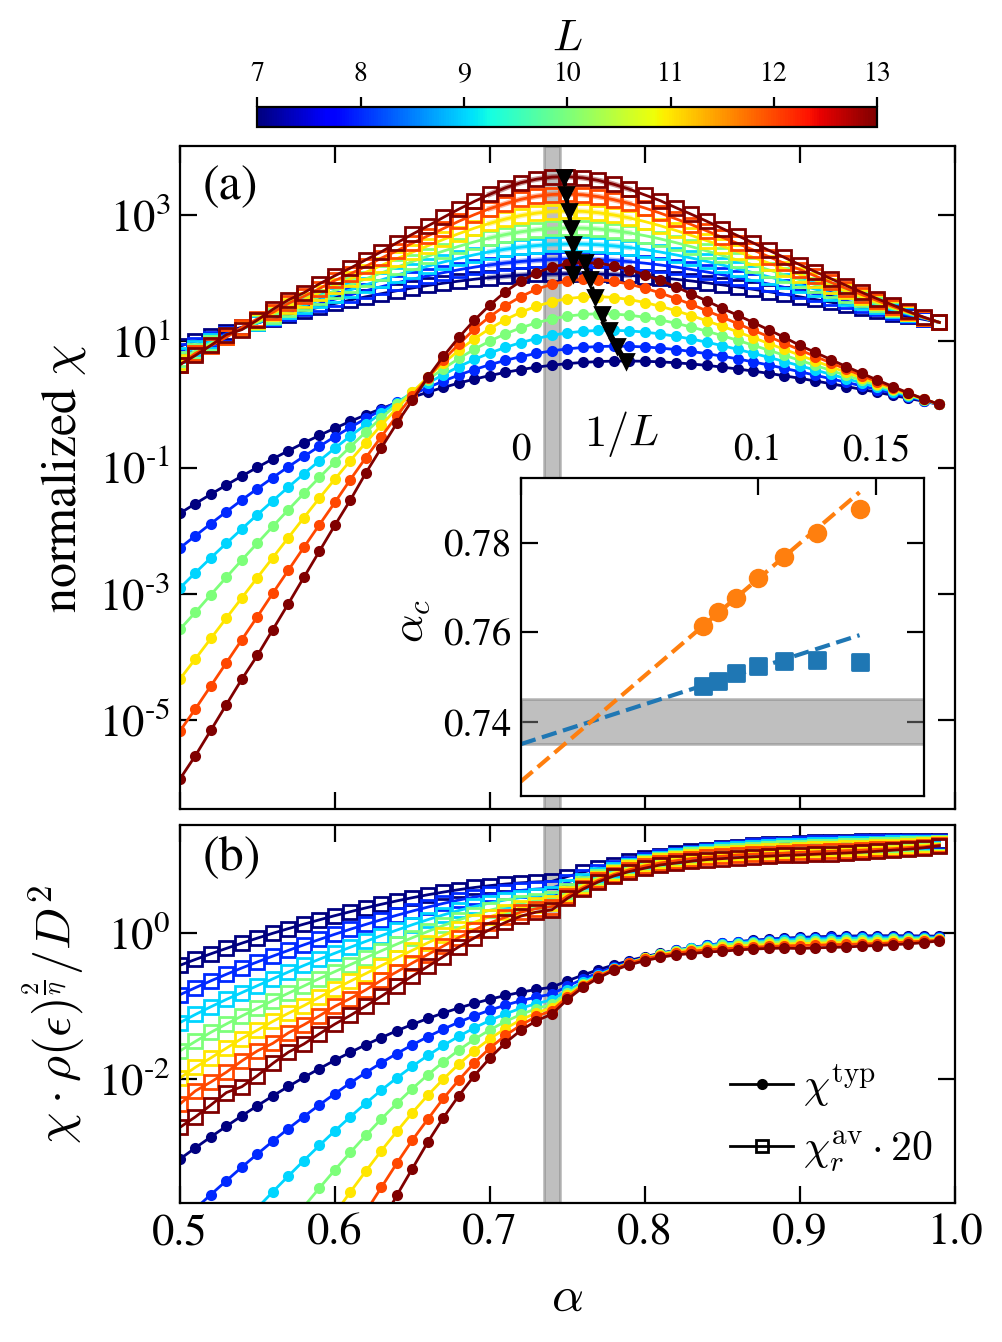

In [27]:
markers_ls2 = ['s','o', 'D', '<', 'X', '^', '*', '+']
markers2 = itertools.cycle(markers_ls2)
colors_ls_cyc = itertools.cycle(colors_ls)

L_total=15

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.74

alfa_vals = np.arange(0.5, 1., 0.01)
print(alfa_vals)

sizes = np.arange(10, 17, 1) - N
norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])
fig = plt.figure(figsize=(5,7), dpi = 200)
fig.subplots_adjust(hspace=0.0)
gs = GridSpec(2, 1, height_ratios = [7, 4]) 
# gs1 = GridSpec(1,1)
# gs.update(top=0.98, bottom=0.48, hspace=0.02)
# gs1.update(top=0.4, bottom=0.02)
ax1 = fig.add_subplot(gs[0])
axis = [ax1, fig.add_subplot(gs[1])]
# fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(5,9.5), dpi = 200, sharex=True)

agp_max = []
alfa_max1 = []
susc_max = []
alfa_max2 = []
for iiL, L in enumerate( sizes ):
    col = s_m.to_rgba(L)
    dim = 2**(L+N)
    
    reals    = np.zeros((alfa_vals.size)); reals.fill(np.nan)
    reals2   = np.zeros((alfa_vals.size)); reals.fill(np.nan)
    agp      = np.zeros((alfa_vals.size)); agp.fill(np.nan)
    susc     = np.zeros((alfa_vals.size)); susc.fill(np.nan)
    typ_susc = np.zeros((alfa_vals.size)); typ_susc.fill(np.nan)
    norm_av_fading = np.zeros((alfa_vals.size)); norm_av_fading.fill(np.nan)
    norm_typ_fading = np.zeros((alfa_vals.size)); norm_typ_fading.fill(np.nan)
    norm_av = np.zeros((alfa_vals.size)); norm_av.fill(np.nan)
    norm_typ = np.zeros((alfa_vals.size)); norm_typ.fill(np.nan)
    wH = np.zeros((alfa_vals.size)); wH.fill(np.nan)
    wH_anal = np.zeros((alfa_vals.size)); wH_anal.fill(np.nan)
    for ii, alfa in enumerate(alfa_vals):
        name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
        if exists(name):
            with h5py.File(name, "r") as file:
                R = np.array(file.get('realisations'))
                DOS = max(np.array(file.get('DOS'))) / R
                # DOS = dim * 1.0
                
                wHx = np.array(file.get('wH'))[-2]
                wHx_typ = np.array(file.get('wH_typ'))[-2]
                wH[ii] = wHx
                # wHx = 1/dim
                wHx_typ = 1 / dim
                
                mu = wHx#np.sqrt(L+N) / dim
                
                norm_av_fading[ii] = DOS**(2 / eta - 1) / max_susc[iiL] if alfa >= alfa_crit else DOS**(-1) / max_susc[iiL]
                norm_typ_fading[ii] = DOS**(2 / eta - 1) / max_typ[iiL] if alfa >= alfa_crit else DOS**(-1) / max_typ[iiL]
                norm_av[ii] = 1/max_susc[iiL] #DOS**(-1) * (mu)**(-2)
                norm_typ[ii] = 1/max_typ[iiL] #DOS**(-1) * (wHx_typ)**(-2)
                
                # norm_av_fading[ii] = DOS**(-2 / eta) / mu**2 if alfa >= alfa_crit else mu**(-2)
                # norm_typ_fading[ii] = DOS**(-2 / eta) / wHx_typ**2 if alfa >= alfa_crit else wHx_typ**(-2)
                # norm_av[ii] = DOS**(-1) * (mu)**(-2)
                # norm_typ[ii] = DOS**(-1) * (wHx_typ)**(-2)
                
                # DOS = max(np.array(file.get('DOS'))) / R
                # norm2[ii] = DOS**(-2 / eta) / wHx**2 if alfa >= alfa_crit else 1 / wHx**2
                
                reals[ii] = np.array(file.get('realisations'))
                # agp[ii] = np.array(file.get('SUSC_R'))[-2] * 10
                # susc[ii] = np.array(file.get('SUSC_R'))[-2]
                typ_susc[ii] = np.array(file.get('TYP_SUSC'))[-2]
        else:
            print(name)
        name = base_dir + 'AGP/CUTOFF/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
        if exists(name):
            with h5py.File(name, "r") as file:
                reals2[ii] = np.array(file.get('realisations'))
                cutoff = np.array(file.get('cutoff'))[3]
                # cutcut = cutoff if NORMALIZE_MU else 1/dim
                # norm[ii] = (dim)**(2 / eta) * cutcut**2 if alfa >= alfa_crit else cutcut**2
                agp[ii] = np.array(file.get('susc'))[3]
    max_typ[iiL] = typ_susc[-1]
    max_susc[iiL] = agp[-1]
    axis[0].plot(alfa_vals, typ_susc * norm_typ, color=col, marker='o', markersize=3, lw=1)
    axis[0].plot(alfa_vals, agp      * norm_av * 20, color=col, marker='s', markersize=5, lw=1, markerfacecolor='None')
    axis[1].plot(alfa_vals, typ_susc * norm_typ_fading, color=col, marker='o', markersize=3, lw=1)
    axis[1].plot(alfa_vals, agp      * norm_av_fading * 20, color=col, marker='s', markersize=5, lw=1, markerfacecolor='None')
    
    print(L, "SUSC\t", alfa_vals[np.argmax(agp)], "||", min(reals2), max(reals2), "\t\tTYP_SUSC\t", alfa_vals[np.argmax(typ_susc)], "||", min(reals), max(reals))
    x = alfa_vals[~np.isnan(agp)]
    agp = agp[~np.isnan(agp)] / agp[-1] * 20
    # indices = np.where(np.logical_and(alfa_vals >= 0.6, alfa_vals < 1.85))[0]
    if agp.size > 10:
        indices = np.arange(np.argmax(agp) - 5, np.argmax(agp) + 5, 1)
        x = np.linspace(alfa_vals[indices][0], alfa_vals[indices][-1], 1000)
        f = splrep(alfa_vals[indices], agp[indices], k=5, s=10)
        agp = splev(x, f)
        axis[0].plot(x, agp, lw=2, alpha=0.4, color=col)
        idx = np.argmax(agp)
        agp_max.append(agp[idx])
        alfa_max1.append(x[idx])
    else:
        agp_max.append(np.nan)
        alfa_max1.append(np.nan)
    
    x = alfa_vals[~np.isnan(typ_susc)]
    typ_susc = typ_susc[~np.isnan(typ_susc)] / typ_susc[-1]
    if typ_susc.size > 10:
        indices = np.arange(np.argmax(typ_susc) - 5, np.argmax(typ_susc) + 5, 1)
        x = np.linspace(alfa_vals[indices][0], alfa_vals[indices][-1], 1000)
        f = splrep(alfa_vals[indices], typ_susc[indices], k=5, s=10)
        typ_susc = splev(x, f)
        idx = np.argmax(typ_susc)
        susc_max.append(typ_susc[idx])
        alfa_max2.append(x[idx])
    else:
        susc_max.append(np.nan)
        alfa_max2.append(np.nan)
  
print(max_typ)
  
axis[0].plot(alfa_max1, agp_max,  marker='v', color='black', ls='--', markersize=5)
axis[0].plot(alfa_max2, susc_max, marker='v', color='black', ls='--', markersize=5)

axis[1].plot(np.nan, np.nan, color='k', marker='o', markersize=3, lw=1, label=r"$\chi^{\rm typ}$" if L == 13 else "")
axis[1].plot(np.nan, np.nan, color='k', marker='s', markersize=4, lw=1, markerfacecolor='None', label=r"$\chi^{\rm av}_r\cdot20$" if L == 13 else "") 
    
# fig.subplots_adjust(top=0.97)
cbar_ax = axis[0].inset_axes([0.1, 1.03, 0.8, 0.03])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$L$", fontsize=16)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')

   
axis[0].annotate(r"(a)", fontsize=18, xy=(0.03, 0.92), xycoords='axes fraction')
axis[1].annotate(r"(b)", fontsize=18, xy=(0.03, 0.88), xycoords='axes fraction')
# axis[1].set_ylim(2e-4, 6e1)
axis[0].set_xlim(0.5, 1)
axis[1].set_xlim(0.5, 1)

axis[1].set_ylim(2e-4, 30)

for axa in axis:
    # ax.axvline(x=1/np.sqrt(2), ls=':', c='gray')
    # axa.axvline(x=alfa_crit,    ls=':', c='gray')
    axa.axvspan(xmin = alfa_crit - 0.005, xmax = alfa_crit + 0.005, color='gray', alpha=0.5 )
    
fig_help.set_plot_elements(axis[0], ylabel=r"normalized $\chi$", xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\chi\cdot \rho(\epsilon)^{\frac{2}{\eta}}/D^2$", xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear', yscale='log')
fig_help.set_legend(axis[1], fontsize=15, loc='lower right')


inset = axis[0].inset_axes([0.44, 0.02, 0.52, 0.48])

# sizes = sizes+N
for alfac in [alfa_max1, alfa_max2]:
    col = color=next(colors_ls_cyc)
    inset.scatter(1/sizes, alfac, marker=next(markers2), color=col)
    xx = 1/sizes[~np.isnan(alfac)]
    yy = np.array(alfac)[~np.isnan(alfac)]
    pars, pconv, fit_info, msg, _ = fit(lin_fit2,
                        xdata = xx[-5:],
                        ydata = yy[-5:],
                        full_output=True, maxfev=10000)
    print(*pars)
    xx = np.linspace(0, max(1/sizes), 10000)
    inset.plot( xx, lin_fit2(xx, *pars), ls='--',  color = col)

fig_help.set_plot_elements(inset, ylabel=r"$\alpha_c$", xlabel=r"$1/L$", font_size=14, set_legend=False, xscale='linear', yscale='linear')
inset.set_xlim(0, 0.17)
# inset.set_ylim(0, 0.17)

# inset.set_xticks([0.05, 0.1, 0.78, 0.8])
# axis[0].set_xticks([])

axis[0].xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "" ))

inset.set_yticks([0.7, 0.72, 0.74, 0.76, 0.78])
# inset.set_yticklabels(["0.7", "0.72", "", "", "0.78"])
inset.set_xticks([0, 0.1, 0.15])
inset.set_xticklabels(["0", "0.1", "0.15"])
inset.xaxis.set_label_position("top")
inset.xaxis.tick_top()
inset.xaxis.set_label_coords(0.25, 1.1)
inset.yaxis.set_label_position("left")
inset.yaxis.set_label_coords(-0.22, 0.55)

# inset.axhline(y=1/np.sqrt(2), ls=':', c='gray')
# inset.axhline(y=alfa_crit,    ls='--', c='k')
inset.axhspan(ymin = alfa_crit - 0.005, ymax = alfa_crit + 0.005, color='gray', alpha=0.5 )
fig.subplots_adjust(wspace = 0.03, hspace=0.03)
fig.savefig("plots_AGP/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

## FIG. 1

In [ ]:
L_total=15

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745

alfa_vals = np.arange(0.6, 1., 0.01)
print(alfa_vals)

sizes = np.arange(8, 17, 1)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)
inset = axis.inset_axes([0.03, 0.03, 0.43, 0.56]);

alfa = 0.74

spec_fun_at_wH = []
spec_fun_at_wH_typ = []

name = base_dir + "Correlators/Spectrals_g0=%g,alfa=%.2f.hdf5"%(J, alfa)

if exists(name):
    with h5py.File(name, "r") as file:
        fluct      = np.array(file.get('state2state_fluct_Sz'))
        outliers   = np.array(file.get('state2state_outlier_Sz'))
        wH   = np.array(file.get('wH'))
        sizes   = np.array(file.get('sizes')) - N
        
        inset.scatter(sizes, fluct,    marker='s', color = 'red')
        inset.scatter(sizes, outliers, marker='v', color = 'blue')
        norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes) )


        # create a ScalarMappable and initialize a data structure
        s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
        s_m.set_array([])
        for ii, L in enumerate(sizes):
            col = s_m.to_rgba(L)
            dim = 2**(L+N)
            spec = np.array(file.get('Sz_L=%d'%L))
            omega = np.array(file.get('omegas_L=%d'%L))
            print(L, min(omega))
            # omega /= wH[ii]
            axis.scatter(omega, spec, color=col, s=5)
        
else:
    print(name)
    
w = np.logspace(-5, 1, 1000)
axis.plot(w, 1e-8/w**2, ls='--', color='k', lw=2, label=r"$\omega^{-2}$")
# axis.annotate(r"$\omega^{-2}$", fontsize=14, xy=(6e2, 1e-6), xycoords='data', color='k')

# axis.axvline(x=1, ls=':', color='gray', ymin=0.)
inset.xaxis.set_label_position("top")
inset.xaxis.set_label_coords(.45, 1.1)
inset.xaxis.tick_top()

inset.yaxis.set_label_position("right")
inset.yaxis.set_label_coords(1.1, 0.53)
inset.yaxis.tick_right()

fig_help.set_plot_elements(axis, ylabel=r"$\overline{|(S_L^z)_{nm}|^2}$", xlabel=r"$\omega$", font_size=16, set_legend=False, xscale='log', yscale='log', xlim=(1e-6, 1e1), ylim=(1e-12, 0.5))
fig_help.set_legend(axis, fontsize=16, loc='upper right')

fig.subplots_adjust(wspace = 0.23, hspace=0.13)

fig_help.set_plot_elements(inset, xlabel=r"$L$", font_size=16, set_legend=False, xscale='linear', yscale='linear')
inset.set_ylabel(r"$z$", rotation=0, fontsize=16)
inset.set_yticks([0.4, 0.6, 1, 1.2])
inset.set_ylim(0.3, 1.3)

cbaxes = axis.inset_axes([1., 0.0, 0.03, 1])
cbar = fig.colorbar(s_m, cax = cbaxes, orientation='vertical')
cbar.set_label(r"$L$", fontsize=16)

inset.annotate(r"MAXIMAL OUTLIER",       fontsize=10, xy=(5.5, 1.05), xycoords='data', color='blue')
inset.annotate(f"AVERAGE\nFLUCTUATIONS", fontsize=10, xy=(6.5, 0.43),  xycoords='data', color='red')
axis.set_title(r"critical point; $\alpha=\alpha_c\approx0.74$", fontsize=18)

fig.savefig("plots_AGP/Fig1.pdf", bbox_inches = 'tight', pad_inches=0.02)

(1e-06, 269.7266471324023)

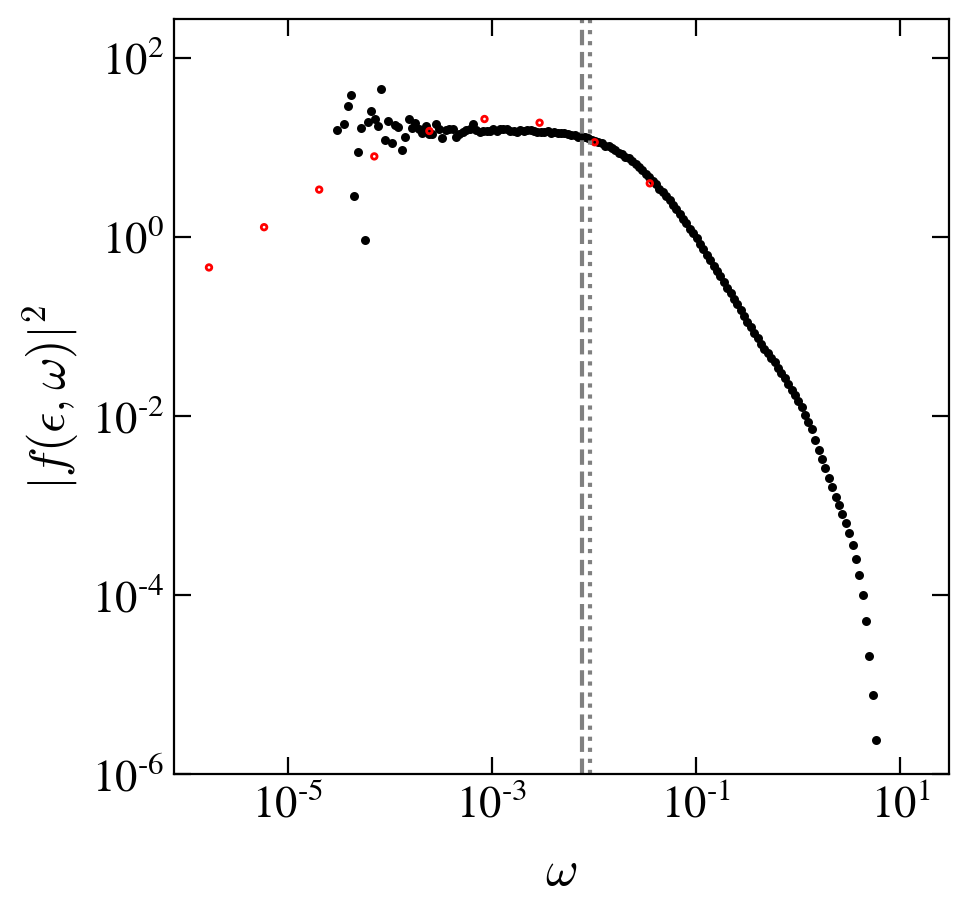

In [678]:
L_total=12

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

alfa = 0.90

spec_fun_at_wH = []
spec_fun_at_wH_typ = []

name = base_dir + "Correlators/Spectrals_g0=%g,alfa=%.2f.hdf5"%(J, alfa)
if exists(name):
    with h5py.File(name, "r") as file:
        dim = 2**(L+N)
        sizes = np.array(file.get('sizes'))
        idx = np.argmin(np.abs(sizes - L))
        wH = np.array(file.get('wH'))[idx]
        wH_typ = np.array(file.get('wH_typ'))[idx]
        
        spec = np.array(file.get('Sz_L=%d'%L)) * dim
        omega = np.array(file.get('omegas_L=%d'%L))
        axis.scatter(omega, spec, color='k', s=5)
        axis.axvline(x=wH, ls=':', color='gray')
        axis.axvline(x=wH_typ, ls='--', color='gray')
else:
    print(name)
name = base_dir + "AGP/CUTOFF/" + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
if exists(name):
    with h5py.File(name, "r") as file:
        dim = 2**(L+N)
        omega = np.array(file.get('cutoff'))
        spec = np.array(file.get('susc')) * omega * 10
        axis.scatter(omega, spec, color='red', s=4, facecolor='None')
else:
    print(name)

fig_help.set_plot_elements(axis, ylabel=r"$|f(\epsilon,\omega)|^2$", xlabel=r"$\omega$", font_size=16, set_legend=False, xscale='log', yscale='log')
axis.set_ylim(1e-6, None)

## Typical fidelity as function of energy density

In [ ]:
L_total=15

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745
window=4
projected = 0

alfa_vals = np.arange(0.6, 1., 0.005)
print(alfa_vals)

alfa_plot = np.arange(0.72, 0.95, 0.03)
dim = 2**L_total
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,3), dpi = 200)

alfa = 0.85

sizes = np.arange(10, 14, 1) - N
# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm= matplotlib.colors.Normalize(vmin=min(alfa_plot), vmax=max(alfa_plot) ))
s_m.set_array([])

for alfa in alfa_plot:
    col = s_m.to_rgba(alfa)
    agp1 = None
    agp2 = None
    name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    

    wH = np.sqrt(2**(N-1) * 0.3 + J**2 / 4 * ( (alfa_vals**(2*L+2) - alfa_vals**2) / (alfa_vals**2 - 1) ) + L / 4 * (1 + (w)**2 / 3)) / (0.3413 * dim)
    eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
    matelem = dim ** (-1/eta)
    # norm = matelem**2 / wH**2
    if exists(name):
        with h5py.File(name, "r") as file:
            R = np.array(file.get('realisations'))
            print(alfa, R)
            E = np.array(file.get('energy_density'))
            idx = min(range(len(E)), key=lambda i: abs(E[i] - 0.5))
            print(E)
            
            R = np.array(file.get('realisations'))
            DOS = np.array(file.get('DOS')) / R
            
            wH = np.array(file.get('wH_density'))
            
            norm = DOS
        
            count = np.array(file.get('count')) / R
            
            x = count[idx]
            agp = np.array(file.get('susc_E_typ')) / R
            # agp = agp / count# / DOS**(1/eta)
            
            
            agp = agp * DOS**(2/eta) * wH**2
            # agp = agp / count
            
            
            agp = tools.remove_fluctuations(agp, bucket_size=window)[window//2:-window//2]
            DOS = tools.remove_fluctuations(DOS, bucket_size=window)[window//2:-window//2]
            wH = tools.remove_fluctuations(wH, bucket_size=window)[window//2:-window//2]
            E = E[window//2:-window//2]
            
            agp /= agp[idx]
            axis.plot(E, agp, color=col, marker='o', markersize=2)
    else:
        print(name)

    # a = 1
    # b = 0.42
    # x = np.linspace(0.1, 0.5, 10000)
    # alfac = alfa_crit * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2)
    # idx1 = np.argmin( np.abs(alfac - alfa))
    # idx1 = np.argmin( np.abs(x[idx1] - E))
    # axis.scatter(E[idx1], agp[idx1], color=col, marker='s')
    
    # x = np.linspace(0.5, 0.9, 10000)
    # alfac = alfa_crit * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2)
    # idx2 = np.argmin( np.abs(alfac - alfa))
    # idx2 = np.argmin( np.abs(x[idx2] - E))
    # axis.scatter(E[idx2], agp[idx2], color=col, marker='s')
    
ylab = r"$\chi^{\rm typ}(\epsilon)\cdot\rho(\epsilon)^{\frac{2}{\eta}}\cdot\omega_H(\epsilon)^2$"# if projected else r"$||\mathcal{A}_\lambda(\epsilon)||^2\cdot D^{\frac{1}{\eta}}$"
ylab = r"${\chi}(\epsilon)$"
fig_help.set_plot_elements(axis, ylabel=ylab, xlabel=r"$\epsilon$", font_size=16, set_legend=False, xscale='linear', yscale='linear')

fig.subplots_adjust(top=0.92)
cbar_ax = fig.add_axes([0.15, 0.95, 0.7, 0.04])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$\alpha$", fontsize=16)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')


fig.subplots_adjust(wspace = 0.23, hspace=0.13)
fig.savefig("plots_AGP/FigAV.pdf", bbox_inches = 'tight', pad_inches=0.02)

0.01 0.005793976270230126


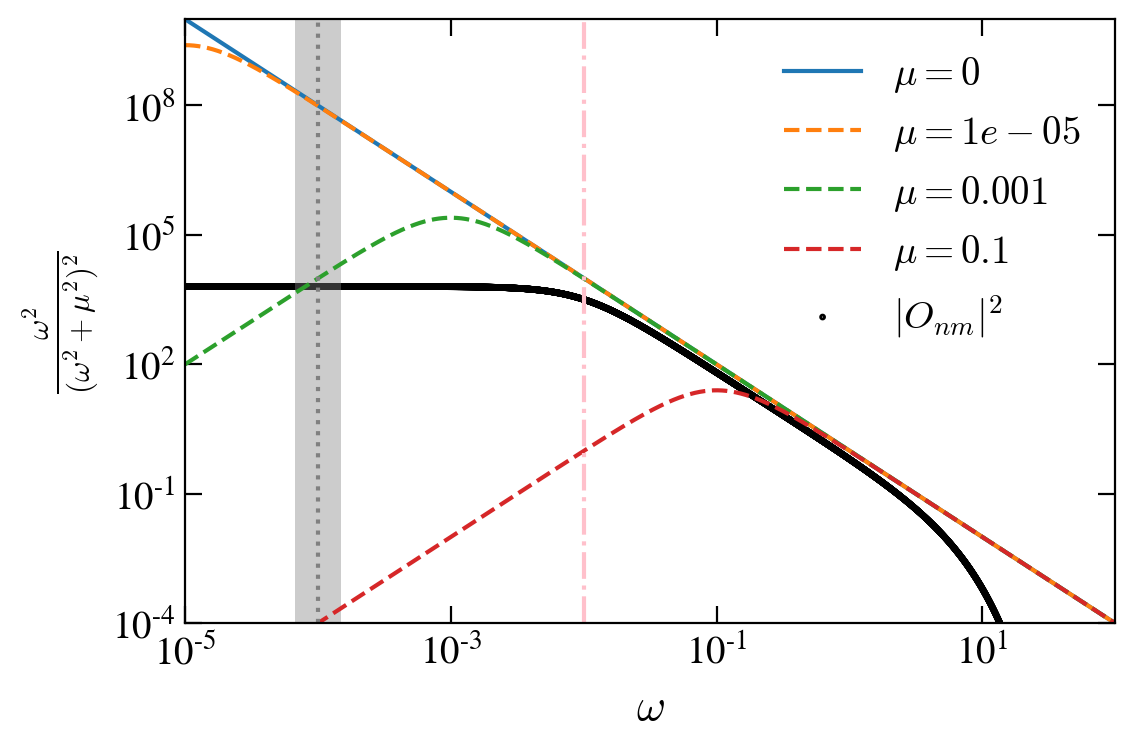

In [705]:
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,4), dpi = 200)

w = np.logspace(-10, 2, 10000)
axis.plot(w, 1/w**2, label=r"$\mu=0$")
for mu in [1e-5, 1e-3, 1e-1]:
    axis.plot(w, w**2 / (w**2 + mu**2)**2, label=r"$\mu=%g$"%mu, ls='--')

Gamma = 0.01
spec_fun = 200/np.pi * Gamma / (w**2 + Gamma**2) * np.exp(-w*np.log(w) / Gamma / 1000)
axis.scatter(w, spec_fun, s=2, color='k', facecolor='None', label=r"$|O_{nm}|^2$")

deriv = np.abs(np.diff(spec_fun) / np.diff(w))
xx = (w[1:]+w[:-1])/2
idx = np.argmax(deriv)
print(Gamma, xx[idx])

axis.axvline(x=Gamma, ls='-.', color='pink')

# axis.scatter(xx, np.abs(deriv), s=2, color='gray', facecolor='None', label=r"$\left|\frac{dO_{nm}^2}{d\omega}\right|$")
axis.axvspan(xmin=6.66666e-5, xmax=1.5e-4, lw=0, color='gray', alpha=0.4)
axis.axvline(x=1e-4, ls=':', color='gray')


fig_help.set_plot_elements(axis, ylabel=r"$\frac{\omega^2}{(\omega^2+\mu^2)^2}$", xlabel=r"$\omega$", font_size=14, set_legend=True, xscale='log', yscale='log', xlim=(1e-5, 1e2), ylim=(1e-4, 1e10))

In [ ]:
L_total=12

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745
window=6
projected = 0

alfa_vals = np.arange(0.6, 1., 0.005)
print(alfa_vals)

alfa_plot = np.arange(0.71, 0.95, 0.02)
dim = 2**L_total
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,5), dpi = 200)

alfa = 0.9

sizes = np.arange(8, 17, 1) - N
# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) ))
s_m.set_array([])

for L in sizes:
    col = s_m.to_rgba(L)
    dim = 2**(L+N)
    agp1 = None
    agp2 = None
    name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    

    wH = np.sqrt(2**(N-1) * 0.3 + J**2 / 4 * ( (alfa_vals**(2*L+2) - alfa_vals**2) / (alfa_vals**2 - 1) ) + L / 4 * (1 + (w)**2 / 3)) / (0.3413 * dim)
    eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
    matelem = dim ** (-1/eta)
    # norm = matelem**2 / wH**2
    if exists(name):
        with h5py.File(name, "r") as file:
            R = np.array(file.get('realisations'))
            print(alfa, R)
            E = np.array(file.get('energy_density'))
            idx = min(range(len(E)), key=lambda i: abs(E[i] - 0.5))

            R = np.array(file.get('realisations'))
            DOS = np.array(file.get('DOS')) / R
            wH = np.array(file.get('wH_density'))
            count = np.array(file.get('count')) / R
            # wH = 1/dim
            norm = dim**(-2/eta) / wH**2 if alfa >= alfa_crit else DOS / dim**2
            
            norm = count**(-2/eta) / wH**2
        
            agp = np.array(file.get('susc_E_r')) / R
            
            # agp = agp / norm
            agp = agp / count# / dim**(2/eta-1)
            
            agp = tools.remove_fluctuations(agp, bucket_size=window)[window//2:-window//2]
            E = E[window//2:-window//2]
            
            idx = np.argmin( np.abs(E - 0.5))
            agp /= agp[idx]
            axis.plot(E, agp, color=col, marker='o', markersize=2)
    else:
        print(name)
ylab = r"$\chi^{\rm typ}(\epsilon)\cdot D^{\frac{1}{\eta}}/\rho(\epsilon)$"# if projected else r"$||\mathcal{A}_\lambda(\epsilon)||^2\cdot D^{\frac{1}{\eta}}$"
ylab = r"$\bar{\chi}(\epsilon)/\bar{\chi}(0.5)$"
fig_help.set_plot_elements(axis, ylabel=ylab, xlabel=r"$\epsilon$", font_size=16, set_legend=False, xscale='linear', yscale='linear')

fig.subplots_adjust(top=0.92)
cbar_ax = fig.add_axes([0.15, 0.95, 0.7, 0.04])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$L$", fontsize=16)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')


fig.subplots_adjust(wspace = 0.23, hspace=0.13)

## FIG. 3

[0.74 0.77 0.8  0.83 0.86 0.89 0.92]
[0.15 0.17 0.19 0.21 0.23 0.25 0.27 0.29 0.31 0.33 0.35 0.37 0.39 0.41
 0.43 0.45 0.47 0.49 0.51 0.53 0.55 0.57 0.59 0.61 0.63 0.65 0.67 0.69
 0.71 0.73 0.75 0.77 0.79 0.81 0.83 0.85]
[0.9028728728728732, 0.9005705705705709, 0.8725525525525528, 0.8511111111111114, 0.8430330330330333, 0.8303903903903906, 0.8184684684684688, 0.8051051051051054, 0.798708708708709, 0.7901501501501504, 0.7813513513513516, 0.7763063063063065, 0.7713513513513516, 0.7672672672672676, 0.7649549549549552, 0.7608708708708711, 0.7596696696696699, 0.7589489489489492, 0.7591891891891894, 0.7594294294294297, 0.7611111111111113, 0.7635135135135137, 0.766786786786787, 0.7706306306306309, 0.776786786786787, 0.7823123123123126, 0.7906306306306309, 0.7972672672672676, 0.8065465465465468, 0.8167867867867871, 0.8294294294294298, 0.8415915915915919, 0.8503903903903907, 0.8651051051051054, 0.8891891891891895, 0.9012612612612616]


Text(0.03, 0.92, '(b)')

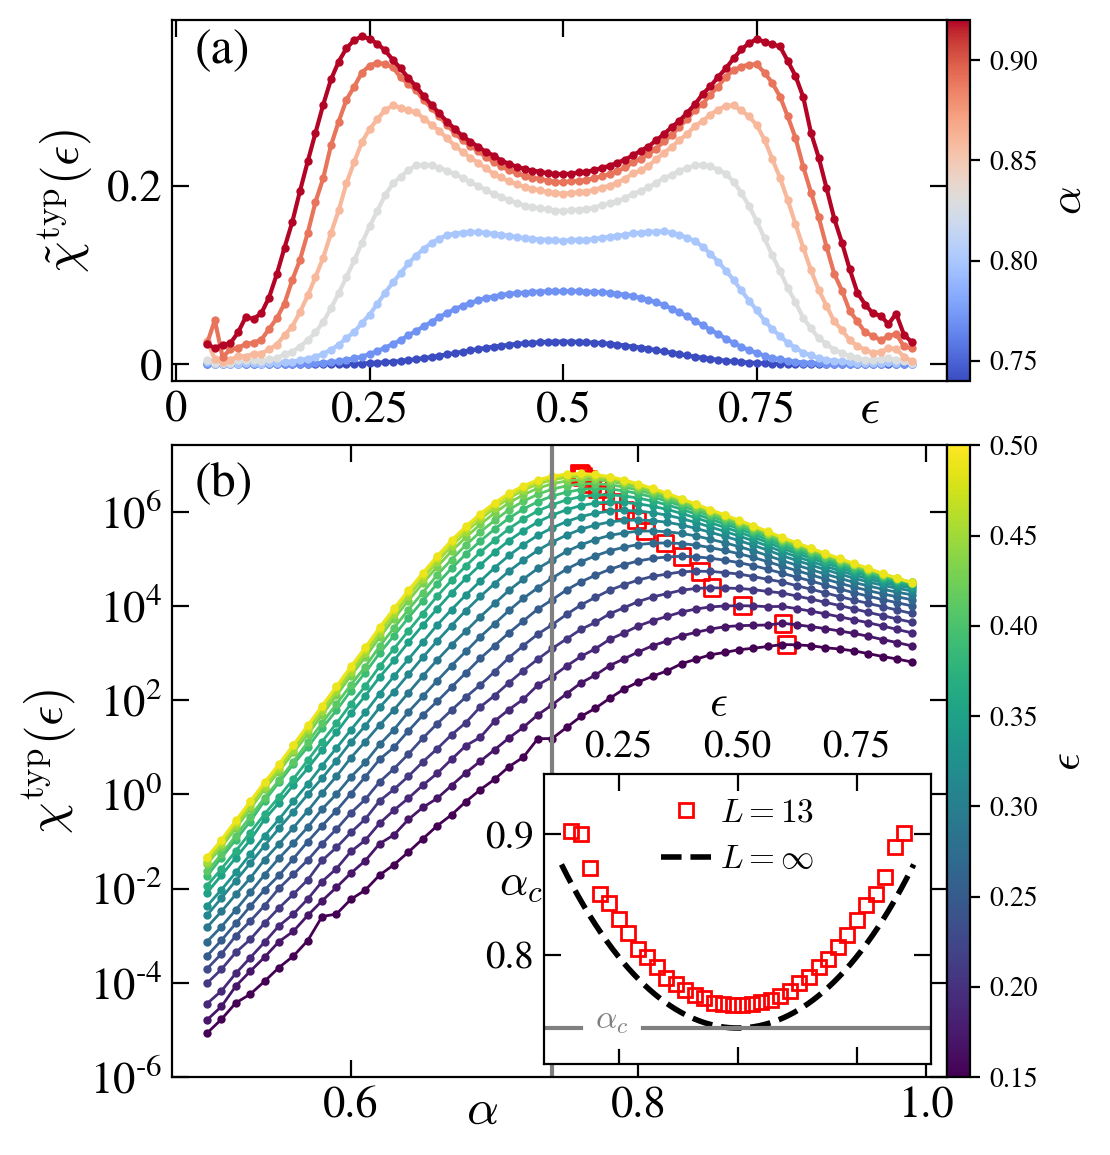

In [699]:
L_total=16

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.74

window = 3

alfa_vals = np.arange(0.5, 1, 0.01)
alfa_plot = np.round(np.arange(0.74, 0.95, 0.03), 2)
print(alfa_plot)


dim = 2**L_total
# fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)
fig = plt.figure(figsize=(5,7), dpi = 200)
fig.subplots_adjust(hspace=0.13, wspace=0.2)
gs = GridSpec(2, 1, height_ratios = [4, 7]) 
# gs1 = GridSpec(1,1)
# gs.update(top=0.98, bottom=0.48, hspace=0.02)
# gs1.update(top=0.4, bottom=0.02)
axis = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

inset = axis[1].inset_axes([0.48, 0.02, 0.5, 0.46])

depsilon = 0.05
_eps_ = np.arange(depsilon, 1.0-depsilon, 0.02)
_eps_ = _eps_[_eps_ <= 0.86]
_eps_ = _eps_[_eps_ >= 0.15]

s_m_a = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm= matplotlib.colors.Normalize(vmin=min(alfa_plot), vmax=max(alfa_plot) ))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm= matplotlib.colors.Normalize(vmin=min(_eps_), vmax=0.5 ))
# s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm= matplotlib.colors.Normalize(vmin=0.5, vmax=max(_eps_) ))
s_m.set_array([])

alfa_c = []
alfa_c2 = []
agp_c = []
for jj in range(_eps_.size):
    eps = _eps_[jj]
    col2 = s_m.to_rgba(eps)
    # print(eps)
    agp      = np.zeros((alfa_vals.size)); agp.fill(np.nan)
    for ii, alfax in enumerate(alfa_vals):
        alfa = np.round(alfax, 2)
        col = s_m_a.to_rgba(alfa)
        eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
        # eta = 2*((1 - alfa_crit))/ ((alfa - alfa_crit))
        
        name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    
        if exists(name):
            with h5py.File(name, "r") as file:
                
                E = np.array(file.get('energy_density')) #[window//2:-window//2]
                wH = np.array(file.get('wH_density'))
                wH_typ = np.array(file.get('wH_typ_density'))
                
                R = np.array(file.get('realisations'))
                DOS = np.array(file.get('DOS')) / R
                idx_05 = min(range(len(E)), key=lambda i: abs(E[i] - 0.5))
                idx2 = min(range(len(E)), key=lambda i: abs(E[i] - eps))
                
                norm = DOS
                
                count = np.array(file.get('count')) / R
                _agp = np.array(file.get('susc_E_typ')) / R
                
                if jj == 0 and (alfa in alfa_plot):
                    yy = _agp * DOS**(2 / eta) * wH_typ**2
                    # yy = _agp / DOS
                    # yy = yy / yy[idx_05]
                    axis[0].plot(E, yy, color=col, marker='o', markersize=2)
                # _agp = _agp / norm
                agp[ii] = _agp[idx2]# / count[idx2]
        else:
            print(name)

    wH = np.sqrt(2**(N-1) * 0.3 + J**2 / 4 * ( (alfa_vals**(2*L+2) - alfa_vals**2) / (alfa_vals**2 - 1) ) + L / 4 * (1 + (w)**2 / 3)) / (0.3413 * dim)
    
    matelem = dim ** (-1/eta)
    norm = dim#max(agp2)#matelem**2 / wH**2
    if eps <= 0.5:
        axis[1].plot(alfa_vals, agp, color=col2, marker='o', markersize=2, lw=1)
    
    idx = np.argmax(agp)
    
    # x = alfa_vals
    indices = np.arange(np.argmax(agp) - 15, min(np.argmax(agp) + 10, agp.size-1), 1)
    x = np.linspace(alfa_vals[indices][0], alfa_vals[indices][-1], 1000)
    f = splrep(alfa_vals[indices], agp[indices], k=3, s=5)
    agp = splev(x, f)
    idx = np.argmax(agp)
    alfa_c.append(x[idx])
    if eps <= 0.5:
        alfa_c2.append(x[idx])
        agp_c.append(agp[idx])
    
    # if eps <= 0.5:
    #     axis.plot(x, agp, color=col2, alpha=0.5)
    
    # if eps <= 0.5:
    #     axis.plot(x, agp, color=col2, lw=4, alpha=0.35)
print(_eps_)
print(alfa_c)
inset.plot(_eps_, alfa_c,  marker='s', color='red', ls='--', markersize=5, lw=0, markerfacecolor='None', label=r"$L=%d$"%(L))

a = 1.05
b = 0.45
alfac = alfa_crit#1 / np.sqrt(2)
x = np.linspace(0.13, 0.87, 1000)
inset.plot(x, alfac * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2), color='k', ls='--', lw=2, label=r"$L=\infty$")
axis[1].scatter(alfa_c2, agp_c, marker='s', color='red', facecolor='None')

axis[0].xaxis.set_label_coords(.9, -0.02)
axis[1].xaxis.set_label_coords(.4, -0.02)

axis[1].axvline(x=alfa_crit, ls='-', c='gray')
# axis.axvline(x=alfa_crit,    ls=':', c='k')

ylab = r"$\tilde{\chi}^{\rm typ}(\epsilon)$"# if projected else r"$||\mathcal{A}_\lambda(\epsilon)||^2$"
fig_help.set_plot_elements(axis[0], ylabel=ylab, xlabel=r"$\epsilon$", font_size=16, set_legend=False, xscale='linear', yscale='linear')
ylab = r"$\chi^{\rm typ}(\epsilon)$"
fig_help.set_plot_elements(axis[1], ylabel=ylab, xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear', yscale='log')
axis[1].set_ylim(1e-6, None)

axis[0].xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%(np.round(x, order_of_magnitude(x))) ))
axis[0].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%(np.round(x, order_of_magnitude(x))) ))

cbar_ax = axis[0].inset_axes([1., 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m_a, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\alpha$", fontsize=16)
cbar_ax.yaxis.set_ticks_position('right')
cbar_ax.yaxis.set_label_position('right')
# divider = make_axes_locatable(axis[1])
# cax = divider.new_vertical(size = '3%', pad = 0.05)
# fig.add_axes(cax)
# cbar = fig.colorbar(s_m, cax = cax, orientation = 'horizontal')
# cax.xaxis.set_ticks_position('top')
# cax.xaxis.set_label_position('top')
# cbar.set_label(r"$\epsilon$", fontsize=16)

cbar_ax = axis[1].inset_axes([1., 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\epsilon$", fontsize=16)
cbar_ax.yaxis.set_ticks_position('right')
cbar_ax.yaxis.set_label_position('right')

inset.xaxis.set_label_position("top")
inset.xaxis.set_label_coords(.45, 1.2)
inset.xaxis.tick_top()

inset.yaxis.set_label_position("left")
inset.yaxis.set_label_coords(-0.06, 0.55)
inset.yaxis.tick_left()
fig_help.set_plot_elements(inset, ylabel=r"$\alpha_c^*$", xlabel=r"$\epsilon$", font_size=14, set_legend=False, xscale='linear', yscale='linear')
fig_help.set_legend(inset, fontsize=12, loc='upper center')

# inset.set_yticks([0.71, 0.73, 0.74])
# inset.set_xticks([0.2, 0.3, 0.4, 0.5])
inset.set_ylabel(r"$\alpha_c$", rotation=0, fontsize=16)

inset.axhline(y=alfa_crit,    ls='-', color='gray')
# inset.axhline(y=1/np.sqrt(2), ls='-', color='gray')
inset.set_ylim(0.71, 0.95)
# inset.annotate(r"$\tilde{\alpha}_c$", color='gray', fontsize=12, xy=(0.3, 0.7075), xycoords='data', backgroundcolor="w")
inset.annotate(r"${\alpha}_c$", color='gray', fontsize=12, xy=(0.2, 0.74), xycoords='data', backgroundcolor="w")

axis[0].annotate(r"(a)", fontsize=18, xy=(0.03, 0.88), xycoords='axes fraction')
axis[1].annotate(r"(b)", fontsize=18, xy=(0.03, 0.92), xycoords='axes fraction')

# fig.savefig("plots_AGP/Fig3.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [ ]:
0.825 / 0.025

## FIG. 4

In [ ]:
markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)
L_total=13

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.74

alfa_vals = np.arange(0.5, 0.9, 0.01)
print(alfa_vals)


dim = 2**L_total
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3.), dpi = 200)

_eps_  = np.arange(0.2, 0.52, 0.05)
sizes = np.arange(8, 17, 1) - N

_eps_ = [0.15, 0.25, 0.33, 0.4, 0.5]
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm= matplotlib.colors.Normalize(vmin=min(_eps_), vmax=0.5 ))
s_m.set_array([])

wH_at_max = []
agp_max = []
for L in sizes:
    dim = 2**(L+N)
    agp = np.zeros((alfa_vals.size)); agp.fill(np.nan)
    wH = np.zeros((alfa_vals.size)); wH.fill(np.nan)
    for ii, alfa in enumerate(alfa_vals):
        name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)

        if exists(name):
            with h5py.File(name, "r") as file:
                R = np.array(file.get('realisations'))
                agp[ii] = np.array(file.get('TYP_SUSC'))[-2]
                wH[ii]  = np.array(file.get('wH'))[-2]
        else:
            print(name)
    wH_at_max.append(wH[np.argmax(agp)])
    indices = np.arange(np.argmax(agp) - 10, min(np.argmax(agp) + 10, agp.size-1), 1)
    x = np.linspace(alfa_vals[indices][0], alfa_vals[indices][-1], 1000)
    f = splrep(alfa_vals[indices], agp[indices], k=5, s=10)
    agp = splev(x, f)
    agp_max.append(max(agp))

agp_max = np.array(agp_max)
wH_at_max = np.array(wH_at_max)
hangle = axis.scatter(1/wH_at_max**2, agp_max, marker='s', color='red', facecolor='None', label=r"$\max(\chi^{\rm typ})$") 

other_handles = []
for aa, eps in enumerate(_eps_):
    mar = next(markers)
    col = s_m.to_rgba(eps)
    agp_max = []
    wH_at_max = []
    for L in sizes:
        dim = 2**(L+N)
        agp_E = np.zeros((alfa_vals.size)); agp_E.fill(np.nan)
        wH = np.zeros((alfa_vals.size)); wH.fill(np.nan)
        for ii, alfa in enumerate(alfa_vals):
            name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        
            if exists(name):
                with h5py.File(name, "r") as file:
                    R = np.array(file.get('realisations'))
                    E = np.array(file.get('energy_density'))
                    
                    DOS = np.array(file.get('DOS'))
                    idx2 = min(range(len(E)), key=lambda i: abs(E[i] - eps))
                    count = np.array(file.get('count'))
                    _agp = np.array(file.get('susc_E_r_typ')) / R# / count
                    agp_E[ii] = _agp[idx2]
                    wH[ii] = np.array(file.get('wH_density'))[idx2]
            else:
                print(name)
        wH_at_max.append(wH[np.argmax(agp_E)])
        indices = np.arange(np.argmax(agp_E) - 15, min(np.argmax(agp_E) + 15, agp_E.size-1), 1)
        x = np.linspace(alfa_vals[indices][0], alfa_vals[indices][-1], 1000)
        f = splrep(alfa_vals[indices], agp_E[indices], k=5, s=10)
        agp_E = splev(x, f)
        agp_max.append(max(agp_E))
    
    agp_max = np.array(agp_max)
    wH_at_max = np.array(wH_at_max)
    han = axis.scatter(1/wH_at_max**2, agp_max, color=col, label=r"$\epsilon=%g$"%eps, marker=mar, facecolor='None' if aa%2 else col)
    other_handles.append(han)
    
x = np.logspace(2.5, 9, 100)
def scaling(x):
    return x / 20
last_handle, = axis.plot(x, scaling(x), ls='--', c='k', label=r'$1/\omega_H^2$')
# axis.plot(x, scaling(x)**2, ls='--', c='k')
fig_help.set_plot_elements(axis, ylabel=r"$\max(\chi^{\rm typ}(\epsilon))$", xlabel=r"$1/\omega_H^2(\epsilon)$", font_size=16, set_legend=True, xscale='log', yscale='log')
_legend = fig_help.set_legend(axis, fontsize=15, loc='upper left', handles = other_handles)
ax = plt.gca().add_artist(_legend)
_legend = fig_help.set_legend(axis, fontsize=15, loc='lower right', handles = [hangle, last_handle])
ax = plt.gca().add_artist(_legend)

# axis.set_xlim(min(x), max(x))
# axis.set_ylim( min(scaling(x)), max(scaling(x)) )

fig.savefig("plots_AGP/Fig4.pdf", bbox_inches = 'tight', pad_inches=0.02)

## Mobility edge -- heatmap

In [ ]:

markers = itertools.cycle(markers_ls)


L_total=16

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,6), dpi = 200)

J=1

alfa=0.6
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_vals = np.arange(0.5, 1., 0.01)
    
window = 6

energy_density = None
AGP_density = []

dim = 2**L_total
_min = 1e6
_max = -1e6
for ii, alfa in enumerate(alfa_vals):
    eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
    
    name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    if exists(name):
        with h5py.File(name, "r") as file:
            E = np.array(file.get('energy_density'))
            DOS = np.array(file.get('DOS'))
            count = np.array(file.get('count'))
            agp2 = np.array(file.get('susc_E_typ'))
            
            wH = np.array(file.get('wH_density'))
            
            agp2 = agp2 / count#**(2/eta) * wH**2
            
            # agp2 = tools.remove_fluctuations(agp2, bucket_size=window)[window//2:-window//2]
            # E = E[window//2:-window//2]
            # agp2 = (agp2 - min(agp2)) / (max(agp2) - min(agp2))
            # agp2 = agp2 / max(agp2)
            
            if min(agp2) < _min: _min = min(agp2)
            if max(agp2) > _max: _max = max(agp2)
            AGP_density.append(agp2)
            energy_density = E
    else:
        print(name)

energy_density = np.array(energy_density)
AGP_density2 = np.transpose(np.array(AGP_density))
AGP_density = []
for agp in AGP_density2:
    agp2 = (agp - min(agp)) / (max(agp) - min(agp))
    # agp2 = agp
    AGP_density.append(agp2)

AGP_density = np.array(AGP_density)
# AGP_density = []
# for x in x_coll:
#     x = (x - min(x)) / (max(x) - min(x))
#     AGP_density.append(x)
# AGP_density = (AGP_density - _min) / (_max - _min)
# AGP_density = np.array(AGP_density)

interaction = np.array([alfa_vals for _ in energy_density])

#white = plt.get_cmap('seismic', 100)(0.5*np.ones(1))
upper = plt.get_cmap('YlGnBu', 100)(np.linspace(0.0, 1.0, 100))
colors = np.vstack((upper))  

mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

X, Y = np.meshgrid(alfa_vals, energy_density)

p = axis.pcolormesh(X, Y, AGP_density, shading='nearest', cmap=mymap)#, vmin=0, vmax=1)
fig_help.set_plot_elements(axis, ylabel=r"$\epsilon$", xlabel=r"$\alpha$", font_size=14, set_legend=False)
axis.set_title(r"$L=%d, N=%d, g_0=%.2f$"%(L, N, J), fontsize=16)
clb = fig.colorbar(p)
clb.ax.set_title(r"$\chi^{\rm typ}(\epsilon) / \rho(\epsilon)$")
#/\rho(\epsilon)

# axis.xaxis.set_minor_locator(plt.NullLocator())
# axis.yaxis.set_minor_locator(plt.NullLocator())

#legend = axis.legend(frameon=1, fontsize=14, loc='upper left', handletextpad=0.25, handlelength = 1.25, bbox_to_anchor=(0.0,1.0), facecolor="gray")

a = 1
b = 0.42
alfac = alfa_crit#1 / np.sqrt(2)
x = np.linspace(0.06, 0.94, 1000)
axis.plot(alfac * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2), x, color='red', ls='--', lw=2)

fig.savefig("plots_AGP/Fig6.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [ ]:

markers = itertools.cycle(markers_ls)


L_total=16

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,4), dpi = 200)

J=1

alfa=0.6
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_vals = np.arange(0.5, 0.999, 0.01)
    
window = 6
projected = 1

energy_density = None
gap_ratio_density = []
for ii, alfa in enumerate(alfa_vals):
    name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    if exists(name):
        with h5py.File(name, "r") as file:
            E = np.array(file.get('energy_density'))
            E = E[1:-1]
            gap_ratio = np.array(file.get('gap_ratio_density'))[1:-1]
            # gap_ratio = (gap_ratio - 0.3867) / (0.5307 - 0.3867)
            gap_ratio_density.append(gap_ratio)
            energy_density = E
    else:
        print(name)

energy_density = np.array(energy_density)
gap_ratio_density = np.array(gap_ratio_density)

interaction = np.array([alfa_vals for _ in energy_density])

#white = plt.get_cmap('seismic', 100)(0.5*np.ones(1))
upper = plt.get_cmap('gnuplot', 100)(np.linspace(0.0, 1.0, 100))
colors = np.vstack((upper))  

mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

X, Y = np.meshgrid(alfa_vals, energy_density)

p = axis.pcolormesh(X, Y, np.transpose(gap_ratio_density), shading='nearest', cmap=mymap, vmin=0.3867, vmax=0.5309)
fig_help.set_plot_elements(axis, ylabel=r"$\epsilon$", xlabel=r"$\alpha$", font_size=14, set_legend=False)
# axis.set_title(r"$L=%d, N=%d, g_0=%.2f$"%(L, N, J), fontsize=16)
clb = fig.colorbar(p)
clb.ax.set_title(r"$\langle r\rangle$")

dist = stats.norm(loc=0.5, scale=0.25)
bounds = dist.cdf([0, 1])
pp = np.linspace(*bounds, num=101)
_eps_ = np.round(dist.ppf(pp), 4)
_eps_ = _eps_[_eps_ < 0.9]
_eps_ = _eps_[_eps_ > 0.1]


sizes = np.arange(16, 17,1) - N
# sizes = np.array([9, 10]) - N
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) ))
s_m.set_array([])

for L in sizes:
    alfa_c = []
    for jj in range(_eps_.size):
        eps = _eps_[jj]
        col2 = s_m.to_rgba(eps)
        # print(eps)
        agp      = np.zeros((alfa_vals.size)); agp.fill(np.nan)
        reals    = np.zeros((alfa_vals.size)); reals.fill(np.nan)
        for ii, alfa in enumerate(alfa_vals):
            name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        
            if exists(name):
                with h5py.File(name, "r") as file:
                    
                    E = np.array(file.get('energy_density'))
                    R = np.array(file.get('realisations'))
                    DOS = np.array(file.get('DOS')) / R
                    idx2 = min(range(len(E)), key=lambda i: abs(E[i] - eps))
                    
                    reals[ii] = R
                    norm = DOS
                    count = np.array(file.get('count'))
                    _agp = np.array(file.get('susc_E_typ')) / R #/ count# / DOS
                    # _agp = tools.remove_fluctuations(_agp, bucket_size=window)[window//2:-window//2] / count[window//2:-window//2]
                    # _agp = tools.remove_fluctuations(_agp, bucket_size=window)[window//2:-window//2]
                    agp[ii] = _agp[idx2]
            else:
                print(name)

        x = alfa_vals
        indices = np.arange(max(np.argmax(agp) - 10, 0), min(np.argmax(agp) + 10, agp.size-1), 1)
        x = np.linspace(alfa_vals[indices][0], alfa_vals[indices][-1], 1000)
        f = splrep(alfa_vals[indices], agp[indices], k=5, s=10)
        agp = splev(x, f)
        idx = np.argmax(agp)
        alfa_c.append(x[idx])
    
    axis.plot(alfa_c, _eps_,  marker='v', color='blue', ls='--', markersize=4, lw=0, label=r"$\max({\chi^{\rm typ}(\epsilon)})$")
    print(L, "done", min(reals), max(reals))

a = 1.05
b = 0.45
alfac = alfa_crit#1 / np.sqrt(2)
x = np.linspace(0.06, 0.94, 1000)
axis.plot(alfac * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2), x, color='k', ls='-', lw=2, label=r"Mobility Edge")
fig_help.set_legend(axis, fontsize=14, loc='lower left', anchor=(0.0, 0.96), ncol=2)

fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [ ]:

markers = itertools.cycle(markers_ls)


L_total=15

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,6), dpi = 200)
J=1

alfa=0.6
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_vals = np.arange(0.5, 0.999, 0.01)
    
window = 6
projected = 1

sizes = np.arange(10, 17,1) - N
# sizes = np.array([9, 10]) - N
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm= matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) ))
s_m.set_array([])

for L in sizes:
    alfa_c = []
    for jj in range(_eps_.size):
        eps = _eps_[jj]
        col2 = s_m.to_rgba(eps)
        # print(eps)
        agp      = np.zeros((alfa_vals.size)); agp.fill(np.nan)
        reals    = np.zeros((alfa_vals.size)); reals.fill(np.nan)
        for ii, alfa in enumerate(alfa_vals):
            name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        
            if exists(name):
                with h5py.File(name, "r") as file:
                    
                    E = np.array(file.get('energy_density'))
                    R = np.array(file.get('realisations'))
                    DOS = np.array(file.get('DOS')) / R
                    idx2 = min(range(len(E)), key=lambda i: abs(E[i] - eps))
                    
                    reals[ii] = R
                    norm = DOS
                    count = np.array(file.get('count'))
                    _agp = np.array(file.get('susc_E_typ')) / R #/ count# / DOS
                    # _agp = tools.remove_fluctuations(_agp, bucket_size=window)[window//2:-window//2] / count[window//2:-window//2]
                    # _agp = tools.remove_fluctuations(_agp, bucket_size=window)[window//2:-window//2]
                    agp[ii] = _agp[idx2]
            else:
                print(name)

        x = alfa_vals
        indices = np.arange(max(np.argmax(agp) - 10, 0), min(np.argmax(agp) + 10, agp.size-1), 1)
        x = np.linspace(alfa_vals[indices][0], alfa_vals[indices][-1], 1000)
        f = splrep(alfa_vals[indices], agp[indices], k=5, s=10)
        agp = splev(x, f)
        idx = np.argmax(agp)
        alfa_c.append(x[idx])
    
    axis.plot(_eps_, alfa_c,  marker='v', color=s_m.to_rgba(L), ls='--', markersize=3, lw=0)
    print(L, "done", min(reals), max(reals))

a = 1.05
b = 0.45
alfac = alfa_crit#1 / np.sqrt(2)
x = np.linspace(0.06, 0.94, 1000)
axis.plot(x, alfac * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2), color='k', ls='-', lw=2)

cax = None
cbar = None
divider = make_axes_locatable(axis)
cax = divider.new_vertical(size = '3%', pad = 0.05)
fig.add_axes(cax)
cbar = fig.colorbar(s_m, cax = cax, orientation = 'horizontal')
cax.xaxis.set_ticks_position('top')
cax.xaxis.set_label_position('top')
cbar.set_label(r"$L$", fontsize=16)


fig_help.set_plot_elements(axis, xlabel=r"$\epsilon$", ylabel=r"$\alpha_c$", font_size=14, set_legend=False)
# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [ ]:

markers = itertools.cycle(markers_ls)


L_total=15

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)

J=1

alfa=0.6
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.74

sizes = np.arange(8, 17,1) - N
_eps_ = np.array([0.2, 0.3, 0.4, 0.5])
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm= matplotlib.colors.Normalize(vmin=min(_eps_), vmax=max(_eps_) ))
s_m.set_array([])

for jj in range(_eps_.size):
    eps = _eps_[jj]
    col = s_m.to_rgba(eps)
    alfa_c = []
    for L in sizes:
        col2 = s_m.to_rgba(eps)
        # print(eps)
        agp      = np.zeros((alfa_vals.size)); agp.fill(np.nan)
        reals    = np.zeros((alfa_vals.size)); reals.fill(np.nan)
        for ii, alfa in enumerate(alfa_vals):
            name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        
            if exists(name):
                with h5py.File(name, "r") as file:
                    
                    E = np.array(file.get('energy_density'))
                    R = np.array(file.get('realisations'))
                    DOS = np.array(file.get('DOS')) / R
                    idx2 = min(range(len(E)), key=lambda i: abs(E[i] - eps))
                    
                    reals[ii] = R
                    norm = DOS
                    count = np.array(file.get('count'))
                    _agp = np.array(file.get('susc_E_typ')) / R
                    agp[ii] = _agp[idx2]
            else:
                print(name)

        x = alfa_vals
        indices = np.arange(max(np.argmax(agp) - 10, 0), min(np.argmax(agp) + 10, agp.size-1), 1)
        x = np.linspace(alfa_vals[indices][0], alfa_vals[indices][-1], 1000)
        f = splrep(alfa_vals[indices], agp[indices], k=5, s=10)
        agp = splev(x, f)
        idx = np.argmax(agp)
        alfa_c.append(x[idx])
    
    
    a = 1.05
    b = 0.45
    alfac = alfa_crit * np.exp(a**2 * (eps - 0.5)**2 / 4 / b*2)
    alfa_c = np.array(alfa_c) - alfac
    
    axis.scatter(1/sizes, alfa_c,  marker=next(markers), color=col, label=r'$\epsilon=%g$'%eps)
    def fit_alf(x, a, b):
        return a * x + b * x**2
    pars, pconv= fit(fit_alf,
                    xdata = 1/sizes[-5:],
                    ydata = alfa_c[-5:],
                    maxfev = 20000)
    x = np.linspace(0, 0.8/min(sizes), 1000)
    axis.plot(x, fit_alf(x, *pars),  color=col, ls='--')
    
    # axis.axhline(y=alfac, color=col, ls='-', xmax=0.2)
    
    print(eps, "done", min(reals), max(reals))
axis.set_xlim(0, max(1/sizes)*1.04)
axis.set_ylim(0, None)
axis.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
axis.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
fig_help.set_plot_elements(axis, xlabel=r"$1/L$", ylabel=r"$\alpha^*_c(\epsilon)-{\alpha}_c(\epsilon)$", font_size=14, set_legend=False)
fig_help.set_legend(axis, fontsize=14, ncol=2, loc='upper left')
fig.savefig("plots_AGP/FigS3.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [ ]:
24 * 11 * 20

dE 0.999885741372736 3.2129764420851874
dE 1.0001615112146809 3.215692006759996
dE 0.9989251156189777 3.229058590078901
dE 0.9989567354145498 3.2345399993150954
dE 1.0001180153961418 3.231883083115096
dE 1.0012098728972156 3.230341055003501
dE 1.0016628633461768 3.233457686418653
dE 1.0028996657848497 3.2316044438815483
dE 1.0016677142652315 3.248089318247932
dE 1.0031317609439883 3.2461379090587346
dE 1.0040264082064314 3.2475222491352675
dE 1.003580918962181 3.2603701706930863
dE 1.0058447926345493 3.254548428389005
dE 1.007745685537797 3.2519142163830757
dE 1.010575321203005 3.2437600576742325
dE 1.0112964127537873 3.250991192510792
dE 1.0183246701261648 3.214295070218185
dE 1.0195791238277918 3.219708777538813
dE 1.0222415121991608 3.217567676942286
dE 1.026382725765622 3.206481480017111
dE 1.0294728007692489 3.2037470871876224
dE 1.0355069079931154 3.18216479102623
dE 1.042204206337082 3.157961017202239
dE 1.0496962882166088 3.1305708694813297
dE 1.0585879836221301 3.0948629980693

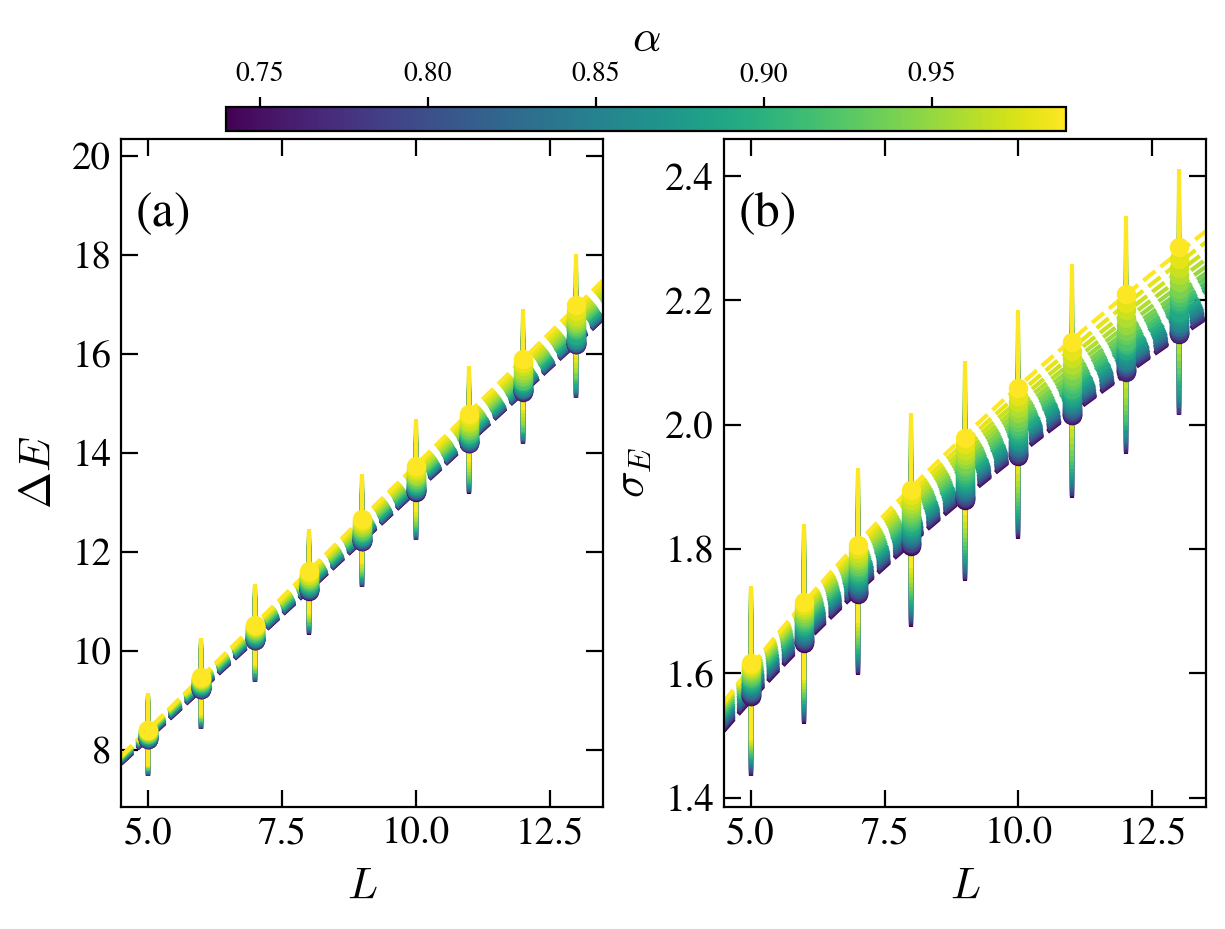

In [33]:
L_total=15

fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(7,4), dpi = 200, sharex=True)

J=1

alfa=0.99
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

sizes = np.arange(8, 17) - N
alfa_vals = np.arange(0.74, 1, 0.01)
ass = []
bss = []

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm= matplotlib.colors.Normalize(vmin=min(alfa_vals), vmax=max(alfa_vals) ))
# s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm= matplotlib.colors.Normalize(vmin=0.5, vmax=max(_eps_) ))
s_m.set_array([])

for alfa in alfa_vals:
    col = s_m.to_rgba(alfa)
    window = 4
    projected = 0
    # for ii, alfa in enumerate(alfa_vals):
    dE_mean = []
    dE_sig  = []
    sig_mean = []
    sig_sig  = []
    for L in sizes:
        name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                dE  = np.array(file.get('bandwidth'))
                dE_mean.append( np.mean(dE) )
                dE_sig.append( np.std(dE) )
                
                sig = np.array(file.get('stddev'))
                sig_mean.append( np.mean(sig) )
                sig_sig.append( np.std(sig) )
        else:
            print(name)
            dE_mean.append(np.nan)
            dE_sig.append(np.nan)
            sig_sig.append(np.nan)
            sig_mean.append(np.nan)
    sig_mean = np.array(sig_mean)
    sig_sig = np.array(sig_sig)
    dE_mean = np.array(dE_mean)
    dE_sig = np.array(dE_sig)
    axis[0].errorbar(sizes, dE_mean,  yerr=dE_sig, fmt='o',  color=col)
    axis[1].errorbar(sizes, sig_mean, yerr=sig_sig, fmt='o', color=col)
    # axis[0].scatter(sizes, dE_mean, marker='o', color=col)
    # axis[0].fill_between(sizes, dE_mean - dE_sig, dE_mean + dE_sig, color=col, alpha=0.2)

    yy = np.array(dE_mean)
    zz = np.array(sig_mean)
    xx = sizes[~np.isnan(yy)]
    zz = zz[~np.isnan(yy)]
    yy = yy[~np.isnan(yy)]


    def fita(x, a, b):
        return a * x + b
    pars, pconv= fit(fita,
                    xdata = xx,
                    ydata = yy,
                    maxfev = 20000)
    print("dE", *pars)
    z = np.linspace(0.9*min(xx), 1.2*max(xx), 1000)
    axis[0].plot(z, fita(z, *pars), lw=1.5, ls = '--', color=col)
    ass.append(pars[0])
    def fita(x, a, b):
        return a * np.sqrt(x) + b
    pars, pconv= fit(fita,
                    xdata = xx,
                    ydata = zz,
                    maxfev = 20000)
    
    z = np.linspace(min(xx)-0.5, max(xx)+0.5, 1000)
    axis[1].plot(z, fita(z, *pars), lw=1.5, ls = '--', color=col)
    bss.append(pars[0])
print("dE", ass)
print("sig", bss)

axis[0].set_xlim(4.5, 13.5)
fig_help.set_plot_elements(axis[0], ylabel=r"$\Delta E$", xlabel=r"$L$", font_size=14, set_legend=False)
fig_help.set_plot_elements(axis[1], ylabel=r"$\sigma_E$", xlabel=r"$L$", font_size=14, set_legend=False)


fig.subplots_adjust(top=0.96)
cbar_ax = fig.add_axes([0.2, 0.97, 0.6, 0.03])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$\alpha$", fontsize=16)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')

axis[0].annotate(r"(a)", fontsize=18, xy=(0.03, 0.87), xycoords='axes fraction')
axis[1].annotate(r"(b)", fontsize=18, xy=(0.03, 0.87), xycoords='axes fraction')

fig.subplots_adjust(wspace = 0.25, hspace=0.03)
fig.savefig("plots_AGP/FigS1.pdf", bbox_inches = 'tight', pad_inches=0.02)

## Different operators, scaling of fidelity

[0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73
 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87
 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99]
-1 5 10000.0 10000.0
-1 6 10000.0 10000.0
-1 7 10000.0 10000.0
-1 8 10000.0 10000.0
-1 9 10000.0 10000.0
-1 10 7788.0 8000.0
-1 11 6040.0 6777.0
-1 12 1284.0 1634.0
0 5 10000.0 10000.0
0 6 10000.0 10000.0
0 7 10000.0 10000.0
0 8 10000.0 10000.0
0 9 9727.0 10000.0
0 10 7413.0 9275.0
0 11 2756.0 3000.0
0 12 980.0 2311.0
1 5 10000.0 10000.0
1 6 10000.0 10000.0
1 7 10000.0 10000.0
1 8 10000.0 10000.0
1 9 10000.0 10000.0
1 10 8007.0 9284.0
1 11 2777.0 3000.0
1 12 957.0 1132.0


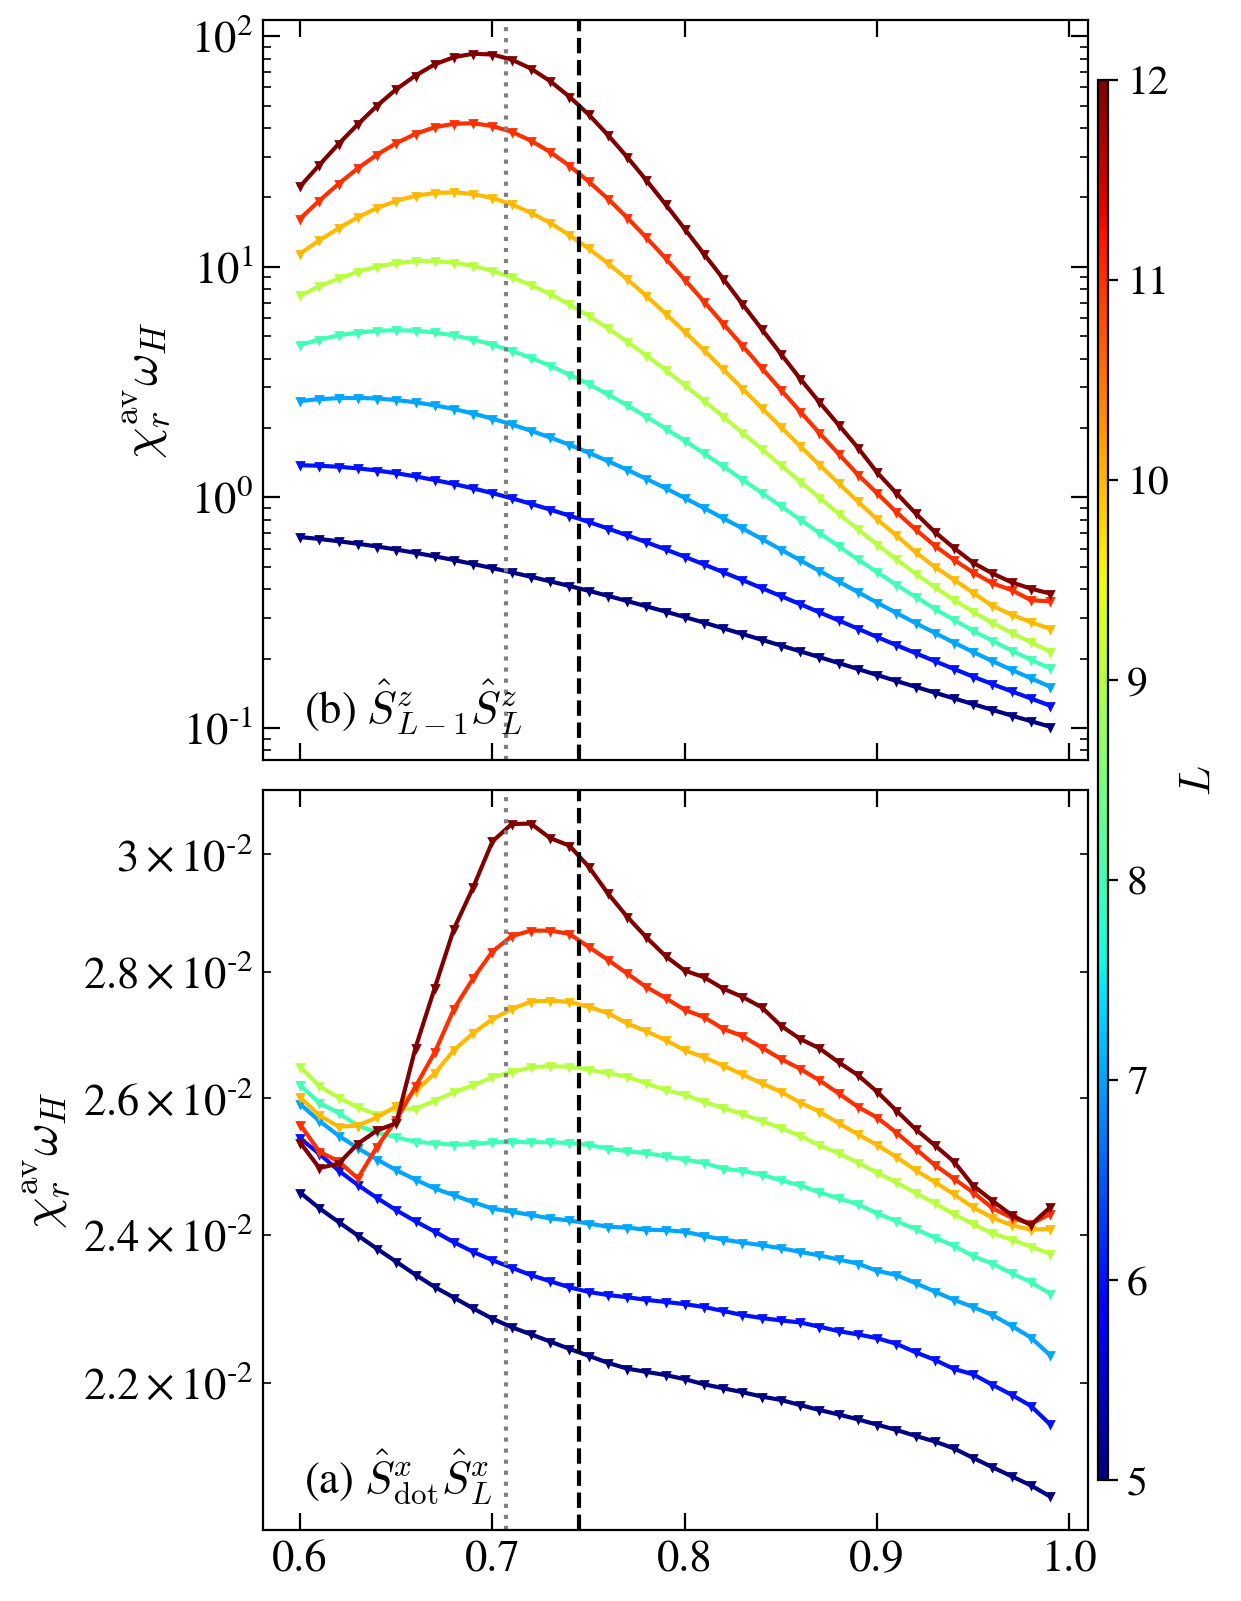

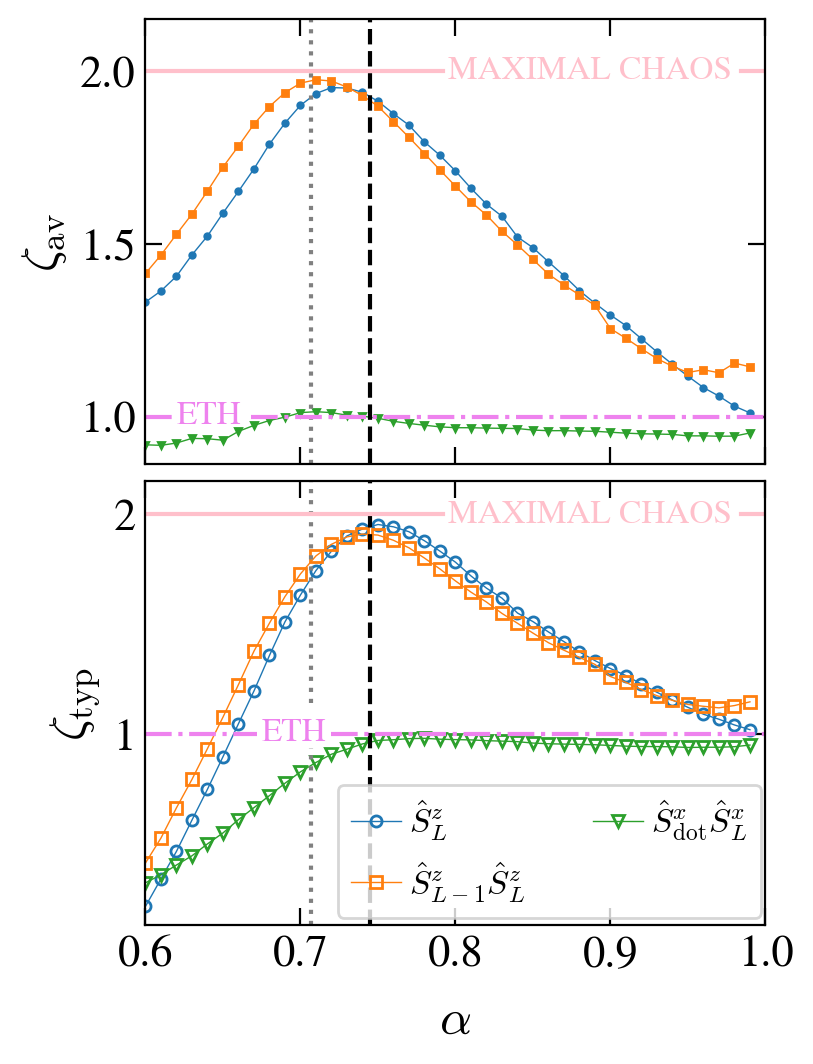

In [629]:
markers = itertools.cycle(markers_ls)
colors_ls_cyc = itertools.cycle(colors_ls)
L_total=15

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745


AGP = 1

alfa_vals = np.arange(0.6, 1., 0.01)
print(alfa_vals)

sizes = np.arange(8, 16, 1) - N
norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(5,10), dpi = 200, sharex = True)
axis = np.array(axis).flatten()

figa, ax_fit = plt.subplots( nrows=2, ncols=1, figsize=(4,6), dpi = 200, sharex = True)

names = ["", "SzSz_last", "Sx_dot_Sx_last", "SxSx_last"]
labels = [r"$\hat{S}^z_{L}$", r"$\hat{S}^z_{L-1}\hat{S}^z_{L}$", r"$\hat{S}^x_{\rm dot}\hat{S}^x_{L}$", r"$\hat{S}^x_{L-1}\hat{S}^x_{L}$"]
# labels = [r"$\hat{S}^z_{L}$", r"$\hat{S}^z_{\rm dot}\hat{S}^z_{L}$", r"$\hat{S}^z_{L-1}\hat{S}^z_{L}$", r"$\hat{S}^x_{\rm dot}\hat{S}^x_{L}$", r"$\hat{S}^x_{L-1}\hat{S}^x_{L}$"]
for iiop2, opname in enumerate(names[:-1]):
    iiop = iiop2 - 1
    susc_max = []
    alfa_max = []
    
    all_susc = []
    all_agp = []
    for L in sizes:
        col = s_m.to_rgba(L)
        dim = 2**(L+N)
        agp      = np.zeros((alfa_vals.size)); agp.fill(np.nan)
        susc     = np.zeros((alfa_vals.size)); susc.fill(np.nan)
        typ_susc = np.zeros((alfa_vals.size)); typ_susc.fill(np.nan)
        realis = np.zeros((alfa_vals.size)); realis.fill(np.nan)
        for ii, alfa in enumerate(alfa_vals):
            name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        
            if exists(name):
                with h5py.File(name, "r") as file:
                    R = np.array(file.get('realisations'))
                    DOS = max(np.array(file.get('DOS'))) / R
                    
                    wHx = np.array(file.get('wH'))[-2]
                    wHx_typ = np.array(file.get('wH_typ'))[-2]
            else:
                print(name)
            name = base_dir + 'AGP/' + opname + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        
            if exists(name):
                with h5py.File(name, "r") as file:
                    agp[ii] = np.array(file.get('AGP'))
                    susc[ii] = np.array(file.get('SUSC'))
                    typ_susc[ii] = np.array(file.get('TYP_SUSC'))
                    realis[ii] = np.array(file.get('realisations'))
                    
            else:
                print(name)

        wH = np.sqrt(2**(N-1) * 0.3 + J**2 / 4 * ( (alfa_vals**(2*L+2) - alfa_vals**2) / (alfa_vals**2 - 1) ) + L / 4 * (1 + (w)**2 / 3)) / (0.3413 * dim)# / np.sqrt(L)
        eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
        matelem = dim # ** ( (2/eta) )
        norm = 1 / (dim * wH**2)
        norm = dim / np.sqrt(L)#**0.98
        
        yy = susc if AGP else typ_susc
        
        if iiop >=0: axis[iiop].plot(alfa_vals, yy * wHx_typ**2 / wH, color=col, marker='v', markersize=2)
        all_susc.append(typ_susc)
        all_agp.append(susc)
        print(iiop, L, min(realis), max(realis))
    #     indices = np.where(np.logical_and(alfa_vals >= 0.6, alfa_vals < 0.8))[0]
    #     xx = alfa_vals[indices]
    #     yy = yy[indices]
    #     x = np.linspace(xx[0], xx[-1], 1000)
    #     f = splrep(xx, yy, k=5, s=10)
    #     yy = splev(x, f)
    #     idx = np.argmax(yy)
    #     susc_max.append(yy[idx] / dim)
    #     alfa_max.append(x[idx])
    all_susc = np.transpose(np.array(all_susc))
    all_agp = np.transpose(np.array(all_agp))
    exponent1 = []
    exponent2 = []
    for iia, alfa in enumerate(alfa_vals):
        yy = all_susc[iia]
        zz = all_agp[iia][~np.isnan(yy)]
        xx = 2**(sizes[~np.isnan(yy)] + N)
        yy = yy[~np.isnan(yy)]

        pars, pconv= fit(power_law,
                        xdata = xx[2:],
                        ydata = yy[2:],
                        maxfev = 20000)
        # print(iiop, alfa, pars[0])
        exponent2.append(pars[0])
        pars, pconv= fit(power_law,
                        xdata = xx[2:],
                        ydata = zz[2:],
                        maxfev = 20000)
        # print(iiop, alfa, pars[0])
        exponent1.append(pars[0])
    # axis[iiop].plot(alfa_max, susc_max,  marker='s', color='black', markerfacecolor='None', ls='--', markersize=5)
    mar = next(markers)
    col = next(colors_ls_cyc)
    ax_fit[0].plot(alfa_vals, exponent1, lw=0.5, marker=mar, markersize=2, color=col)
    ax_fit[1].plot(alfa_vals, exponent2, lw=0.5, marker=mar, markersize=4, color=col, markerfacecolor='None', label=labels[iiop2])
    if iiop >=0: 
        if AGP : fig_help.set_plot_elements(axis[iiop], ylabel=r"$\chi^{\rm av }_r\omega_H$", xlabel=r"$\alpha$" if iiop>1 else "", font_size=16, set_legend=False, xscale='linear', yscale='log' if iiop < 2 else 'linear')
        else:    fig_help.set_plot_elements(axis[iiop], ylabel=r"$\chi^{\rm typ}_r\omega_H$", xlabel=r"$\alpha$" if iiop>1 else "", font_size=16, set_legend=False, xscale='linear', yscale='log')
# axis[1].plot(alfa_max2, susc_max, marker='s', color='black', markerfacecolor='None', ls='--', markersize=5)
    
fig_help.set_plot_elements(ax_fit[0], ylabel=r"$\zeta_{\rm av}$", xlabel="", font_size=16, set_legend=False, xscale='linear', yscale='linear')
fig_help.set_plot_elements(ax_fit[1], ylabel=r"$\zeta_{\rm typ}$", xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear', yscale='linear')
fig_help.set_legend(ax_fit[1], fontsize=12, loc='lower right', ncol=2, frameon=True)
# fig.subplots_adjust(top=0.94)
# cbar_ax = fig.add_axes([0.15, 0.95, 0.7, 0.04])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
# cbar.set_label(r"$L$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$L$", fontsize=16)
cbar.ax.tick_params(labelsize=15)
if AGP:
    axis[0].annotate(r"(b) $\hat{S}^z_{L-1}\hat{S}^z_{L}$",     fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')
    axis[1].annotate(r"(a) $\hat{S}^x_{\rm dot}\hat{S}^x_{L}$", fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')
    # axis[2].annotate(r"(c) $\hat{S}^x_{\rm dot}\hat{S}^x_{L}$", fontsize=16, xy=(0.7, 0.9), xycoords='axes fraction')
    # axis[3].annotate(r"(d) $\hat{S}^x_{L-1}\hat{S}^x_{L}$",     fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')
else:
    axis[0].annotate(r"(b) $\hat{S}^z_{L-1}\hat{S}^z_{L}$",     fontsize=16, xy=(0.65, 0.05), xycoords='axes fraction')
    axis[1].annotate(r"(a) $\hat{S}^x_{\rm dot}\hat{S}^x_{L}$", fontsize=16, xy=(0.65, 0.05), xycoords='axes fraction')
    # axis[2].annotate(r"(c) $\hat{S}^x_{\rm dot}\hat{S}^x_{L}$", fontsize=16, xy=(0.65, 0.05), xycoords='axes fraction')
    # axis[3].annotate(r"(d) $\hat{S}^x_{L-1}\hat{S}^x_{L}$",     fontsize=16, xy=(0.65, 0.05), xycoords='axes fraction')
 
for ax in [*axis, ax_fit[0]]:
    ax.axvline(x=1/np.sqrt(2), ls=':', c='gray')
    ax.axvline(x=alfa_crit,    ls='--', c='k')
    
ax_fit[1].axvline(x=1/np.sqrt(2), ls=':', c='gray', ymax=0.4)
ax_fit[1].axvline(x=1/np.sqrt(2), ls=':', c='gray', ymin=0.5)
ax_fit[1].axvline(x=alfa_crit,    ls='--', c='k')

ax_fit[0].set_xlim(0.6, 1)
ax_fit[0].set_ylim(None, 2.15)
ax_fit[1].set_ylim(None, 2.15)
ax_fit[0].axhline(y=1, ls='-.', c='violet', xmax=0.05)
ax_fit[0].axhline(y=1, ls='-.', c='violet', xmin=0.17)
ax_fit[0].axhline(y=2, ls='-',  c='pink', xmax=0.48)
ax_fit[0].axhline(y=2, ls='-',  c='pink', xmin=0.96)

ax_fit[1].axhline(y=1, ls='-.', c='violet', xmax=0.18)
ax_fit[1].axhline(y=1, ls='-.', c='violet', xmin=0.3)
ax_fit[1].axhline(y=2, ls='-',  c='pink', xmax=0.48)
ax_fit[1].axhline(y=2, ls='-',  c='pink', xmin=0.96)

ax_fit[0].annotate(r"MAXIMAL CHAOS", color='pink', fontsize=12, xy=(0.795, 1.98), xycoords='data')
ax_fit[1].annotate(r"MAXIMAL CHAOS", color='pink', fontsize=12, xy=(0.795, 1.965), xycoords='data')
ax_fit[0].annotate(r"ETH", color='violet', fontsize=12, xy=(0.62, 0.98), xycoords='data')
ax_fit[1].annotate(r"ETH", color='violet', fontsize=12, xy=(0.675, 0.97), xycoords='data')
# fig_help.set_plot_elements(axis[0], ylabel=r"$||\mathcal{A}_\lambda||^2/D$",       xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear', yscale='log')

fig.subplots_adjust(wspace = 0.15, hspace=0.04)
figa.subplots_adjust(wspace = 0.2, hspace=0.04)
if AGP: fig.savefig("plots_AGP/Fig8.pdf", bbox_inches = 'tight', pad_inches=0.02)
else:   fig.savefig("plots_AGP/Fig9.pdf", bbox_inches = 'tight', pad_inches=0.02)

figa.savefig("plots_AGP/Fig5.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [ ]:
200 / 16

## Finite energy densities, exponent of scaling

In [ ]:
markers = itertools.cycle(markers_ls)
colors_ls_cyc = itertools.cycle(colors_ls)
L_total=15

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745


AGP = 0

alfa_vals = np.arange(0.6, 0.999, 0.01)
print(alfa_vals)

sizes = np.arange(10, 17, 1) - N

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(vmin=min(sizes),vmax=max(sizes) ))
s_m.set_array([])

# create a ScalarMappable and initialize a data structure
s_m_alfa = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(vmin=min(alfa_vals),vmax=max(alfa_vals) ))
s_m_alfa.set_array([])

fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(10,10), dpi = 200, sharex = True)
axis = np.array(axis).flatten()

fig2, axis2 = plt.subplots( nrows=2, ncols=2, figsize=(10,10), dpi = 200)
axis2 = np.array(axis2).flatten()

figa, ax_fit = plt.subplots( nrows=2, ncols=1, figsize=(5,8.5), dpi = 200, sharex = True)

labs = ["(a)", "(b)", "(c)", "(d)"]
_eps_ = [0.2, 0.3, 0.4, 0.5]
for iie, eps in enumerate(_eps_):
    susc_max = []
    alfa_max = []
    
    all_susc = []
    all_agp = []
    all_DOS = []
    for L in sizes:
        col = s_m.to_rgba(L)
        dim = 2**(L+N)
        susc     = np.zeros((alfa_vals.size)); susc.fill(np.nan)
        typ_susc = np.zeros((alfa_vals.size)); typ_susc.fill(np.nan)
        _DOS = np.zeros((alfa_vals.size)); _DOS.fill(np.nan)
        norma = np.zeros((alfa_vals.size)); norma.fill(np.nan)
        for ii, alfa in enumerate(alfa_vals):
            name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        
            if exists(name):
                with h5py.File(name, "r") as file:
                    E = np.array(file.get('energy_density')) #[window//2:-window//2]
                    wH = np.array(file.get('wH_density'))
                    wHtyp = np.array(file.get('wH_typ_density'))
                    
                    R = np.array(file.get('realisations'))
                    DOS = np.array(file.get('DOS')) / R
                    idx2 = min(range(len(E)), key=lambda i: abs(E[i] - eps))
                    
                    
                    _susc = np.array(file.get('susc_E_r')) / R
                    susc[ii] = _susc[idx2]
                    
                    count = np.array(file.get('count')) / R
                    _susc_typ = np.array(file.get('susc_E_typ')) / R
                    # _agp = tools.remove_fluctuations(_agp, bucket_size=window)[window//2:-window//2]
                    typ_susc[ii] = _susc_typ[idx2]
                    
                    _DOS[ii] = count[idx2]
                    eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
                    norma[ii] = DOS[idx2]**(-2 / eta) / wHtyp[idx2]**2 if alfa >= alfa_crit else 1/ wHtyp[idx2]**2
            else:
                print(name)

        wH = np.sqrt(2**(N-1) * 0.3 + J**2 / 4 * ( (alfa_vals**(2*L+2) - alfa_vals**2) / (alfa_vals**2 - 1) ) + L / 4 * (1 + (w)**2 / 3)) / (0.3413 * dim)# / np.sqrt(L)
        eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
        matelem = dim # ** ( (2/eta) )
        norm = 1 / (dim * wH**2)
        norm = dim#**0.98
        norm = norma
        
        yy = susc if AGP else typ_susc
        
        axis[iie].plot(alfa_vals, yy / norm, color=col, marker='v', markersize=2)
        all_susc.append(typ_susc)
        all_agp.append(susc)
        all_DOS.append(_DOS)
    #     indices = np.where(np.logical_and(alfa_vals >= 0.6, alfa_vals < 0.8))[0]
    #     xx = alfa_vals[indices]
    #     yy = yy[indices]
    #     x = np.linspace(xx[0], xx[-1], 1000)
    #     f = splrep(xx, yy, k=5, s=10)
    #     yy = splev(x, f)
    #     idx = np.argmax(yy)
    #     susc_max.append(yy[idx] / dim)
    #     alfa_max.append(x[idx])
    all_susc = np.transpose(np.array(all_susc))
    all_agp = np.transpose(np.array(all_agp))
    all_DOS = np.transpose(np.array(all_DOS))
    exponent1 = []
    exponent2 = []
    for iia, alfa in enumerate(alfa_vals):
        col = s_m_alfa.to_rgba(alfa)
        yy = all_susc[iia]
        zz = all_agp[iia][~np.isnan(yy)]
        xx = all_DOS[iia][~np.isnan(yy)]
        yy = yy[~np.isnan(yy)]
        
        if AGP: axis2[iie].plot(xx, zz, color=col, marker='v', markersize=2)
        else:   axis2[iie].plot(xx, yy, color=col, marker='v', markersize=2)

        pars, pconv= fit(power_law,
                        xdata = xx[-5:-1],
                        ydata = yy[-5:-1],
                        maxfev = 20000)
        # print(iiop, alfa, pars[0])
        exponent2.append(pars[0])
        pars, pconv= fit(power_law,
                        xdata = xx[-5:-1],
                        ydata = zz[-5:-1],
                        maxfev = 20000)
        # print(iiop, alfa, pars[0])
        exponent1.append(pars[0])
    # axis[iiop].plot(alfa_max, susc_max,  marker='s', color='black', markerfacecolor='None', ls='--', markersize=5)
    mar = next(markers)
    col = next(colors_ls_cyc)
    ax_fit[0].plot(alfa_vals, exponent1, lw=0.5, marker=mar, markersize=2, color=col)
    ax_fit[1].plot(alfa_vals, exponent2, lw=0.5, marker=mar, markersize=4, color=col, markerfacecolor='None', label=r"$\epsilon=%g$"%eps)
    
    
    if AGP : 
        fig_help.set_plot_elements(axis[iie], ylabel=r"$\chi^{\rm av }_r/D$" if iie%2 == 0 else "", xlabel=r"$\alpha$" if iie>1 else "", font_size=16, set_legend=False, xscale='linear', yscale='log')
        fig_help.set_plot_elements(axis2[iie], ylabel=r"$\chi^{\rm av}_r$" if iie%2 == 0 else "", xlabel=r"$\rho(\bar\epsilon, L)$" if iie>1 else "", font_size=16, set_legend=False, xscale='log', yscale='log')
        axis[iie].annotate(labs[iie] + r" $\epsilon=%g$"%eps,     fontsize=16, xy=(0.7, 0.9), xycoords='axes fraction')
    else:    
        fig_help.set_plot_elements(axis[iie], ylabel=r"$\chi^{\rm typ}_r/D$" if iie%2 == 0 else "", xlabel=r"$\alpha$" if iie>1 else "", font_size=16, set_legend=False, xscale='linear', yscale='log')
        fig_help.set_plot_elements(axis2[iie], ylabel=r"$\chi^{\rm typ}_r$" if iie%2 == 0 else "", xlabel=r"$\rho(\bar\epsilon, L)$" if iie>1 else "", font_size=16, set_legend=False, xscale='log', yscale='log')
        axis[iie].annotate(labs[iie] + r" $\epsilon=%g$"%eps,     fontsize=16, xy=(0.7, 0.05), xycoords='axes fraction')
    axis2[iie].annotate(labs[iie] + r" $\epsilon=%g$"%eps,     fontsize=16, xy=(0.05, 0.9), xycoords='axes fraction')
    
    
# axis[1].plot(alfa_max2, susc_max, marker='s', color='black', markerfacecolor='None', ls='--', markersize=5)
    
fig_help.set_plot_elements(ax_fit[0], ylabel=r"$\zeta_{\rm av}$", xlabel="", font_size=16, set_legend=False, xscale='linear', yscale='linear')
fig_help.set_plot_elements(ax_fit[1], ylabel=r"$\zeta_{\rm typ}$", xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear', yscale='linear')
fig_help.set_legend(ax_fit[1], fontsize=12, loc='lower right', ncol=2)
# fig.subplots_adjust(top=0.94)
# cbar_ax = fig.add_axes([0.15, 0.95, 0.7, 0.04])
# # fig.colorbar(im, cax=cbar_ax)
# cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
# cbar.set_label(r"$L$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$L$", fontsize=16)
cbar.ax.tick_params(labelsize=15)


fig2.subplots_adjust(right=0.95)
cbar_ax = fig2.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig2.colorbar(s_m_alfa, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\alpha$", fontsize=16)
cbar.ax.tick_params(labelsize=15)
# if AGP:
#     axis[0].annotate(r"(a) $\hat{S}^z_{L-1}\hat{S}^z_{L}$",     fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')
#     axis[1].annotate(r"(b) $\hat{S}^z_{\rm dot}\hat{S}^z_{L}$", fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')
#     axis[2].annotate(r"(a) $\hat{S}^x_{L-1}\hat{S}^x_{L}$",     fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')
#     axis[3].annotate(r"(c) $\hat{S}^x_{\rm dot}\hat{S}^x_{L}$", fontsize=16, xy=(0.7, 0.9), xycoords='axes fraction')
# else:
#     axis[0].annotate(r"(a) $\hat{S}^z_{L-1}\hat{S}^z_{L}$",     fontsize=16, xy=(0.65, 0.05), xycoords='axes fraction')
#     axis[1].annotate(r"(b) $\hat{S}^z_{\rm dot}\hat{S}^z_{L}$", fontsize=16, xy=(0.03, 0.05), xycoords='axes fraction')
#     axis[2].annotate(r"(a) $\hat{S}^x_{L-1}\hat{S}^x_{L}$",     fontsize=16, xy=(0.65, 0.05), xycoords='axes fraction')
#     axis[3].annotate(r"(c) $\hat{S}^x_{\rm dot}\hat{S}^x_{L}$", fontsize=16, xy=(0.65, 0.05), xycoords='axes fraction')
 
for ax in [*axis, *ax_fit]:
    ax.axvline(x=1/np.sqrt(2), ls=':', c='gray')
    ax.axvline(x=alfa_crit,    ls='--', c='k')
for ax in ax_fit:
    ax.axhline(y=1, ls='-.', c='violet')
    ax.axhline(y=2, ls='-',  c='pink')
    x = np.linspace(0.745, 1, 10000)
    eta = 2 / (1 - np.log(x) / np.log(alfa_crit))
    ax.plot(x, 2 - 2 / eta, ls=':', color='k')

ax_fit[0].annotate(r"MAXIMAL CHAOS", color='pink', fontsize=12, xy=(0.85, 1.98), xycoords='data', backgroundcolor="w")
ax_fit[1].annotate(r"MAXIMAL CHAOS", color='pink', fontsize=12, xy=(0.85, 1.97), xycoords='data', backgroundcolor="w")
ax_fit[0].annotate(r"ETH", color='violet', fontsize=12, xy=(0.59, 0.99), xycoords='data', backgroundcolor="w")
ax_fit[1].annotate(r"ETH", color='violet', fontsize=12, xy=(0.78, 0.975), xycoords='data', backgroundcolor="w")
# fig_help.set_plot_elements(axis[0], ylabel=r"$||\mathcal{A}_\lambda||^2/D$",       xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear', yscale='log')

ax_fit[0].set_ylim(0.91, 2.15)
ax_fit[1].set_ylim(0, 2.15)
fig.subplots_adjust(wspace = 0.15, hspace=0.04)
fig2.subplots_adjust(wspace = 0.15, hspace=0.15)
figa.subplots_adjust(wspace = 0.2, hspace=0.04)

In [ ]:
markers = itertools.cycle(markers_ls)
colors_ls_cyc = itertools.cycle(colors_ls)
L_total=15

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745


AGP = 0

alfa_vals = np.arange(0.5, 1., 0.01)
print(alfa_vals)

sizes = np.arange(8, 17, 1) - N
# create a ScalarMappable and initialize a data structure
s_m_alfa = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(vmin=min(alfa_vals),vmax=max(alfa_vals) ))
s_m_alfa.set_array([])


fig, axis0 = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200, sharex = True, sharey=True)
inset = axis0.inset_axes([0.02, 0.48, 0.65, 0.5])


fig2, ax = plt.subplots( nrows=1, ncols=1, figsize=(3,3), dpi = 200, sharex = True, sharey=True)
axis = [inset, axis0]
omegaH = []
omegaH2 = []
omegaH_typ = []
for L in sizes:
    col = s_m.to_rgba(L)
    dim = 2**(L+N)
    wH    = np.zeros((alfa_vals.size)); wH.fill(np.nan)
    wH2   = np.zeros((alfa_vals.size)); wH2.fill(np.nan)
    wHtyp = np.zeros((alfa_vals.size)); wHtyp.fill(np.nan)
    realis = np.zeros((alfa_vals.size)); realis.fill(np.nan)
    for ii, alfa in enumerate(alfa_vals):
        name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
    
        if exists(name):
            with h5py.File(name, "r") as file:
                # print(np.array(file.get('fractions'))[-2])
                wH[ii] = np.array(file.get('wH'))[-2] * dim
                wH2[ii] = np.array(file.get('wH'))[-1] * dim
                wHtyp[ii] = np.array(file.get('wH_typ'))[-2] * dim
                realis[ii] = np.array(file.get('realisations'))
        else:
            print(name)

    omegaH.append(wH)
    omegaH2.append(wH2)
    omegaH_typ.append(wHtyp)

omegaH = np.transpose(np.array(omegaH))
omegaH2 = np.transpose(np.array(omegaH2))
omegaH_typ = np.transpose(np.array(omegaH_typ))
exponent1 = []
exponent2 = []
exponent_typ = []

def funca(L, ze, c):
    return c / (L**ze)

for iia, alfa in enumerate(alfa_vals):
    yy = omegaH[iia]
    yy2 = omegaH2[iia]
    xx = sizes[~np.isnan(yy)] + N
    zz = omegaH_typ[iia][~np.isnan(yy)]
    yy = yy[~np.isnan(yy)]

    zaza = np.linspace(xx[2], xx[-1], 1000)
    axis[0].scatter(xx, yy, marker='o', color=s_m_alfa.to_rgba(alfa))
    pars, pconv= fit(funca,
                    xdata = xx[2:],
                    ydata = yy[2:],
                    maxfev = 20000)
    # print(iiop, alfa, pars[0])
    exponent1.append(pars[0])
    # axis[0].plot(zaza, funca(zaza, *pars), color=s_m_alfa.to_rgba(alfa), ls='--')
    
    axis[0].scatter(xx, yy2, marker='s', color=s_m_alfa.to_rgba(alfa), facecolor='None')
    pars, pconv= fit(funca,
                    xdata = xx[2:],
                    ydata = yy2[2:],
                    maxfev = 20000)
    # print(iiop, alfa, pars[0])
    exponent2.append(pars[0])
    # axis[0].plot(zaza, funca(zaza, *pars), color=s_m_alfa.to_rgba(alfa), ls=':')
    
    axis[1].scatter(xx, zz, marker='v', color=s_m_alfa.to_rgba(alfa))
    pars, pconv= fit(funca,
                    xdata = xx[2:],
                    ydata = zz[2:],
                    maxfev = 20000)
    # print(iiop, alfa, pars[0])
    exponent_typ.append(pars[0])
    # axis[1].plot(zaza, funca(zaza, *pars), color=s_m_alfa.to_rgba(alfa), ls='--')

ax.plot(alfa_vals, exponent1, lw=0.5, marker='o', markersize=2)
ax.plot(alfa_vals, exponent2, lw=0.5, marker='s', markersize=2)
ax.plot(alfa_vals, exponent_typ, lw=0.5, marker='v', markersize=2)
   
x = np.linspace((sizes[0]+N)-0.5, (sizes[-1]+N)+1, 1000)
axis[0].plot(x, 4.5*(x/x[0])**0.5, ls='--', color='k')
axis[0].plot(x, 8*(x/x[0]), ls=':', color='gray')

axis[1].plot(x, 3.5*(x/x[0])**0.5, ls='--', color='k')


fig_help.set_plot_elements(ax, ylabel=r"$\zeta$", xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear', yscale='linear')
fig_help.set_legend(ax, fontsize=12, loc='lower right', ncol=2)

fig_help.set_plot_elements(axis[0], ylabel=r"$D\omega_H$", xlabel=r"$L$ (logscale)", font_size=12, set_legend=False, xscale='log', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$D\omega_H^{\rm typ}$", xlabel=r"$L$ (logscale)", font_size=16, set_legend=False, xscale='log', yscale='log')

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.02, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m_alfa, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\alpha$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

ax.axvline(x=1/np.sqrt(2), ls=':', c='gray')
ax.axvline(x=alfa_crit,    ls='--', c='k')

fig2.subplots_adjust(wspace = 0.1, hspace=0.1)

axis[0].xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%d"%x ))
axis[1].xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%d"%x ))
axis[0].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%d"%x ))
axis[1].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%d"%x ))

axis[0].xaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%d"%x ))
axis[1].xaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%d"%x ))
axis[0].yaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%d"%x ))
axis[1].yaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%d"%x ))

axis[0].set_xlim(7.5, 16.5)
axis[1].set_xlim(7.5, 16.5)
axis[1].set_ylim(2.9, 9)

inset.yaxis.set_label_position("right")
inset.yaxis.set_label_coords(1.15, 0.55)
inset.yaxis.tick_right()
inset.xaxis.set_label_coords(0.4, -0.1)

inset.set_xticks([8, 10, 12, 14, 16])
inset.set_yticks([5, 6, 7, 8, 9, 10, 20])
inset.set_yticklabels(["5", "6", "", "8", "", "10", "20"])
axis[1].set_xticks([8, 10, 12, 14, 16])
# make fig for appendix, panel a to inset of panel b, in inset use both nu=0.5 and nu=1, log-log

fig.savefig("plots_AGP/FigS1b.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [ ]:
24 * 30 * 20

## Spectral function at finite energy density

[0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73
 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87
 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99]
7 0.95 (199,) 5000
8 0.95 (219,) 5000
9 0.95 (239,) 4000


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


10 0.95 (259,) 3000
11 0.95 (279,) 2500
12 0.95 (299,) 953
7 0.95 (199,) 5000
8 0.95 (219,) 5000
9 0.95 (239,) 4000
10 0.95 (259,) 3000
11 0.95 (279,) 2500
12 0.95 (299,) 953
7 0.95 (199,) 5000
8 0.95 (219,) 5000
9 0.95 (239,) 4000
10 0.95 (259,) 3000
11 0.95 (279,) 2500
12 0.95 (299,) 953


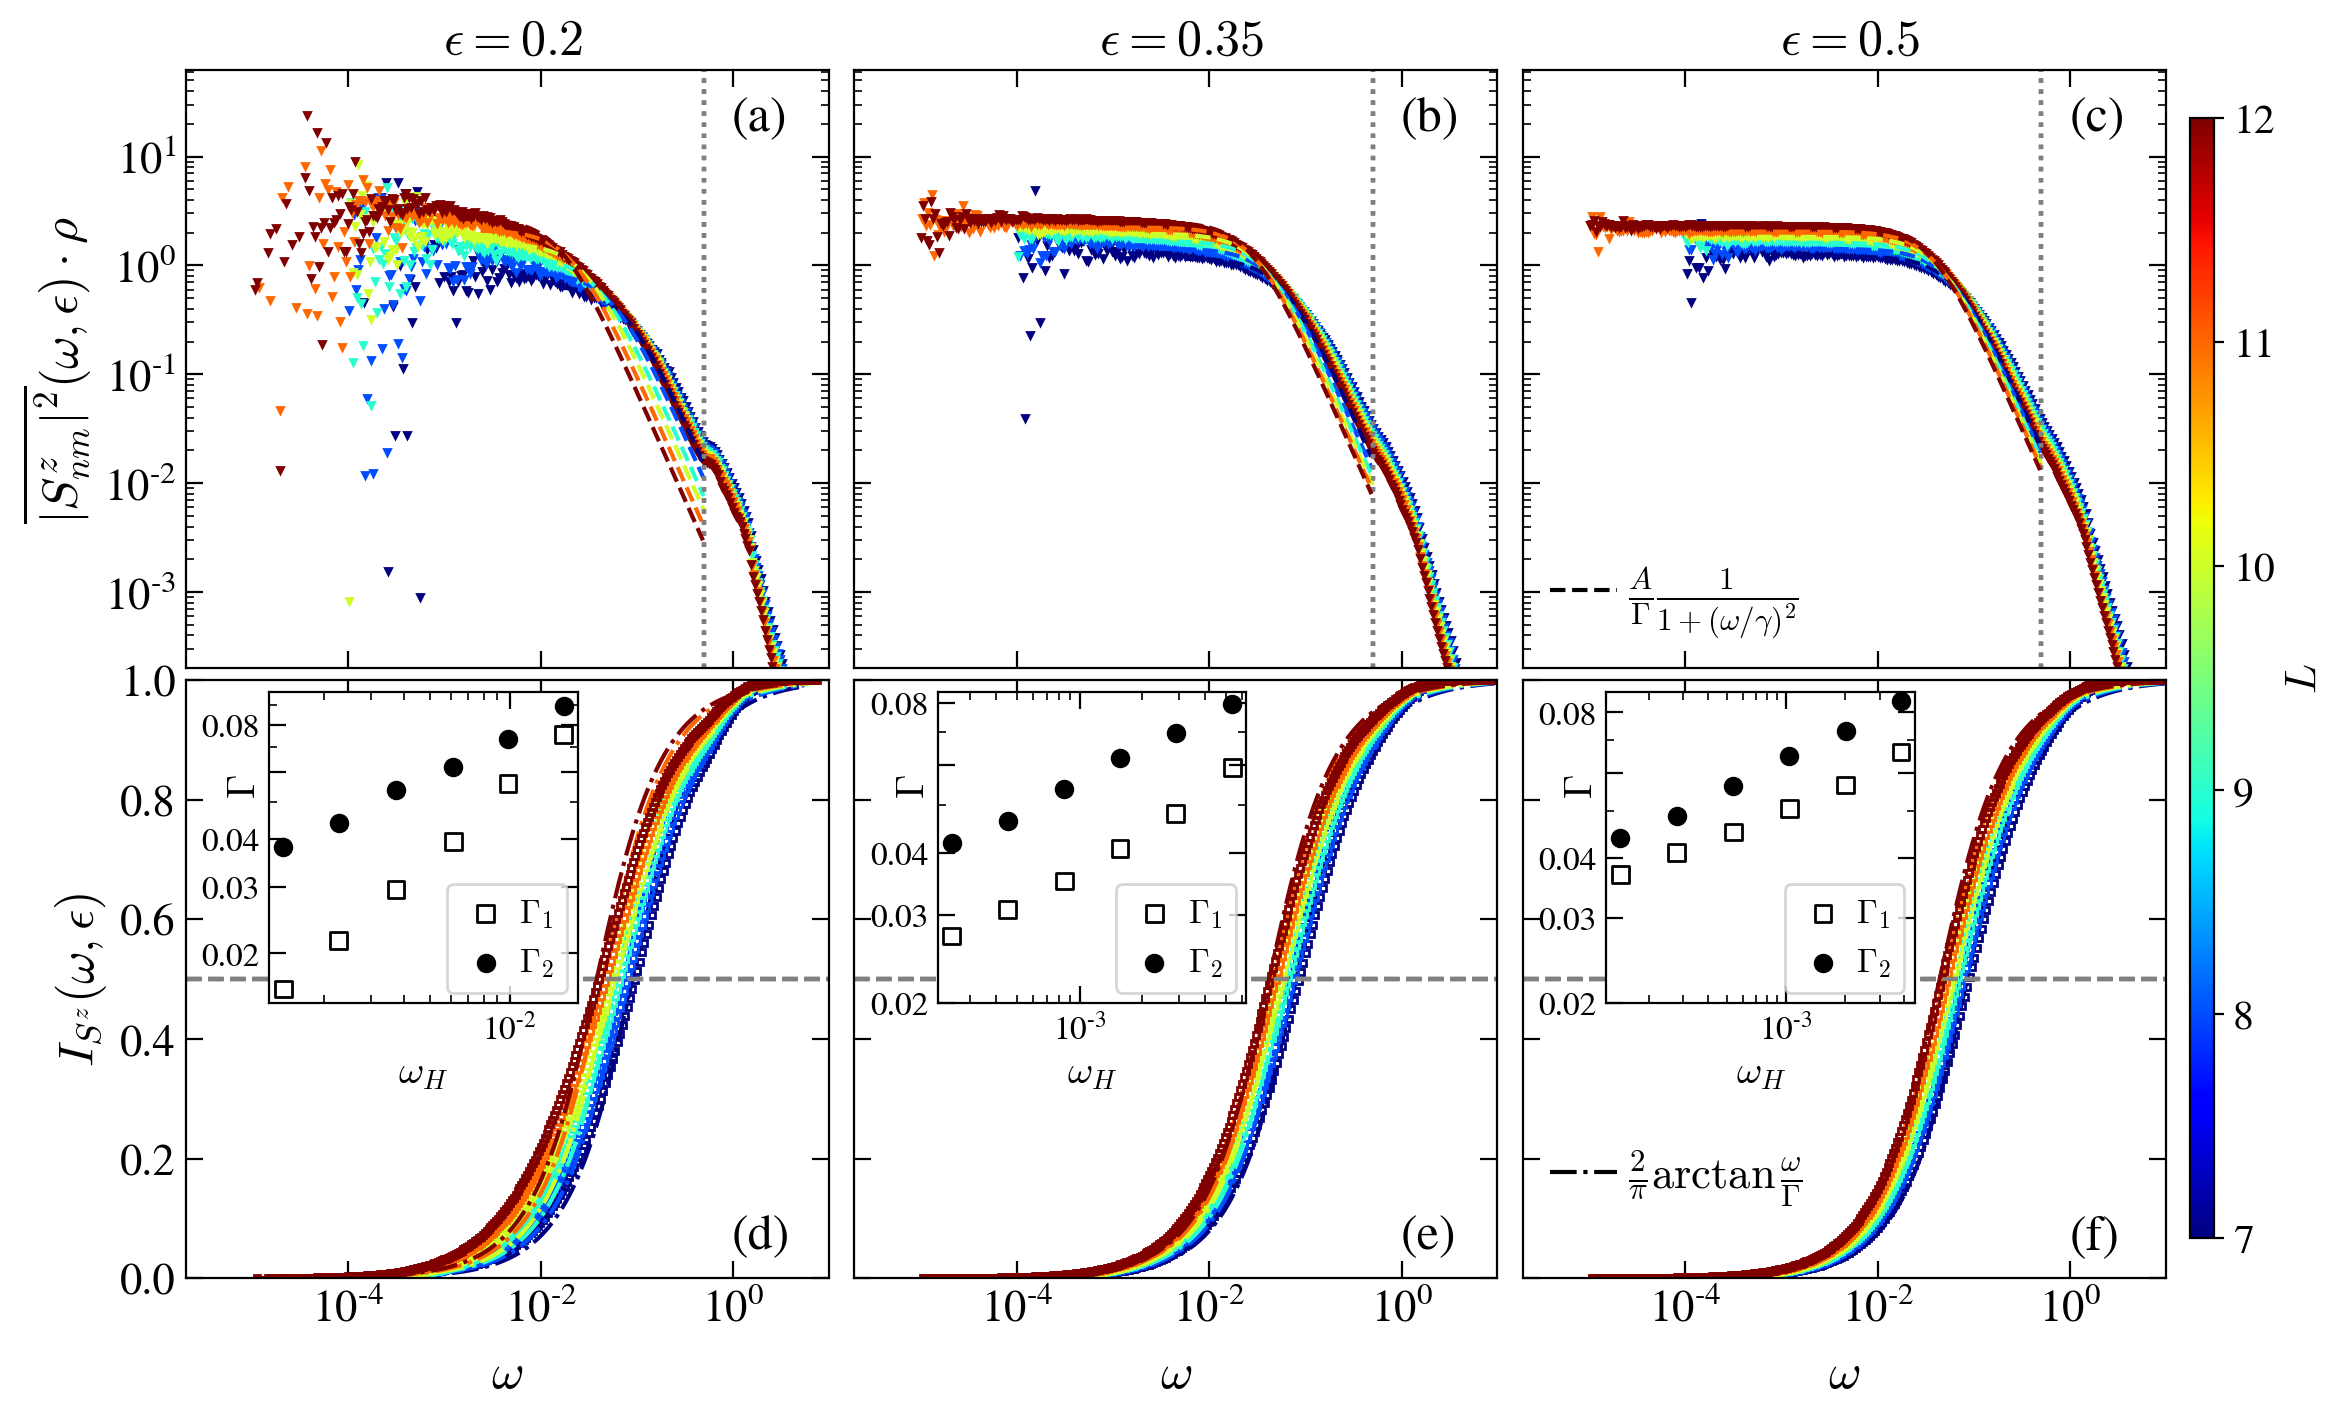

In [24]:
markers = itertools.cycle(markers_ls)
colors_ls_cyc = itertools.cycle(colors_ls)
L_total=15

J=1

alfa=0.95

h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745

def lorenz(x, A, G1):
    return A / ( (x / G1)**2 + 1)

def arctan(x, G):
    return 2 / np.pi * np.arctan(x / G)

AGP = 1

alfa_vals = np.arange(0.6, 0.999, 0.01)
print(alfa_vals)

sizes = np.arange(10, 16, 1) - N

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(vmin=min(sizes),vmax=max(sizes) ))
s_m.set_array([])

fig, axis = plt.subplots( nrows=2, ncols=3, figsize=(12,8), dpi = 200, sharex = True, sharey = 'row')
# axis = np.array(axis).flatten()

E = np.arange(0.05, 0.95, 0.02)
omegax = np.zeros( (20 * (L + N)) )

labs = ["(a)", "(b)", "(c)"]
labs2 = ["(d)", "(e)", "(f)"]
_eps_ = [0.2, 0.35, 0.5]
# _eps_ = [0.5, 0.65, 0.8]

upper_cut = 0.5
for iie, eps in enumerate(_eps_):
    idx = min(range(len(E)), key=lambda i: abs(E[i] - eps))
    
    all_spec = []
    all_spec_typ = []
    cut = 0
    wH = np.zeros(sizes.shape)
    spec_at_wH = np.zeros(sizes.shape)
    Gammas1 = []
    Gammas2 = []
    spec_at_G1 = []
    spec_at_G2 = []
    for iiL, L in enumerate(sizes):
        name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                R = np.array(file.get('realisations'))
                
                Ex = np.array(file.get('energy_density'))
                idx2 = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                DOS = np.array(file.get('count'))[idx2] / R
                X = np.array(file.get('wH_typ_density'))[idx2]
                wH[iiL] = X
                cut = X
        else:
            print(name)
        col = s_m.to_rgba(L)
        dim = 2**(L+N)
        name = base_dir + 'SpectralFunctions/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                omegax = np.array(file.get('omegas'))
                omegax = np.sqrt(omegax[1:] * omegax[:-1])
                
                spec_fun = np.array(file.get('spec_fun'))[idx] / X
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx] / X
                
                
                wH_idx = min(range(len(omegax)), key=lambda i: abs(omegax[i] - wH[iiL]))
                spec_at_wH[iiL] = spec_fun[wH_idx]
                
                all_spec.append(spec_fun)
                all_spec_typ.append(spec_fun_typ)
                
                R = np.array(file.get('realisations'))
                print(L, alfa, spec_fun.shape, R)
        else:
            print(name)

        # wH = np.sqrt(2**(N-1) * 0.3 + J**2 / 4 * ( (alfa_vals**(2*L+2) - alfa_vals**2) / (alfa_vals**2 - 1) ) + L / 4 * (1 + (w)**2 / 3)) / (0.3413 * dim)# / np.sqrt(L)
        eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
        matelem = dim # ** ( (2/eta) )
        norm = 1 / (dim * wH**2)
        # norm = 1/dim#**0.98
        # norm = 1#xnorma
        
        yy0 = spec_fun if AGP else spec_fun_typ
        
        
        omegax = omegax[~np.isnan(yy0)]
        yy0 = yy0[~np.isnan(yy0)]
        
        axis[0][iie].plot(omegax, yy0, color=col, marker='v', markersize=2, lw=0,zorder=0)
        axis[0][iie].axvline(x=upper_cut, ls=':', color='gray')
        indices = np.where(np.logical_and(omegax >= cut, omegax < upper_cut))[0]
        xx = omegax[indices]
        yy = yy0[indices]
        pars, pconv= fit(lorenz,
                    xdata = xx,
                    ydata = yy,
                    maxfev = 20000)
        z = np.linspace(min(xx), max(xx), 5000)
        # print(eps, L, G1)
        G1 = np.abs(pars[-1])
        Gammas1.append(G1)
        spec_at_G1.append(yy0[np.argmin( np.abs(omegax - G1) )])
        axis[0][iie].plot(z, lorenz(z, *pars), ls='--', color=col)
        
        # yy = integrate.cumulative_trapezoid(yy0, omegax)
        # yy = (yy - yy[0]) / (yy[-1] - yy[0])
        
        indices = np.where(np.logical_and(omegax >= 0, omegax < 0.5))[0]
        
        xx = omegax#[indices]
        yy0 = yy0#[indices]
        yy = integrate.cumulative_trapezoid(yy0, xx)
        yy = (yy - yy[0]) / (yy[-1] - yy[0])
        
        axis[1][iie].plot(xx[1:], yy, color=col, marker='s', markersize=2, lw=0, markerfacecolor='None')
        axis[1][iie].axhline(y=0.5, ls='--', color='gray')
        
        G2 = xx[np.argmin( np.abs(yy - 0.5) )]
        spec_at_G2.append(yy0[np.argmin( np.abs(omegax - G2) )])
        Gammas2.append(G2)
        axis[1][iie].plot(xx, arctan(xx, G2), ls='-.', color=col)
        if iie == 2 and L == 12:
            axis[0][iie].plot(np.nan, np.nan, ls='--', color='k', label=r"$\frac{A}{\Gamma}\frac{1}{1+(\omega/\gamma)^2}$")
            axis[1][iie].plot(np.nan, np.nan, ls='-.', color='k', label=r"$\frac{2}{\pi}\arctan{\frac{\omega}{\Gamma}}$")
    Gammas1 = np.array(Gammas1)
    Gammas2 = np.array(Gammas2)
    # axis[0][iie].scatter(Gammas1, spec_at_G1, marker='s', color='black', label=r"$\Gamma_1$", zorder=10, facecolor='None')
    # axis[0][iie].scatter(Gammas2, spec_at_G2, marker='o', color='black', label=r"$\Gamma_2$", zorder=10)
    # axis[iie].plot(wH, spec_at_wH, marker='s', color='k', ls='--')
    if AGP : #\cdot\rho(\epsilon)
        fig_help.set_plot_elements(axis[0][iie], ylabel=r"$\overline{|S^z_{nm}|^2}(\omega,\epsilon)\cdot\rho$" if iie == 0 else "", xlabel="", font_size=16, set_legend=False, xscale='log', yscale='log')
        fig_help.set_plot_elements(axis[1][iie], ylabel=r"$I_{S^z}(\omega,\epsilon)$" if iie == 0 else "", xlabel=r"$\omega$", font_size=16, set_legend=False, xscale='log', yscale='linear')
    else:    
        fig_help.set_plot_elements(axis[0][iie], ylabel=r"$\overline{|S^z_{nm}|^2}^{\rm typ}(\omega,\epsilon)\cdot\rho$" if iie == 0 else "", xlabel="", font_size=16, set_legend=False, xscale='log', yscale='log')
        fig_help.set_plot_elements(axis[1][iie], ylabel=r"$I_{S^z}(\omega,\epsilon)$" if iie == 0 else "", xlabel=r"$\omega$", font_size=16, set_legend=False, xscale='log', yscale='linear')
    fig_help.set_legend(axis[0][iie], fontsize=16, loc='lower left')
    fig_help.set_legend(axis[1][iie], fontsize=16, loc='lower left', anchor=(-0.02, 0.05))
    axis[0][iie].set_title(r" $\epsilon=%g$"%eps, fontsize=18)
    axis[0][iie].annotate(labs[iie],     fontsize=18, xy=(0.85, 0.9), xycoords='axes fraction')
    axis[1][iie].annotate(labs2[iie],     fontsize=18, xy=(0.85, 0.05), xycoords='axes fraction')
    axis[0][iie].set_ylim(2e-4, None)
    axis[1][iie].set_ylim(0, 1)
    axis[0][iie].set_xlim(0.2*min(omegax), max(omegax))
    
    inset = axis[1][iie].inset_axes([0.13, 0.46, 0.48, 0.52])
    
        
    # inset.xaxis.set_label_coords(.45, -0.05)
    inset.yaxis.set_label_coords(-0.02, 0.7)
    inset.scatter(wH, Gammas1, marker='s', color='black', label=r"$\Gamma_1$", zorder=10, facecolor='None')
    inset.scatter(wH, Gammas2, marker='o', color='black', label=r"$\Gamma_2$", zorder=10)
    fig_help.set_plot_elements(inset, ylabel=r"$\Gamma$", xlabel=r"$\omega_H$", font_size=12, set_legend=False, xscale='log', yscale='log')
    fig_help.set_legend(inset, fontsize=12, loc='lower right', frameon=True)
    inset.set_yticks([0.02, 0.03, 0.04, 0.06, 0.08])
    inset.set_yticklabels(["0.02", "0.03", "0.04", "", "0.08"])
    
fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$L$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig.subplots_adjust(wspace = 0.04, hspace=0.02)
fig.savefig("plots_AGP/FigS4.pdf", bbox_inches = 'tight', pad_inches=0.02)

[0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
0.7 7 0.004174486059396596 0.14228331029240215
0.7 8 0.0020548749037537996 0.14096126602651374
0.7 9 0.0010853376119010433 0.1333906768118248
0.7 10 0.0006051364063700845 0.12493894521087258
0.7 11 0.0002692201282980412 0.12195797924171004
0.7 12 0.00013607528864243343 0.11652206258469384
0.71 7 0.004686560969854706 0.14314585710026753
0.71 8 0.002282692903022124 0.14391741300523084
0.71 9 0.0011951044341318173 0.1380837210495406
0.71 10 0.0006613986748782506 0.13181332509359517
0.71 11 0.0002972475471559785 0.1300960930096105
0.71 12 0.00014924955450518304 0.12738852863422018
0.72 7 0.004965693381414729 0.14798674524306632
0.72 8 0.002535768420738804 0.1457854729751265
0.72 9 0.0013159726455805839 0.14169143516175647
0.72 10 0.0007228919009430335 0.1373913664902165
0.72 11 0.00034485331776221097 0.13710563309842763
0.72 12 0.00017144

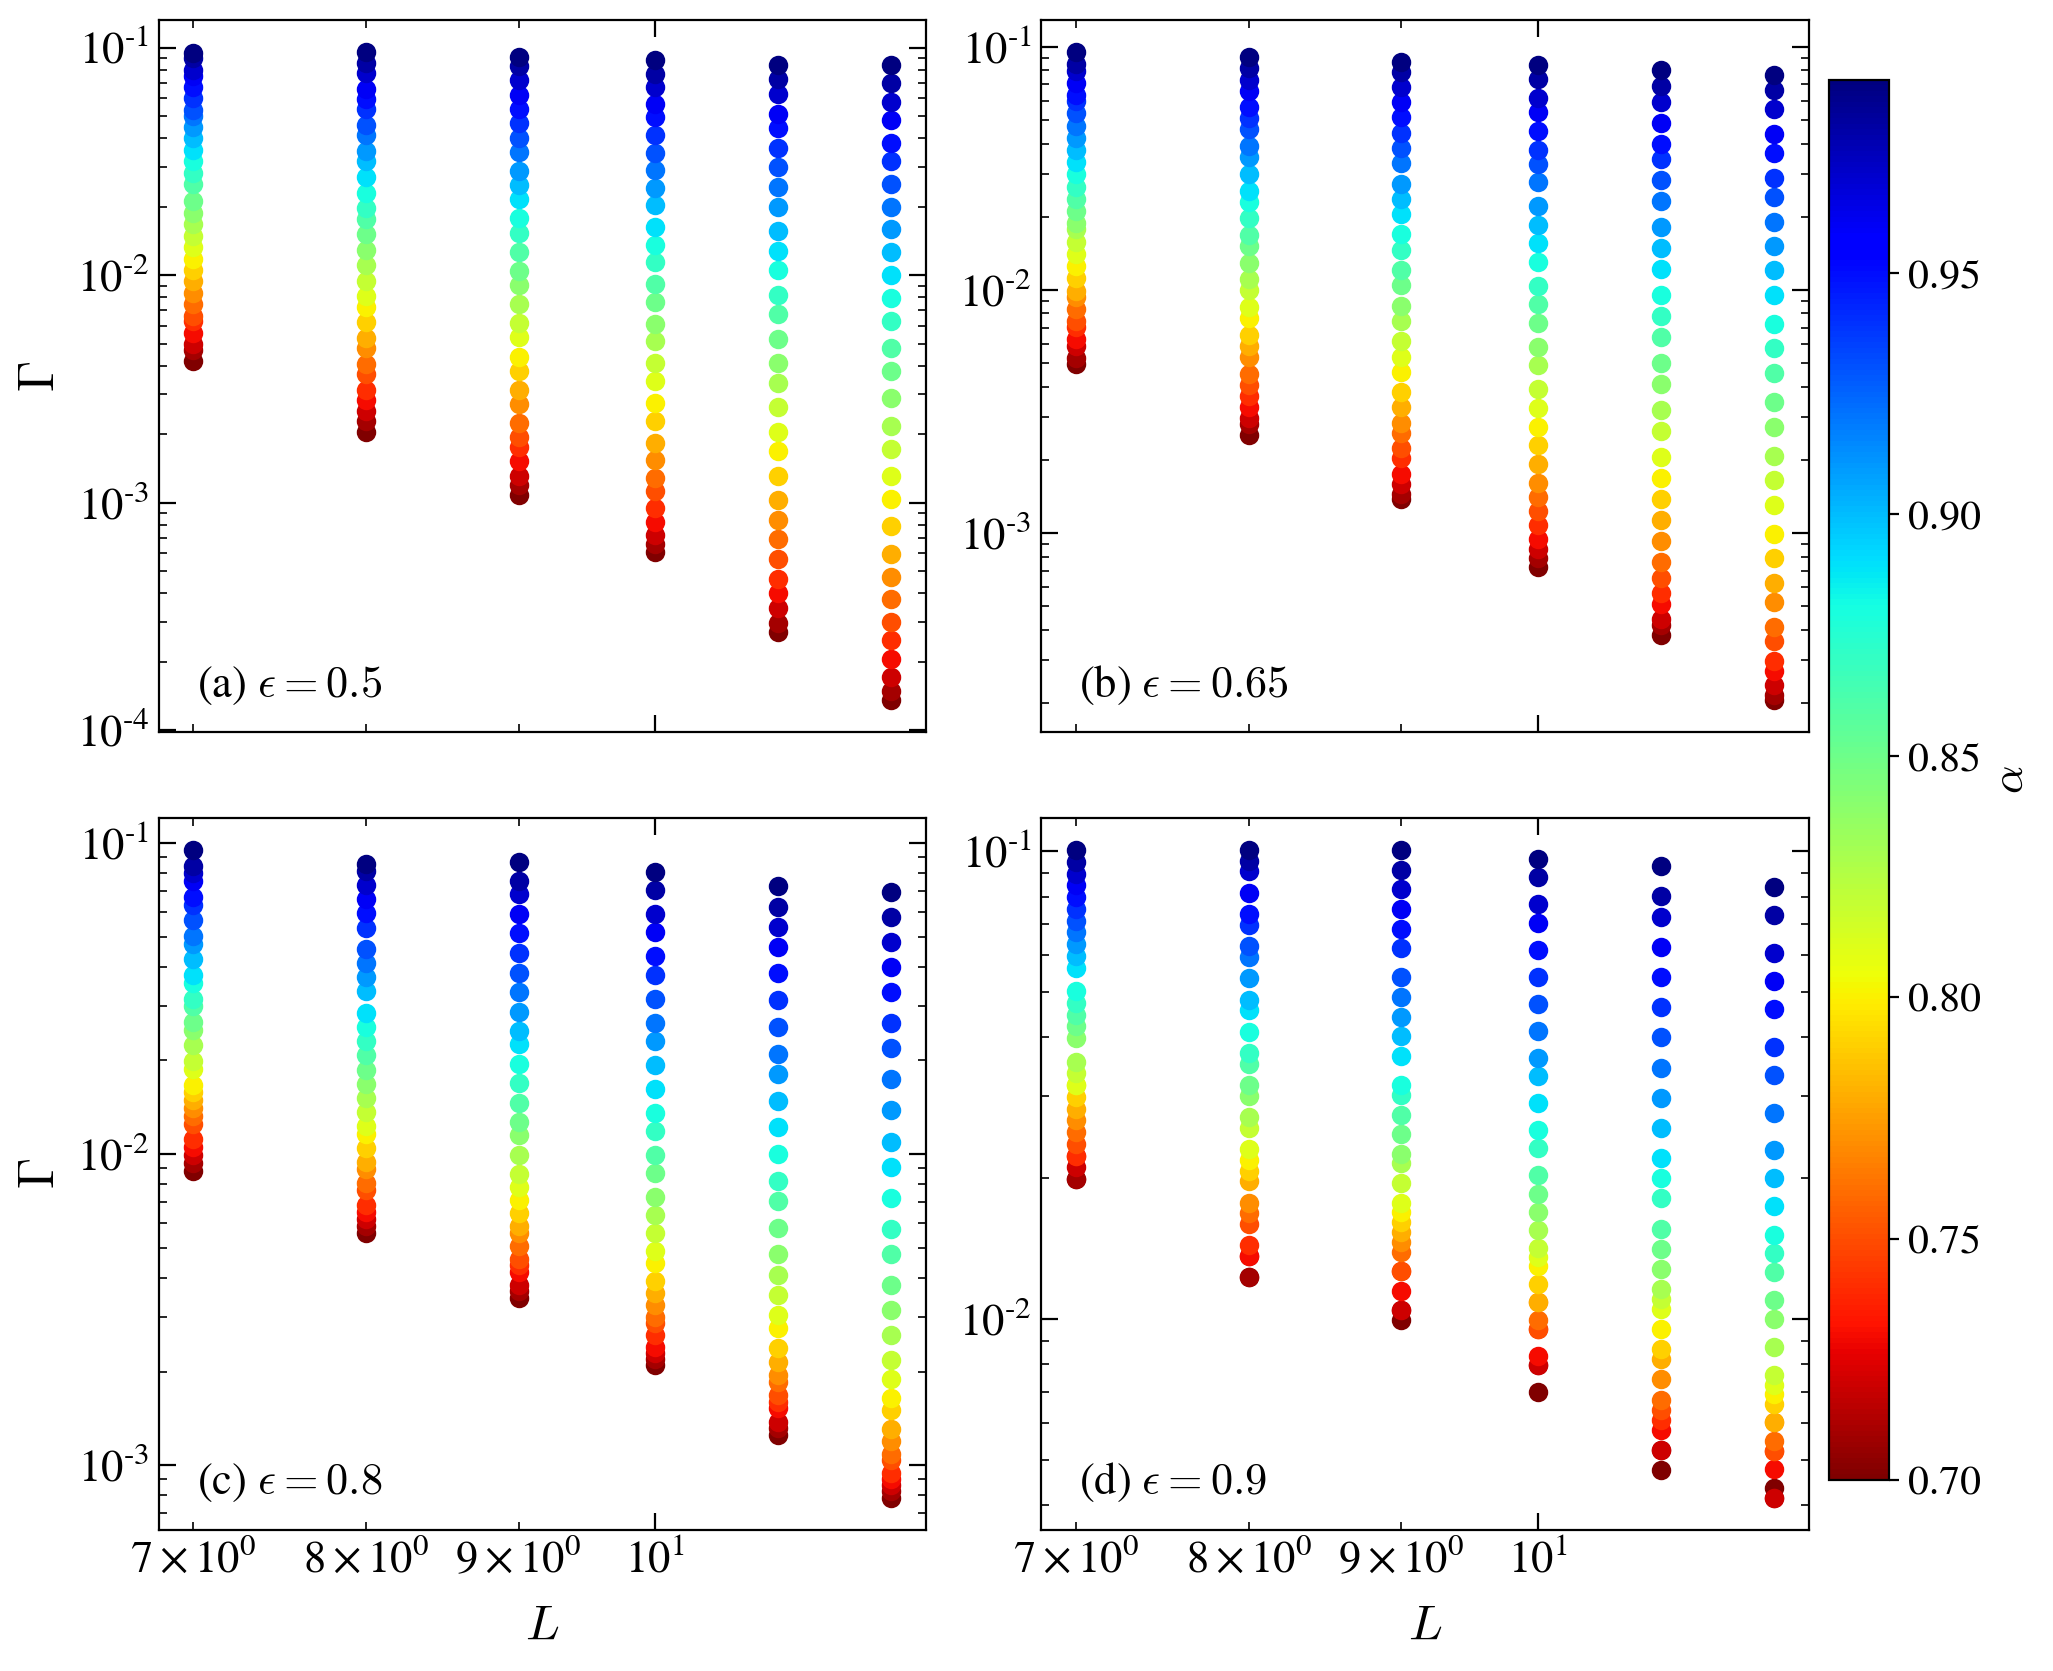

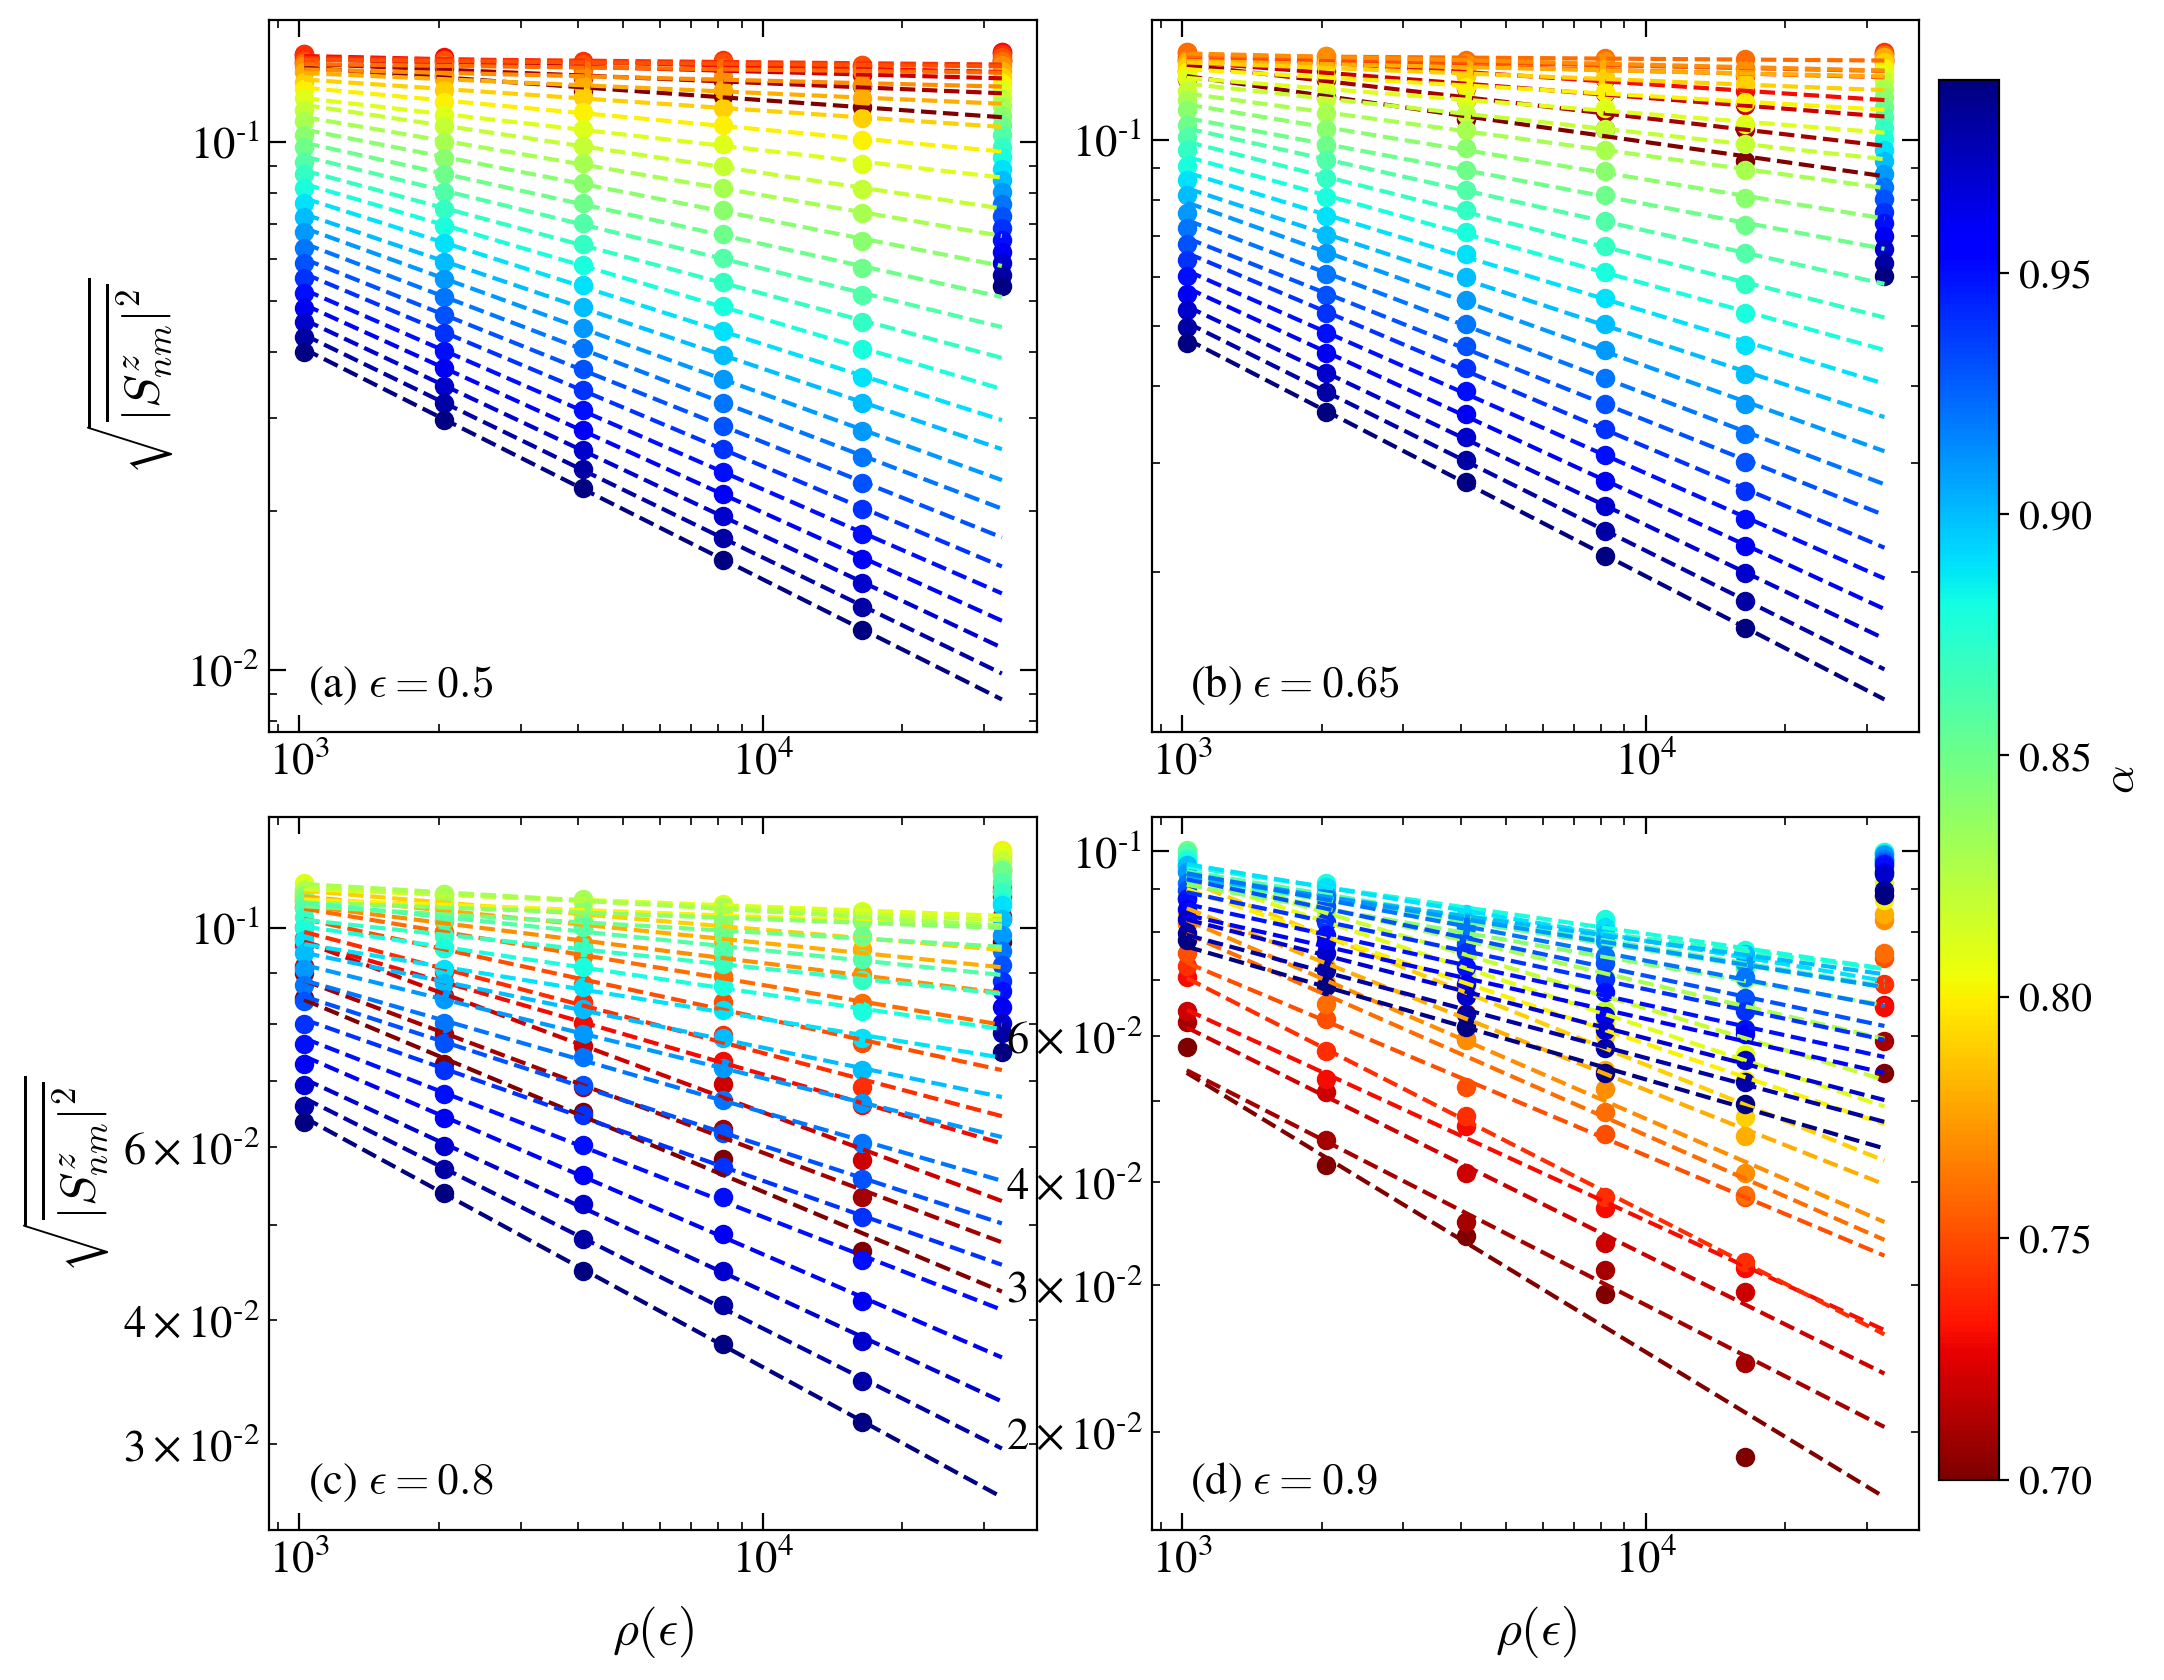

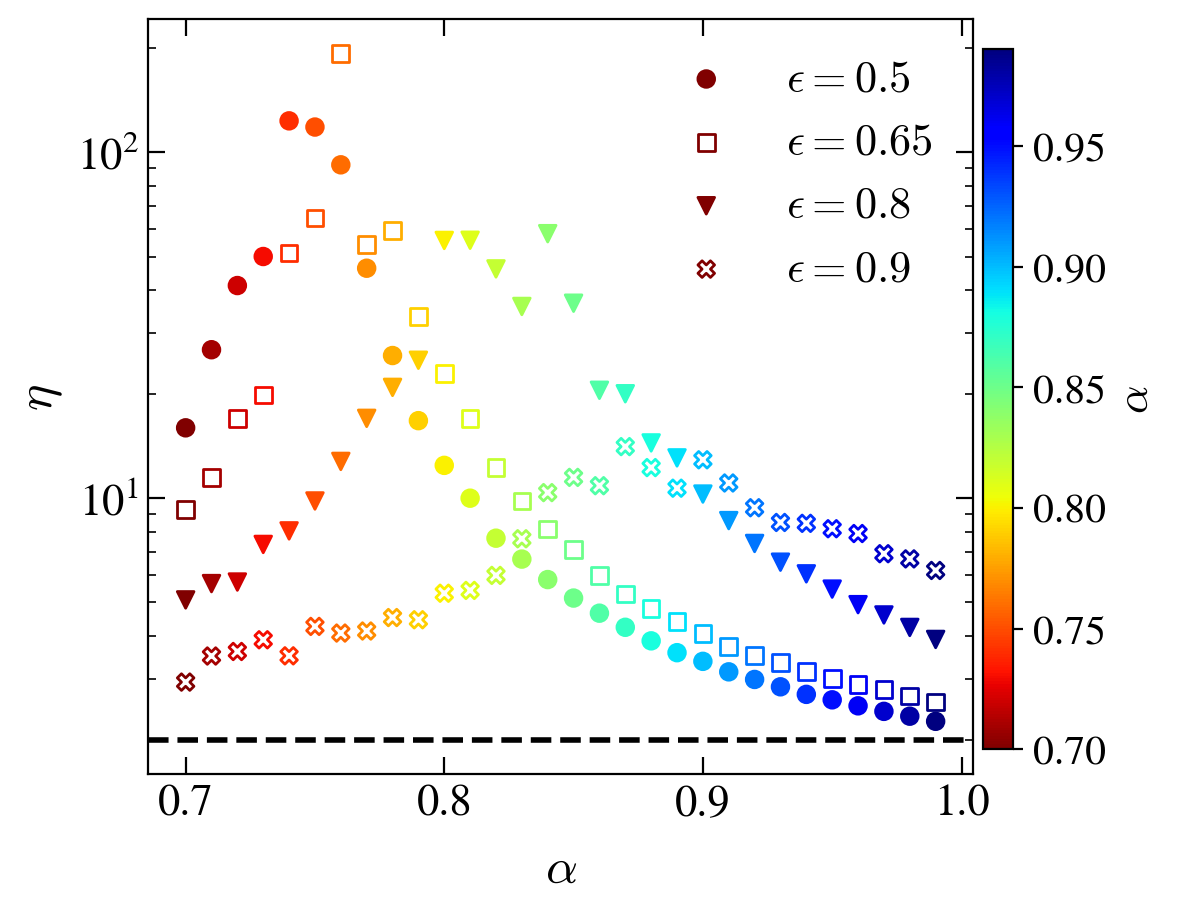

In [32]:
markers_ls2 = ['o','s','v', 'X', '+', 'X', '^', '*', '+']
markers2 = itertools.cycle(markers_ls2)
colors_ls_cyc = itertools.cycle(colors_ls)
L_total=15

J=1

alfa=0.88

h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.74

# def lorenz(x, A, G):
#     return A / ( (x / G)**2 + 1)

def eta_fit(x, alfac, A):
    return 2 * A / ( 1 - np.log(x) / np.log(alfac))

def matelem_fit(DOS, a0, eta):
    return a0 * DOS**(-1 / eta)

AGP = 1

alfa_vals = np.arange(0.70, 0.999, 0.01)
print(alfa_vals)

sizes = np.arange(10, 16, 1) - N

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet_r', norm=matplotlib.colors.Normalize(vmin=min(alfa_vals),vmax=max(alfa_vals) ))
s_m.set_array([])

fig1, axis = plt.subplots( nrows=2, ncols=2, figsize=(10,10), dpi = 200, sharex = True)
axis = np.array(axis).flatten()

fig2, axis2 = plt.subplots( nrows=2, ncols=2, figsize=(10,10), dpi = 200)
axis2 = np.array(axis2).flatten()

fig3, axis3 = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

E = np.arange(0.05, 0.95, 0.02)
omegax = np.zeros( (20 * (L + N)) )

labs = ["(a)", "(b)", "(c)", "(d)"]
_eps_ = [0.25, 0.3, 0.35, 0.5]
_eps_ = [0.5, 0.65, 0.8, 0.9]
Eall = np.arange(0.05, 0.95, 0.02)
for iie, eps in enumerate(_eps_):
    colors = []
    eta_eps = []
    for alfa in alfa_vals:
        col = s_m.to_rgba(alfa)
        colors.append(col)
        
        idx = min(range(len(Eall)), key=lambda i: abs(Eall[i] - eps))
        
        all_spec = []
        all_spec_typ = []
        cut = 0
        
        wH = np.zeros(sizes.shape)
        
        spec_at_wH_G = np.zeros(sizes.shape)
        
        Gamma = []
        DOS = np.zeros(sizes.shape)
        for iiL, L in enumerate(sizes):
            name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
            if exists(name):
                with h5py.File(name, "r") as file:
                    R = np.array(file.get('realisations'))
                    
                    Ex = np.array(file.get('energy_density'))
                    idx2 = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                    X = np.array(file.get('wH_density'))[idx2]
                    _DOS = np.array(file.get('DOS'))[idx2] / R
                    
                    DOS[iiL] = dim#_DOS
                    
                    wH[iiL] = X
                    cut = X / 10
            else:
                print(name)
                
            dim = 2**(L+N)
            name = base_dir + 'SpectralFunctions/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
            if exists(name):
                with h5py.File(name, "r") as file:
                    omegax = np.array(file.get('omegas'))
                    omegax = np.sqrt(omegax[1:] * omegax[:-1])
                    spec_fun = np.array(file.get('spec_fun'))[idx]
                    spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
            else:
                print(name)
            
            yy0 = spec_fun if AGP else spec_fun_typ
            
            omegax = omegax[~np.isnan(yy0)]
            yy0 = yy0[~np.isnan(yy0)]
            
            indices = np.where(np.logical_and(omegax >= cut, omegax < 0.5))[0]
            
            xx = omegax[indices]
            yy = yy0[indices]
            yy = integrate.cumulative_trapezoid(yy, xx)
            yy = (yy - yy[0]) / (yy[-1] - yy[0])
            G = xx[np.argmin( np.abs(yy - 0.5) )]
            # pars, pconv= fit(lorenz,
            #             xdata = xx,
            #             ydata = yy,
            #             maxfev = 20000)
            # G = np.abs(pars[-1])
            Gamma.append(G)
            
            idx_spec = min(range(len(omegax)), key=lambda i: abs(omegax[i] - np.sqrt(wH[iiL] * G)))
            
            spec_at_wH_G[iiL] = np.sqrt( np.mean(yy0[idx_spec - 5 : idx_spec + 5]) )
            # spec_at_wH_G[iiL] = np.sqrt( yy0[idx_spec] )
            print(alfa, L, G, spec_at_wH_G[iiL])
            
        axis[iie].scatter(sizes, Gamma, color = col)
        axis2[iie].scatter(DOS, spec_at_wH_G, color = col)
        
        pars, pconv= fit(matelem_fit,
                    xdata = DOS[2:],
                    ydata = spec_at_wH_G[2:],
                    maxfev = 20000)
        _etaX = np.abs(pars[-1])
        if _etaX > 1e4: _etaX = np.nan
        eta_eps.append(_etaX)
        
        zz = np.linspace(min(DOS), max(DOS), 5000)
        axis2[iie].plot(zz, matelem_fit(zz, *pars), ls='--', color=col)
    
    axis3.scatter(alfa_vals, eta_eps, color=colors, marker=next(markers2), facecolor='None' if iie %2 else colors, label=r"$\epsilon=%g$"%eps)
    
    # print(len(Gamma))
    # axis[iie].scatter(alfa_vals, Gamma, color=colors)
    lab = r"$\Gamma$" if AGP else r"$\Gamma_{\rm typ}$"
    fig_help.set_plot_elements(axis[iie], ylabel=lab if iie%2 == 0 else "", xlabel=r"$L$" if iie>1 else "", font_size=16, set_legend=False, xscale='log', yscale='log')
    axis[iie].annotate(labs[iie] + r" $\epsilon=%g$"%eps,     fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')
    
    lab = r"$\sqrt{\overline{|S^z_{nm}|^2}}$" if AGP else r"$\sqrt{\overline{|S^z_{nm}|^2}^{\rm typ}}$"
    fig_help.set_plot_elements(axis2[iie], ylabel=lab if iie%2 == 0 else "", xlabel=r"$\rho(\epsilon)$" if iie>1 else "", font_size=16, set_legend=False, xscale='log', yscale='log')
    axis2[iie].annotate(labs[iie] + r" $\epsilon=%g$"%eps,     fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')

axis3.axhline(y=2, ls='--', lw=2, color='k')
fig_help.set_plot_elements(axis3, ylabel=r"$\eta$", xlabel=r"$\alpha$", font_size=16, set_legend=True, xscale='linear', yscale='log')

for fig in [fig1, fig2, fig3]:
    fig.subplots_adjust(right=0.95)
    cbar_ax = fig.add_axes([0.96, 0.15, 0.03, 0.7])
    # fig.colorbar(im, cax=cbar_ax)
    cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
    cbar.set_label(r"$\alpha$", fontsize=16)
    cbar.ax.tick_params(labelsize=15)

    fig.subplots_adjust(wspace = 0.15, hspace=0.12)


[0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87 0.88
 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99]
e* =  0.7393279490620294
0.23000000000000004 19 7.3885
0.23000000000000004 19 13.3466
0.23000000000000004 19 24.775125
0.23000000000000004 19 45.114
0.23000000000000004 19 80.92666666666666
0.23000000000000004 19 144.91745283018867
0.25000000000000006 21 8.6999
0.25000000000000006 21 16.4668
0.25000000000000006 21 30.80225
0.25000000000000006 21 56.76566666666667
0.25000000000000006 21 104.25
0.25000000000000006 21 192.61163522012578
0.27 23 10.2093
0.27 23 19.817
0.27 23 37.201125
0.27 23 70.00183333333334
0.27 23 132.263
0.27 23 248.48820754716982
0.29000000000000004 25 11.8903
0.29000000000000004 25 23.0009
0.29000000000000004 25 44.0975
0.29000000000000004 25 85.23016666666666
0.29000000000000004 25 164.04666666666665
0.29000000000000004 25 311.5904088050315
0.31000000000000005 27 13.5129
0.31000000000000005 27 26.2582
0.31000000000000005 27 51.802625
0.31

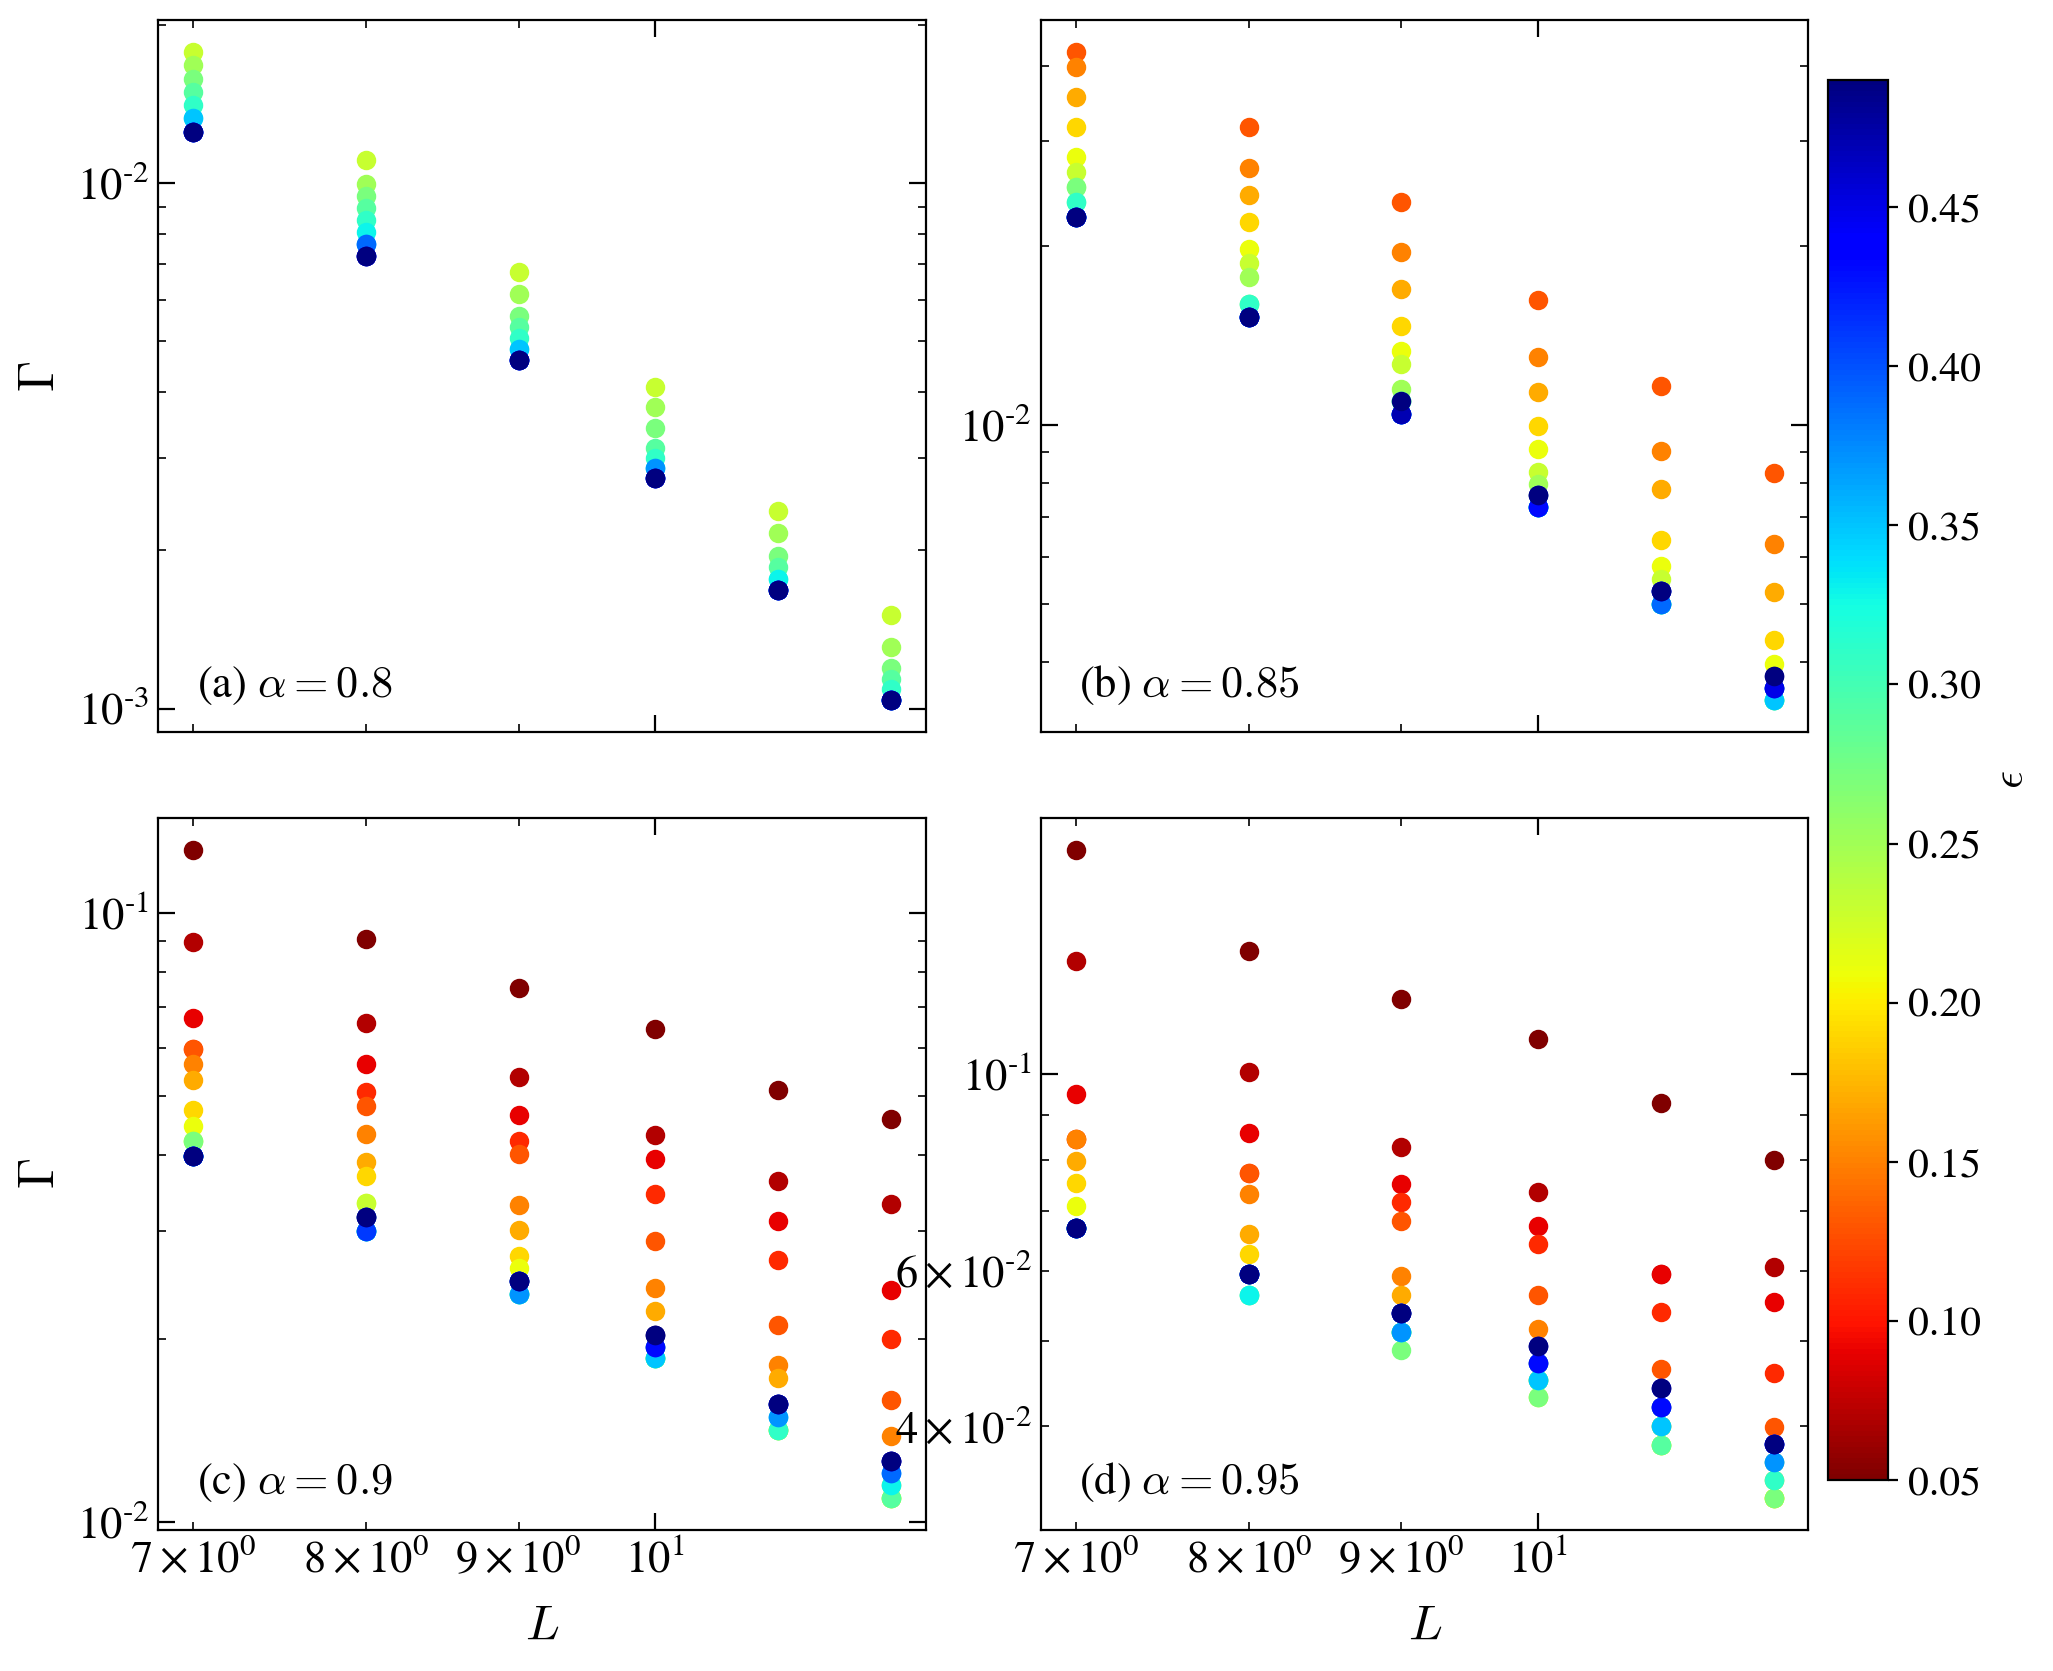

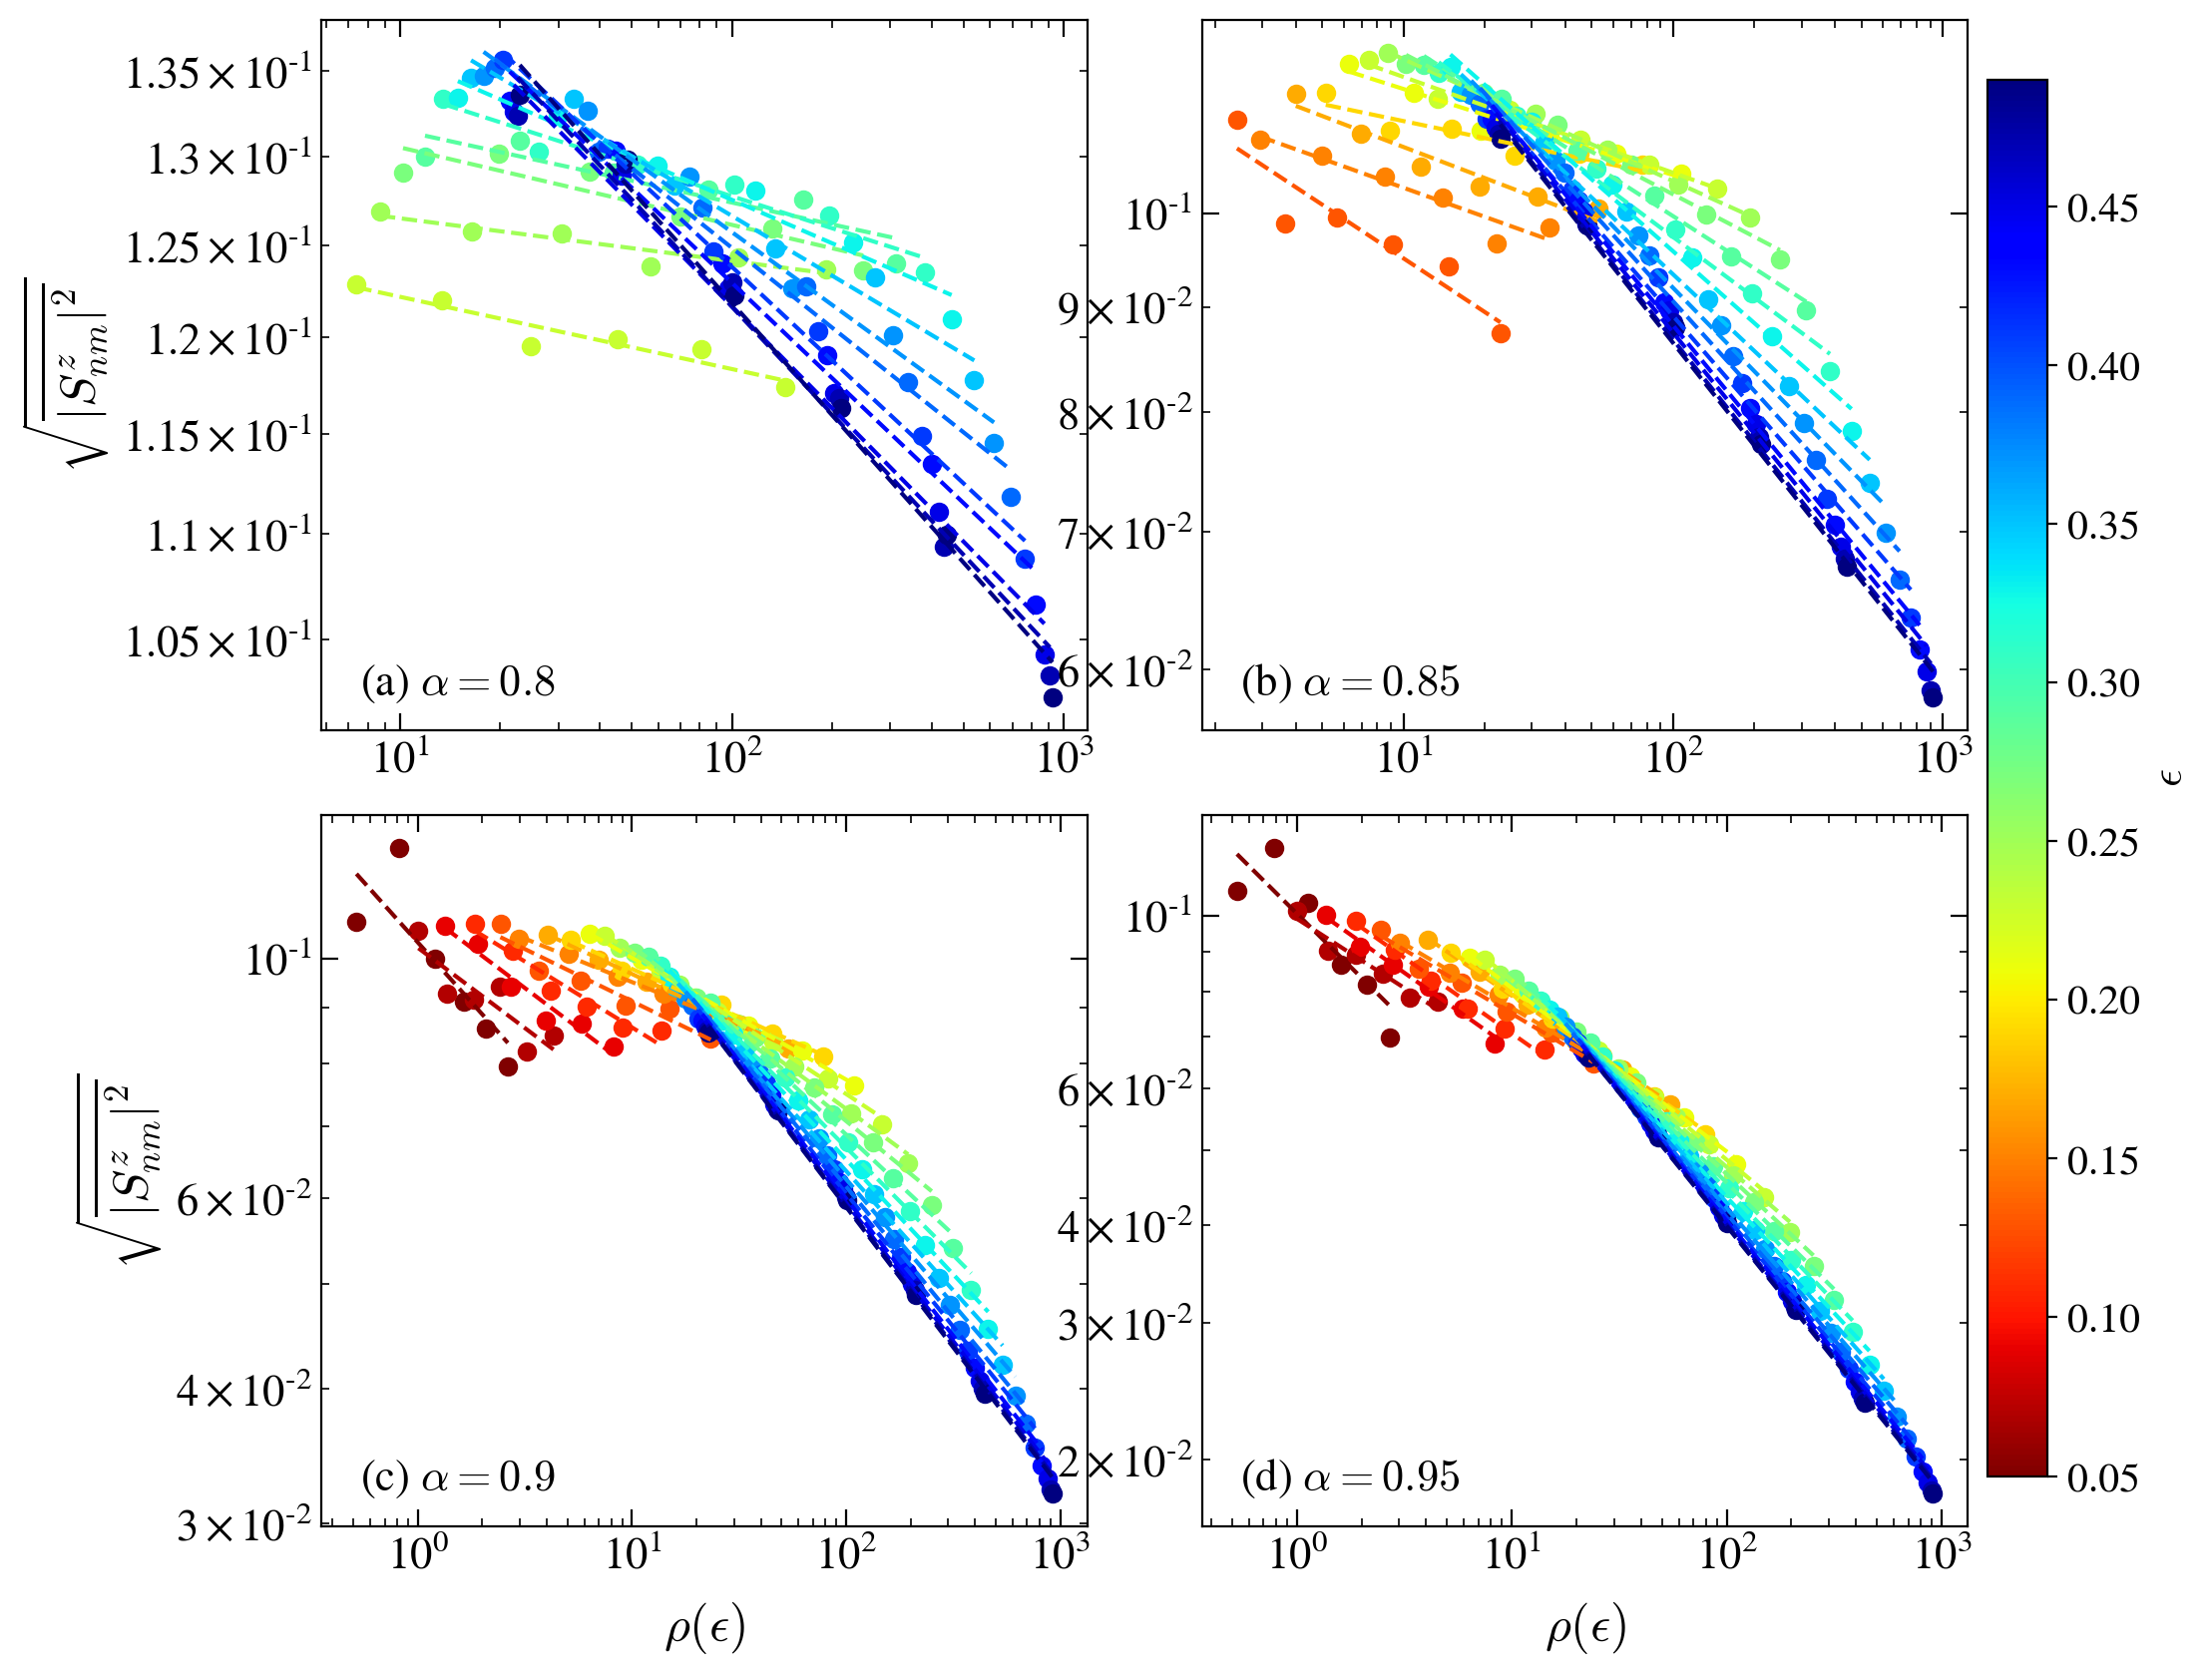

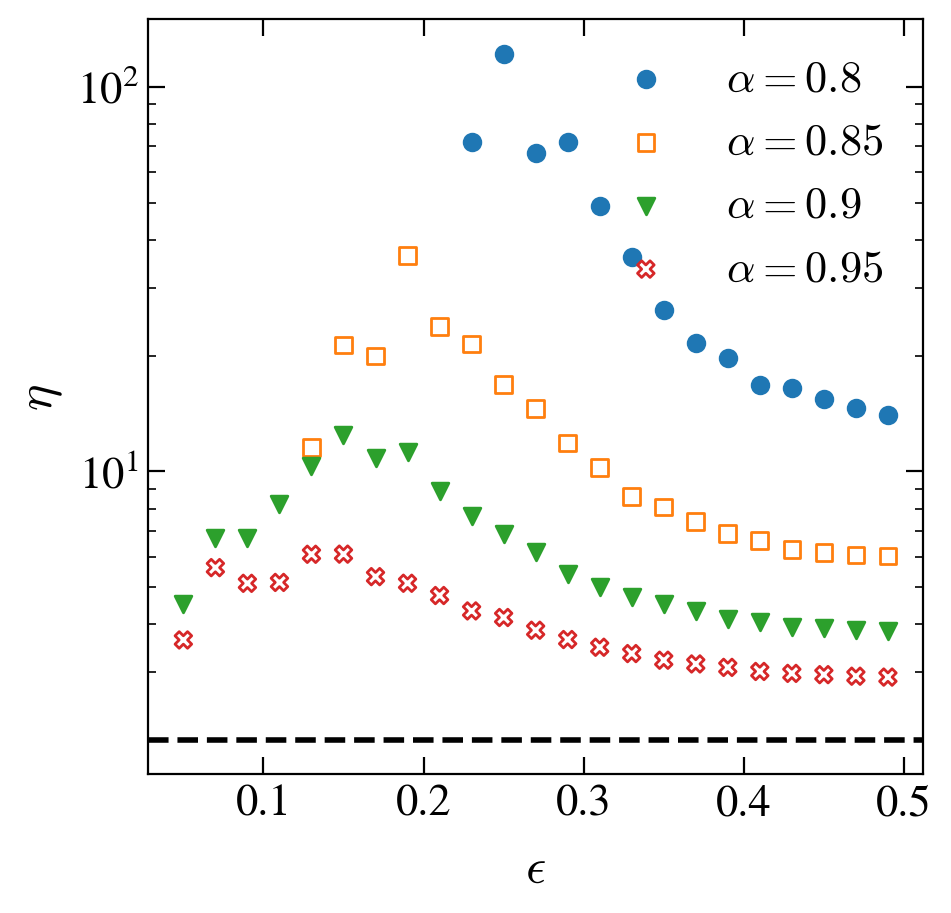

In [579]:
markers_ls2 = ['o','s','v', 'X', '+', 'X', '^', '*', '+']
markers2 = itertools.cycle(markers_ls2)
colors_ls_cyc = itertools.cycle(colors_ls)
L_total=15

J=1

alfa=0.88

h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.74

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)

def eta_fit(x, alfac, A):
    return 2 * A / ( 1 - np.log(x) / np.log(alfac))

def matelem_fit(DOS, a0, eta):
    return a0 * DOS**(-1 / eta)

AGP = 1

alfa_vals = np.arange(0.75, 0.999, 0.01)
print(alfa_vals)

sizes = np.arange(10, 16, 1) - N

Eall = np.arange(0.05, 0.95, 0.02)
E = np.arange(0.05, 0.51, 0.02)

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet_r', norm=matplotlib.colors.Normalize(vmin=min(E),vmax=max(E) ))
s_m.set_array([])

fig1, axis = plt.subplots( nrows=2, ncols=2, figsize=(10,10), dpi = 200, sharex = True)
axis = np.array(axis).flatten()

fig2, axis2 = plt.subplots( nrows=2, ncols=2, figsize=(10,10), dpi = 200)
axis2 = np.array(axis2).flatten()

fig3, axis3 = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

omegax = np.zeros( (20 * (L + N)) )

a = 1.05
b = 0.45

labs = ["(a)", "(b)", "(c)", "(d)"]
_alfa_ = [0.8, 0.85, 0.9, 0.95]
for iie, alfa in enumerate(_alfa_):
    print("e* = ", 0.5 + 2 * b / a * np.sqrt( np.log(alfa / alfa_crit) ))
    colors = []
    eta_eps = []
    for eps in E:
        if np.abs(eps - 0.5) > 1.2 * (2 * b / a * np.sqrt( np.log(alfa / alfa_crit) )):
            colors.append('None')
            eta_eps.append(np.nan)
            continue
        col = s_m.to_rgba(eps)
        colors.append(col)
        
        idx = min(range(len(Eall)), key=lambda i: abs(Eall[i] - eps))
        
        all_spec = []
        all_spec_typ = []
        cut = 0
        
        wH = np.zeros(sizes.shape)
        
        spec_at_wH_G = np.zeros(sizes.shape)
        
        Gamma = []
        DOS = np.zeros(sizes.shape)
        for iiL, L in enumerate(sizes):
            name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
            if exists(name):
                with h5py.File(name, "r") as file:
                    R = np.array(file.get('realisations'))
                    
                    Ex = np.array(file.get('energy_density'))
                    idx2 = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                    
                    X = np.array(file.get('wH_typ_density'))[idx2]
                    _DOS = np.array(file.get('DOS'))[idx2] / R
                    
                    print(eps, idx2, _DOS)
                    DOS[iiL] = _DOS
                    
                    wH[iiL] = X
                    cut = X / 5
            else:
                print(name)
                
            dim = 2**(L+N)
            name = base_dir + 'SpectralFunctions/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
            if exists(name):
                with h5py.File(name, "r") as file:
                    R = np.array(file.get('realisations'))
                    # print(L, alfa, R)
                    omegax = np.array(file.get('omegas'))
                    omegax = np.sqrt(omegax[1:] * omegax[:-1])
                    spec_fun = np.array(file.get('spec_fun'))[idx]
                    spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
            else:
                print(name)
            
            yy0 = spec_fun if AGP else spec_fun_typ
            
            omegax = omegax[~np.isnan(yy0)]
            yy0 = yy0[~np.isnan(yy0)]
            indices = np.where(np.logical_and(omegax >= cut, omegax < 0.5))[0]
            
            xx = omegax[indices]
            yy = yy0[indices]
            yy = integrate.cumulative_trapezoid(yy, xx)
            yy = (yy - yy[0]) / (yy[-1] - yy[0])
            G = xx[np.argmin( np.abs(yy - 0.5) )]
            # pars, pconv= fit(lorenz,
            #             xdata = xx,
            #             ydata = yy,
            #             maxfev = 20000)
            # G = np.abs(pars[-1])
            Gamma.append(G)
            
            idx_spec = min(range(len(omegax)), key=lambda i: abs(omegax[i] - np.sqrt(wH[iiL] * G)))
            
            spec_at_wH_G[iiL] = np.sqrt( np.mean(yy0[idx_spec - 5 : idx_spec + 5]) )
            # spec_at_wH_G[iiL] = np.sqrt( yy0[idx_spec] )
            # print(eps, alfa, L, G, spec_at_wH_G[iiL])
            
        axis[iie].scatter(sizes, Gamma, color = col)
        axis2[iie].scatter(DOS, spec_at_wH_G, color = col)
        
        DOS = DOS[~np.isnan(spec_at_wH_G)]
        spec_at_wH_G = spec_at_wH_G[~np.isnan(spec_at_wH_G)]
        pars, pconv= fit(matelem_fit,
                    xdata = DOS,
                    ydata = spec_at_wH_G,
                    maxfev = 20000)
        _etaX = np.abs(pars[-1])
        if _etaX > 1e7: _etaX = np.nan
        eta_eps.append(_etaX)
        
        zz = np.linspace(min(DOS), max(DOS), 5000)
        axis2[iie].plot(zz, matelem_fit(zz, *pars), ls='--', color=col)
    
    mar = next(markers2)
    col = next(colors_ls_cyc) # 
    axis3.scatter(E, eta_eps, color=col, marker=mar, facecolor='None' if iie %2 else col, label=r"$\alpha=%g$"%alfa)
    # axis3.scatter(np.nan, np.nan, color='k', marker=mar, facecolor='None' if iie %2 else 'k')
    
    # print(len(Gamma))
    # axis[iie].scatter(alfa_vals, Gamma, color=colors)
    lab = r"$\Gamma$" if AGP else r"$\Gamma_{\rm typ}$"
    fig_help.set_plot_elements(axis[iie], ylabel=lab if iie%2 == 0 else "", xlabel=r"$L$" if iie>1 else "", font_size=16, set_legend=False, xscale='log', yscale='log')
    axis[iie].annotate(labs[iie] + r" $\alpha=%g$"%alfa,     fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')
    
    lab = r"$\sqrt{\overline{|S^z_{nm}|^2}}$" if AGP else r"$\sqrt{\overline{|S^z_{nm}|^2}^{\rm typ}}$"
    fig_help.set_plot_elements(axis2[iie], ylabel=lab if iie%2 == 0 else "", xlabel=r"$\rho(\epsilon)$" if iie>1 else "", font_size=16, set_legend=False, xscale='log', yscale='log')
    axis2[iie].annotate(labs[iie] + r" $\alpha=%g$"%alfa,     fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')

axis3.axhline(y=2, ls='--', lw=2, color='k')
fig_help.set_plot_elements(axis3, ylabel=r"$\eta$", xlabel=r"$\epsilon$", font_size=16, set_legend=True, xscale='linear', yscale='log')

for fig in [fig1, fig2]:
    fig.subplots_adjust(right=0.95)
    cbar_ax = fig.add_axes([0.96, 0.15, 0.03, 0.7])
    # fig.colorbar(im, cax=cbar_ax)
    cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
    cbar.set_label(r"$\epsilon$", fontsize=16)
    cbar.ax.tick_params(labelsize=15)

    fig.subplots_adjust(wspace = 0.15, hspace=0.12)


In [ ]:
markers_ls2 = ['o','s','v', 'X', '+', 'X', '^', '*', '+']
markers2 = itertools.cycle(markers_ls2)
colors_ls_cyc = itertools.cycle(colors_ls)
L_total=15

J=1

alfa=0.88

h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.74

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)

def eta_fit(x, alfac, A):
    return 2 * A / ( 1 - np.log(x) / np.log(alfac))

def matelem_fit(DOS, a0, eta):
    return a0 * DOS**(-1 / eta)

AGP = 1

alfa_vals = np.arange(0.74, 0.999, 0.01)
print(alfa_vals)

sizes = np.arange(10, 16, 1) - N

Eall = np.arange(0.05, 0.95, 0.02)
E = np.arange(0.09, 0.92, 0.02)

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet_r', norm=matplotlib.colors.Normalize(vmin=min(E),vmax=max(E) ))
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

omegax = np.zeros( (20 * (L + N)) )

a = 1.05
b = 0.45

eta_eps_alfa = []
for iie, alfa in enumerate(alfa_vals):
    print("e* = ", 0.5 - 2 * b / a * np.sqrt( np.log(alfa / alfa_crit) ))
    colors = []
    eta_eps = []
    for eps in E:
        if np.abs(eps - 0.5) > 1.2 * (2 * b / a * np.sqrt( np.log(alfa / alfa_crit) )):
            colors.append('None')
            eta_eps.append(np.nan)
            continue
        col = s_m.to_rgba(eps)
        colors.append(col)
        
        idx = min(range(len(Eall)), key=lambda i: abs(Eall[i] - eps))
        
        all_spec = []
        all_spec_typ = []
        cut = 0
        
        wH = np.zeros(sizes.shape)
        
        spec_at_wH_G = np.zeros(sizes.shape)
        
        Gamma = []
        DOS = np.zeros(sizes.shape)
        for iiL, L in enumerate(sizes):
            name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
            if exists(name):
                with h5py.File(name, "r") as file:
                    R = np.array(file.get('realisations'))
                    
                    Ex = np.array(file.get('energy_density'))
                    idx2 = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                    X = np.array(file.get('wH_typ_density'))[idx2]
                    _DOS = np.array(file.get('count'))[idx2] / R
                    
                    DOS[iiL] = 1 / X
                    
                    wH[iiL] = X
                    cut = X / 5
            else:
                print(name)
                
            dim = 2**(L+N)
            name = base_dir + 'SpectralFunctions/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
            if exists(name):
                with h5py.File(name, "r") as file:
                    R = np.array(file.get('realisations'))
                    print(L, alfa, R)
                    omegax = np.array(file.get('omegas'))
                    omegax = np.sqrt(omegax[1:] * omegax[:-1])
                    spec_fun = np.array(file.get('spec_fun'))[idx]
                    spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
            else:
                print(name)
            
            yy0 = spec_fun if AGP else spec_fun_typ
            
            omegax = omegax[~np.isnan(yy0)]
            yy0 = yy0[~np.isnan(yy0)]
            indices = np.where(np.logical_and(omegax >= cut, omegax < 0.5))[0]
            
            xx = omegax[indices]
            yy = yy0[indices]
            yy = integrate.cumulative_trapezoid(yy, xx)
            yy = (yy - yy[0]) / (yy[-1] - yy[0])
            G = xx[np.argmin( np.abs(yy - 0.5) )]
            
            # pars, pconv= fit(lorenz,
            #             xdata = xx,
            #             ydata = yy,
            #             maxfev = 20000)
            # G = np.abs(pars[-1])
            Gamma.append(G)
            
            idx_spec = min(range(len(omegax)), key=lambda i: abs(omegax[i] - np.sqrt(wH[iiL] * G)))
            
            spec_at_wH_G[iiL] = np.sqrt( np.mean(yy0[idx_spec - 5 : idx_spec + 5]) )
        
        DOS = DOS[~np.isnan(spec_at_wH_G)]
        spec_at_wH_G = spec_at_wH_G[~np.isnan(spec_at_wH_G)]
        pars, pconv= fit(matelem_fit,
                    xdata = DOS,
                    ydata = spec_at_wH_G,
                    maxfev = 20000)
        _etaX = np.abs(pars[-1])
        if _etaX > 1e7: _etaX = np.nan
        eta_eps.append(_etaX)
    
    mar = next(markers2)
    col = next(colors_ls_cyc)
    eta_eps_alfa.append(np.array(eta_eps))

eta_eps_alfa = np.transpose(np.array(eta_eps_alfa))

#white = plt.get_cmap('seismic', 100)(0.5*np.ones(1))
upper = plt.get_cmap('YlGnBu', 100)(np.linspace(0.0, 1.0, 100))
colors = np.vstack((upper))  

mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

X, Y = np.meshgrid(alfa_vals, E)

p = axis.pcolormesh(X, Y, eta_eps_alfa, shading='nearest', cmap=mymap, norm=matplotlib.colors.LogNorm(vmin=2, vmax=1e2))
fig_help.set_plot_elements(axis, ylabel=r"$\epsilon$", xlabel=r"$\alpha$", font_size=14, set_legend=False)
clb = fig.colorbar(p, extend='max')
clb.ax.set_title(r"$\eta(\epsilon)$")
# axis.axhline(y=2, ls='--', lw=2, color='k')
alfac = alfa_crit#1 / np.sqrt(2)
x = np.linspace(0.09, 0.91, 1000)
axis.plot(alfac * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2), x, color='red', ls='--', lw=2)

# for fig in [fig1, fig2]:
#     fig.subplots_adjust(right=0.95)
#     cbar_ax = fig.add_axes([0.96, 0.15, 0.03, 0.7])
#     # fig.colorbar(im, cax=cbar_ax)
#     cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
#     cbar.set_label(r"$\epsilon$", fontsize=16)
#     cbar.ax.tick_params(labelsize=15)

#     fig.subplots_adjust(wspace = 0.15, hspace=0.12)
fig.savefig("plots_AGP/FigS5.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [ ]:
L=18
binom(L + L//2-1, L) / L


In [ ]:
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)
markers_ls2 = ['o','s','v', 'X', '+', 'X', '^', '*', '+']
markers2 = itertools.cycle(markers_ls2)
colors_ls_cyc = itertools.cycle(colors_ls)
L_total=15

J=1

alfa=0.88

h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)

def eta_fit(x, alfac, A):
    return 2 * A / ( 1 - np.log(x) / np.log(alfac))

def matelem_fit(DOS, a0, eta):
    return a0 * DOS**(-1 / eta)

AGP = 1

alfa_vals = np.arange(0.74, 0.999, 0.01)
print(alfa_vals)

sizes = np.arange(10, 16, 1) - N
# E = np.arange(0.09, 0.51, 0.02)
#white = plt.get_cmap('seismic', 100)(0.5*np.ones(1))
upper = plt.get_cmap('YlGnBu', 100)(np.linspace(0.0, 1.0, 100))
colors = np.vstack((upper))  

mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

X, Y = np.meshgrid(alfa_vals, E)

p = axis.pcolormesh(X, Y, eta_eps_alfa, shading='nearest', cmap=mymap, norm=matplotlib.colors.LogNorm(vmin=2, vmax=1e2))
fig_help.set_plot_elements(axis, ylabel=r"$\epsilon$", xlabel=r"$\alpha$", font_size=14, set_legend=False)
clb = fig.colorbar(p, extend='max')
clb.ax.set_title(r"$\eta(\epsilon)$")

alfac = alfa_crit#1 / np.sqrt(2)
x = np.linspace(0.09, 0.91, 1000)
axis.plot(alfac * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2), x, color='red', ls='--', lw=2)
# fig.savefig("plots_AGP/FigS5.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [ ]:
markers = itertools.cycle(markers_ls)
colors_ls_cyc = itertools.cycle(colors_ls)


L_total=14

J=1

alfa=0.85

h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745


rescale_by_DOS = 1

AGP = 0

alfa_vals = np.arange(0.6, 0.999, 0.01)
print(alfa_vals)

sizes = np.arange(11, 15, 1) - N


_eps_ = np.arange(0.15, 0.51, 0.05)
# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(vmin=min(_eps_),vmax=max(_eps_) ))
s_m.set_array([])

fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(10,10), dpi = 200, sharex = True, sharey=True)
axis = np.array(axis).flatten()

E = np.arange(0.05, 0.95, 0.02)
omegax = np.zeros( (20 * (L + N)) )

labs = ["(a)", "(b)", "(c)", "(d)"]
alfas = [ 0.75, 0.8, 0.85, 0.9]


a = 1
b = 0.42
alfac = alfa_crit#1 / np.sqrt(2)
x = np.linspace(0.06, 0.94, 1000)
for iia, alfa in enumerate(alfas):
    dim = 2**(L+N)
    for eps in _eps_:
        alfa_cr = alfac * np.exp(a**2 * (eps - 0.5)**2 / 4 / b*2)
        eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))
        idx = min(range(len(E)), key=lambda i: abs(E[i] - eps))
        name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                R = np.array(file.get('realisations'))
                
                Ex = np.array(file.get('energy_density'))
                idx2 = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                DOS = np.array(file.get('count'))[idx2] / R
                wH = np.array(file.get('wH_typ_density'))[idx2]
        else:
            print(name)
        col = s_m.to_rgba(eps)
        name = base_dir + 'SpectralFunctions/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
        if exists(name):
            with h5py.File(name, "r") as file:
                omegax = np.array(file.get('omegas'))
                omegax = (omegax[1:] + omegax[:-1]) / 2
                spec_fun = np.array(file.get('spec_fun'))[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx]
                
                R2 = np.array(file.get('realisations'))
                print(L, alfa, spec_fun.shape, R2)
        else:
            print(name)

        norm = DOS**(-2/eta) / wH**2 if rescale_by_DOS else 1
        yy = spec_fun if AGP else spec_fun_typ
        
        axis[iia].plot(omegax, yy / norm, color=col, marker='v', markersize=2)
    
    ylab = r"$\overline{|S^z_{nm}|^2}$" if AGP else r"$\overline{|S^z_{nm}|^2}^{\rm typ}$"
    # if rescale_by_DOS: ylab += r"$\cdot\rho(\epsilon)^{\frac{2}{\eta}}$"
    if rescale_by_DOS: ylab += r"$\cdot\rho(\epsilon)^{2/\eta}\cdot\omega_H^2(\epsilon)$"
    fig_help.set_plot_elements(axis[iia], ylabel=ylab if iia%2 == 0 else "", xlabel=r"$\omega$" if iia>1 else "", font_size=16, set_legend=False, xscale='log', yscale='log')
    axis[iia].annotate(labs[iia] + r" $\alpha=%g$"%alfa, fontsize=16, xy=(0.7, 0.9), xycoords='axes fraction')
    axis[iia].set_ylim(1e-14, None)
    
fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\epsilon$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)


In [ ]:
markers = itertools.cycle(markers_ls)
colors_ls_cyc = itertools.cycle(colors_ls)


L_total=14

J=1

alfa=0.85

h=1.0
w=0.5
zeta=0.2
N=3
gamma=1
ini_ave=1
L = L_total - N
scaled_disorder = 0

alfa_crit = 0.745


rescale_by_DOS = 1

AGP = 1

alfa_vals = np.arange(0.6, 0.999, 0.01)
print(alfa_vals)

sizes = np.arange(11, 15, 1) - N


# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(vmin=min(_eps_),vmax=max(_eps_) ))
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200, sharex = True)

E = np.arange(0.05, 0.95, 0.02)
omegax = np.zeros( (20 * (L + N)) )

labs = ["(a)", "(b)", "(c)", "(d)"]
alfas = [ 0.75, 0.8, 0.85, 0.9]

eta = 2 / (1 - np.log(alfa) / np.log(alfa_crit))

DOS = np.zeros(E.shape)
name = base_dir + 'AGP_SAVE/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
if exists(name):
    with h5py.File(name, "r") as file:
        R = np.array(file.get('realisations'))
        for iie, eps in enumerate(E):
            idx = min(range(len(E)), key=lambda i: abs(E[i] - eps))
            DOS = np.array(file.get('DOS'))[idx] / R
else:
    print(name)

name = base_dir + 'SpectralFunctions/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', ini_ave=ini_ave)
spectral_function = None
if exists(name):
    with h5py.File(name, "r") as file:
        omegax = np.array(file.get('omegas'))
        omegax = (omegax[1:] + omegax[:-1]) / 2
        spec_fun = np.array(file.get('spec_fun'))
        spec_fun_typ = np.array(file.get('spec_fun_typ'))
        norm = DOS**(-2/eta) if rescale_by_DOS else 1
        yy = spec_fun if AGP else spec_fun_typ
        spectral_function = yy / norm
else:
    print(name)

X, Y = np.meshgrid(omegax, E)

aa = spectral_function.flatten()
aa = aa[~np.isnan(aa)]
p = axis.pcolormesh(X, Y, spectral_function, shading='nearest', cmap = 'viridis', norm=matplotlib.colors.LogNorm(vmin=1e-6,vmax=1 ))
fig_help.set_plot_elements(axis, ylabel=r"$\epsilon$", xlabel=r"$\omega$", font_size=16, set_legend=False, xscale='log', yscale='linear')

ylab = r"$\overline{|S^z_{nm}|^2}$" if AGP else r"$\overline{|S^z_{nm}|^2}^{\rm typ}$"
if rescale_by_DOS: ylab += r"$\cdot\rho(\epsilon)^{\frac{2}{\eta}}$"
clb = fig.colorbar(p)
clb.ax.set_title(ylab)

fig.subplots_adjust(wspace = 0.15, hspace=0.04)


## OTHER SPINS

In [642]:
def folder_name(L, alfa, g0=1):
    _base = "/Users/rafal.swietek/Library/CloudStorage/CloudMounter-RafałŚwiętek/Shared with me/QSM_MAT_ELEM_STATISTICS/"
    return _base + ",qsm,Ns=%d,N=3,gamm=1.00,g0=%.2f,alpha=%.3f,h=r,xi=0.200/dh=1.00_0.500/"%(L + 3, g0, alfa)

alfas = [*np.arange(0.3, 0.61, 0.05), 0.64, 0.68, *np.arange(0.7, 0.79, 0.01), 0.8, 0.84, 0.9, 0.96]
alfas = np.round(np.array(alfas), 2)
print(alfas)


def arctan(x, G):
    return 2 / np.pi * np.arctan(x / G)

def lorenz(x, A, G):
    return A / ( (x / G)**2 + 1)

def double_lorenz(x, A, G, A2, G2):
    return A / ( (x / G)**2 + 1) + A2 / ( (x / G2)**2 + 1)

def matelem_fit(DOS, a0, eta):
    return a0 * DOS**(-1 / eta)

[0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.64 0.68 0.7  0.71 0.72 0.73 0.74
 0.75 0.76 0.77 0.78 0.79 0.8  0.84 0.9  0.96]


/Users/rafal.swietek/Library/CloudStorage/CloudMounter-RafałŚwiętek/Shared with me/QSM_MAT_ELEM_STATISTICS/,qsm,Ns=7,N=3,gamm=1.00,g0=1.00,alpha=0.840,h=r,xi=0.200/dh=1.00_0.500/
hist_R=2645.h5
/Users/rafal.swietek/Library/CloudStorage/CloudMounter-RafałŚwiętek/Shared with me/QSM_MAT_ELEM_STATISTICS/,qsm,Ns=8,N=3,gamm=1.00,g0=1.00,alpha=0.840,h=r,xi=0.200/dh=1.00_0.500/
hist_R=4961.h5
/Users/rafal.swietek/Library/CloudStorage/CloudMounter-RafałŚwiętek/Shared with me/QSM_MAT_ELEM_STATISTICS/,qsm,Ns=9,N=3,gamm=1.00,g0=1.00,alpha=0.840,h=r,xi=0.200/dh=1.00_0.500/
hist_R=1076.h5
/Users/rafal.swietek/Library/CloudStorage/CloudMounter-RafałŚwiętek/Shared with me/QSM_MAT_ELEM_STATISTICS/,qsm,Ns=10,N=3,gamm=1.00,g0=1.00,alpha=0.840,h=r,xi=0.200/dh=1.00_0.500/
hist_R=5880.h5
/Users/rafal.swietek/Library/CloudStorage/CloudMounter-RafałŚwiętek/Shared with me/QSM_MAT_ELEM_STATISTICS/,qsm,Ns=11,N=3,gamm=1.00,g0=1.00,alpha=0.840,h=r,xi=0.200/dh=1.00_0.500/
hist_R=4648.h5
/Users/rafal.swiet

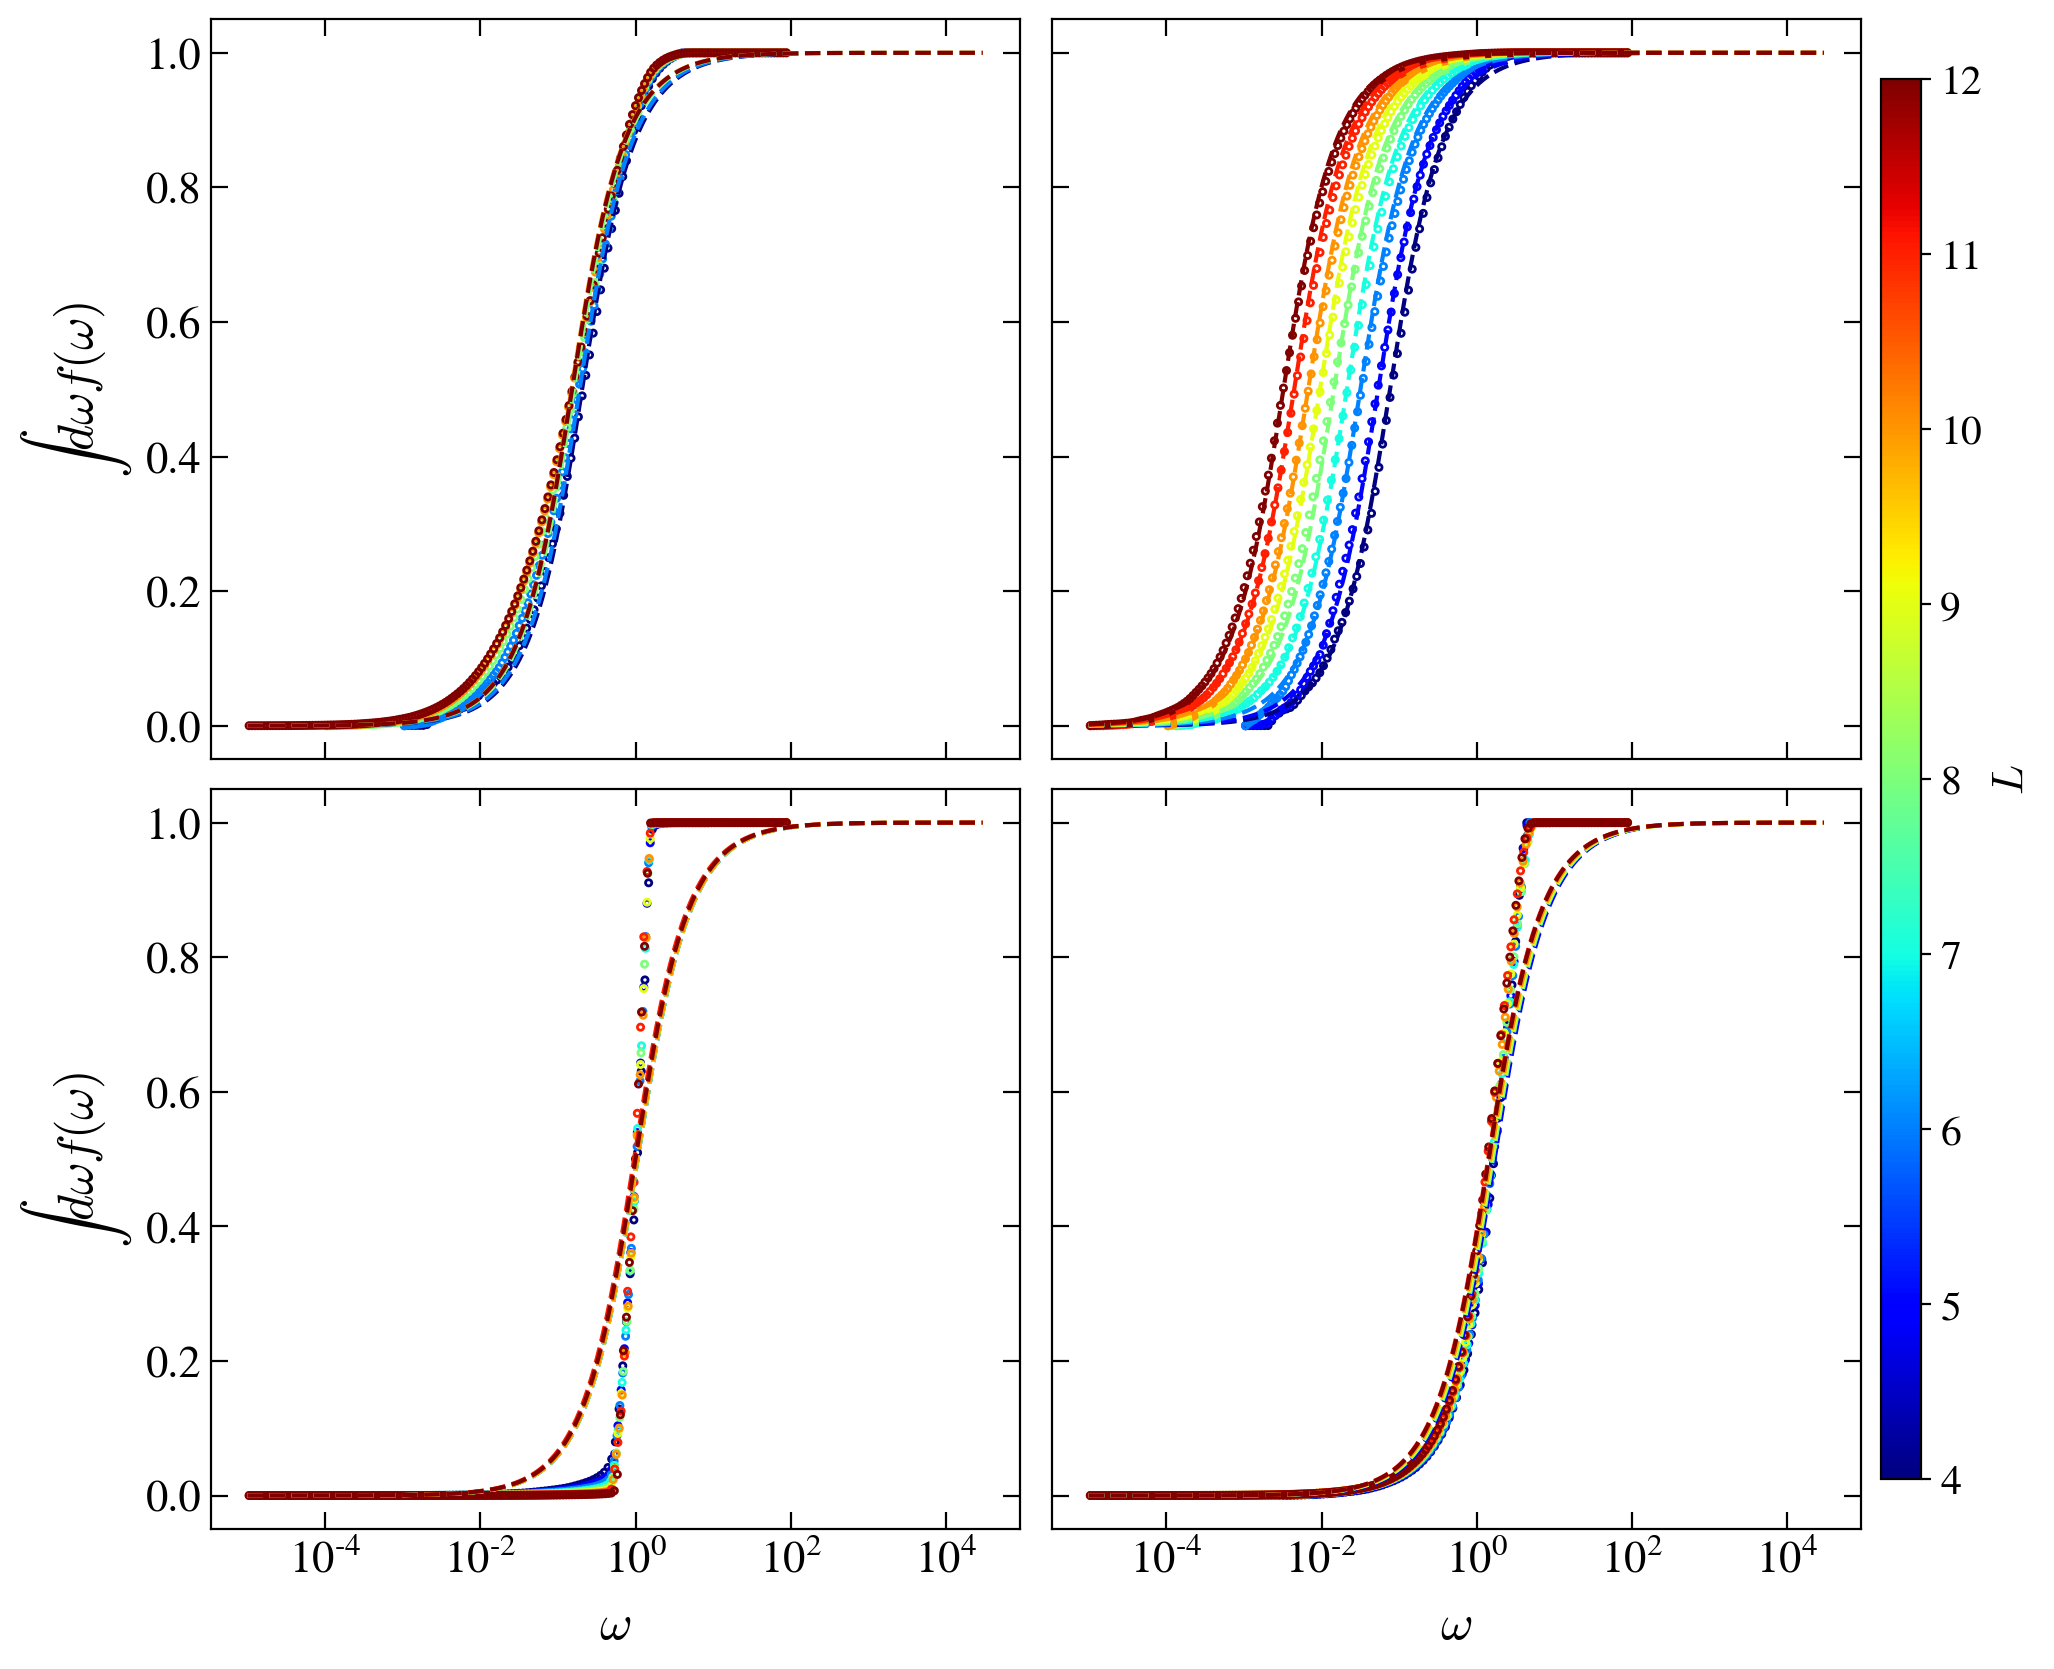

In [655]:

L_total=15

J=1

alfa = 0.84

g0=1
N=3
L = L_total - N
# print(foldername)


INTEGRATE = 1


sizes = np.arange(7, 16, 1) - N
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(vmin=min(sizes),vmax=max(sizes) ))
s_m.set_array([])

fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(10,10), dpi = 200, sharex = True, sharey='row')
axis = np.array(axis).flatten()

for L in sizes:
    col = s_m.to_rgba(L)
    Ltot = L+N
    dim = 2**Ltot
    
    foldername = folder_name(L, alfa, g0)
    if exists(foldername):
        print(foldername)
        name = ""
        for _name_ in os.listdir(foldername):
            # print(_name_)
            if os.path.isfile(os.path.join(foldername, _name_)) and 'hist' in _name_:
                print(_name_)
                name = foldername + _name_
                with h5py.File(name, "r") as file:
                    R = np.array(file.get('realisations'))
                    
                    def plot_spectral(ax, name, use_fit = True, use_double_lorenz = False):
                        omegas = np.array(file.get('omegas'))[0]
                        spec_fun = np.array(file.get(name))[0][1:] * dim
                        omegas = omegas[~np.isnan(spec_fun)]
                        spec_fun = spec_fun[~np.isnan(spec_fun)]
                        if INTEGRATE:
                            spec_fun = integrate.cumulative_trapezoid(spec_fun, omegas)
                            spec_fun = (spec_fun - spec_fun[0]) / (spec_fun[-1] - spec_fun[0])
                            omegas = ( omegas[1:] + omegas[:-1] )/2
                            E_Th = omegas[ np.argmin( np.abs(spec_fun - 0.5) ) ]
                            z = np.logspace( -5, np.log(max(omegas)), 5000)
                            ax.plot(z, arctan(z, E_Th), ls='--', color=col)
                        ax.scatter(omegas, spec_fun, color=col, s=5, facecolor='None')
                        if not INTEGRATE and use_fit:
                            indices = np.where(np.logical_and(omegas >= np.sqrt(Ltot)/dim, omegas < 2))[0]
                            xx = omegas[indices]
                            yy = spec_fun[indices]
                            funn = double_lorenz if use_double_lorenz else lorenz
                            pars, pconv= fit(funn,
                                        xdata = xx,
                                        ydata = yy,
                                        maxfev = 20000)
                            print(L, name, *pars)
                            z = np.linspace(min(xx), max(xx), 5000)
                            ax.plot(z, funn(z, *pars), ls='--', color=col)
                    if L % 2 == 0:
                        plot_spectral(axis[0], 'sz_%d_mean'%(N), use_double_lorenz=True)
                    
                    plot_spectral(axis[1], 'sz_%d_mean'%(Ltot-1))
                    plot_spectral(axis[2], 'sx_l_mean' , use_fit=False)
                    plot_spectral(axis[3], 'sxc_2_mean', use_fit=False)
                    
        
ylab = r"$\int d\omega f(\omega)$" if INTEGRATE else r"$f(\omega)$"
for ii in range(4):
    fig_help.set_plot_elements(axis[ii], ylabel=ylab if ii%2 == 0 else "", xlabel=r"$\omega$" if ii>1 else "", font_size=16, set_legend=False, xscale='log', yscale='linear' if INTEGRATE else 'log')
    

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.02, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$L$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig.subplots_adjust(wspace = 0.04, hspace=0.04)

/Users/rafal.swietek/Library/CloudStorage/CloudMounter-RafałŚwiętek/Shared with me/QSM_MAT_ELEM_STATISTICS/,qsm,Ns=15,N=3,gamm=1.00,g0=1.00,alpha=0.800,h=r,xi=0.200/dh=1.00_0.500/
hist_R=2337.h5


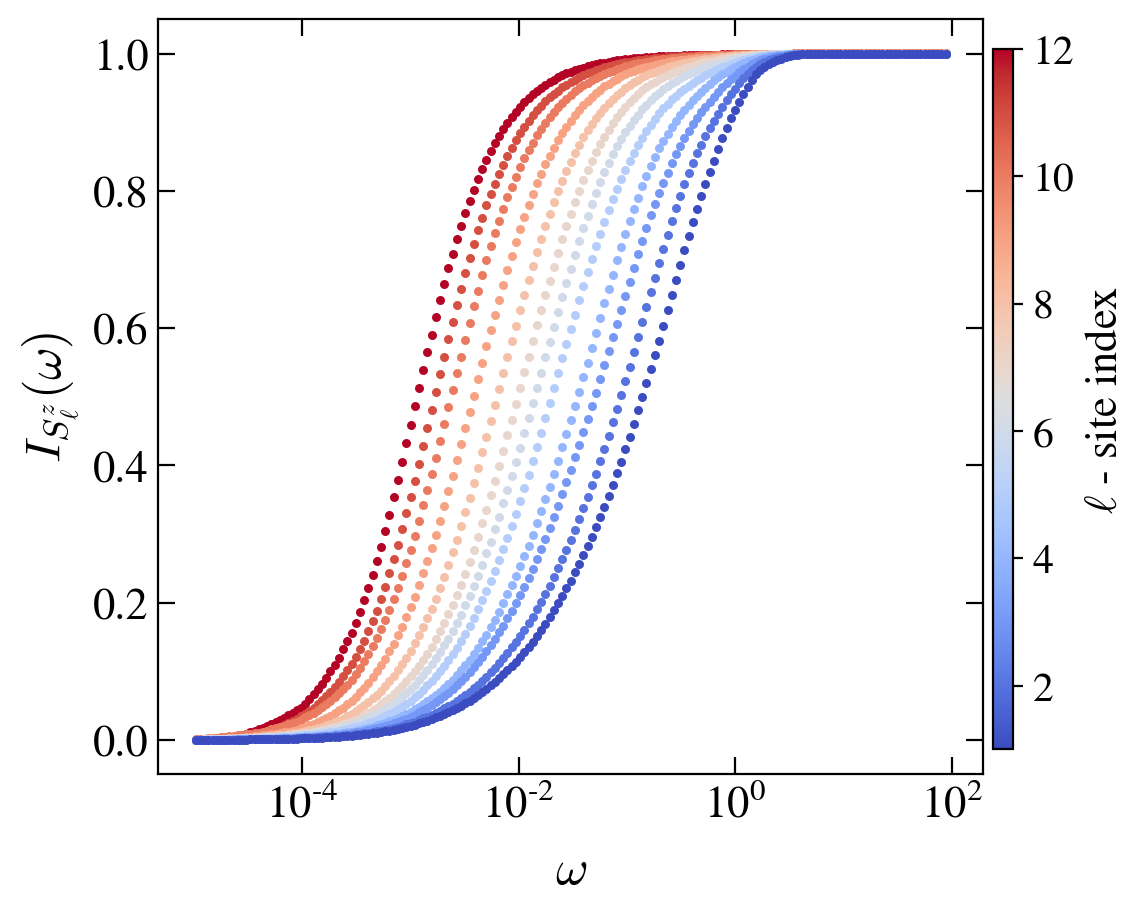

In [644]:

L_total=15

J=1

alfa = 0.8
N=3
L = L_total - N
# print(foldername)


INTEGRATE = 1


sizes = np.arange(8, 16, 1) - N
s_m = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=matplotlib.colors.Normalize(vmin=1,vmax=L_total - N ))
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

dim = 2**L_total

foldername = folder_name(L, alfa, J)
if exists(foldername):
    print(foldername)
    name = ""
    for _name_ in os.listdir(foldername):
        # print(_name_)
        if os.path.isfile(os.path.join(foldername, _name_)) and 'hist' in _name_:
            print(_name_)
            name = foldername + _name_
            with h5py.File(name, "r") as file:
                R = np.array(file.get('realisations'))
            
                
                for ell in np.arange(N, Ltot)[::-1]:
                    col = s_m.to_rgba(ell - N + 1)
                    omegas = np.array(file.get('omegas'))[0]
                    spec_fun = np.array(file.get('sz_%d_mean'%(ell)))[0][1:] * dim
                    if INTEGRATE:
                        spec_fun = integrate.cumulative_trapezoid(spec_fun, omegas)
                        spec_fun = (spec_fun) / (spec_fun[-1] - spec_fun[0])
                        omegas = ( omegas[1:] + omegas[:-1] )/2
                    axis.scatter(omegas, spec_fun, color=col, s=5)
    
ylab = r"$I_{S^z_\ell}(\omega)$" if INTEGRATE else r"$\overline{ |(S^z_\ell)_{nm}|^2 }(\omega)\cdot\rho$"
fig_help.set_plot_elements(axis, ylabel=ylab, xlabel=r"$\omega$", font_size=16, set_legend=False, xscale='log', yscale='linear' if INTEGRATE else 'log')


fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.02, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\ell$ - site index", fontsize=16)
cbar.ax.tick_params(labelsize=15)


[0.68 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.84 0.9
 0.96]
/Users/rafal.swietek/Library/CloudStorage/CloudMounter-RafałŚwiętek/Shared with me/QSM_MAT_ELEM_STATISTICS/,qsm,Ns=7,N=3,gamm=1.00,g0=1.00,alpha=0.680,h=r,xi=0.200/dh=1.00_0.500/
hist_R=9279.h5
/Users/rafal.swietek/Library/CloudStorage/CloudMounter-RafałŚwiętek/Shared with me/QSM_MAT_ELEM_STATISTICS/,qsm,Ns=8,N=3,gamm=1.00,g0=1.00,alpha=0.680,h=r,xi=0.200/dh=1.00_0.500/
hist_R=5003.h5
/Users/rafal.swietek/Library/CloudStorage/CloudMounter-RafałŚwiętek/Shared with me/QSM_MAT_ELEM_STATISTICS/,qsm,Ns=9,N=3,gamm=1.00,g0=1.00,alpha=0.680,h=r,xi=0.200/dh=1.00_0.500/
hist_R=7030.h5
/Users/rafal.swietek/Library/CloudStorage/CloudMounter-RafałŚwiętek/Shared with me/QSM_MAT_ELEM_STATISTICS/,qsm,Ns=10,N=3,gamm=1.00,g0=1.00,alpha=0.680,h=r,xi=0.200/dh=1.00_0.500/
hist_R=641.h5
/Users/rafal.swietek/Library/CloudStorage/CloudMounter-RafałŚwiętek/Shared with me/QSM_MAT_ELEM_STATISTICS/,qsm,Ns=11,N=3,gamm=1.00,g0=1.

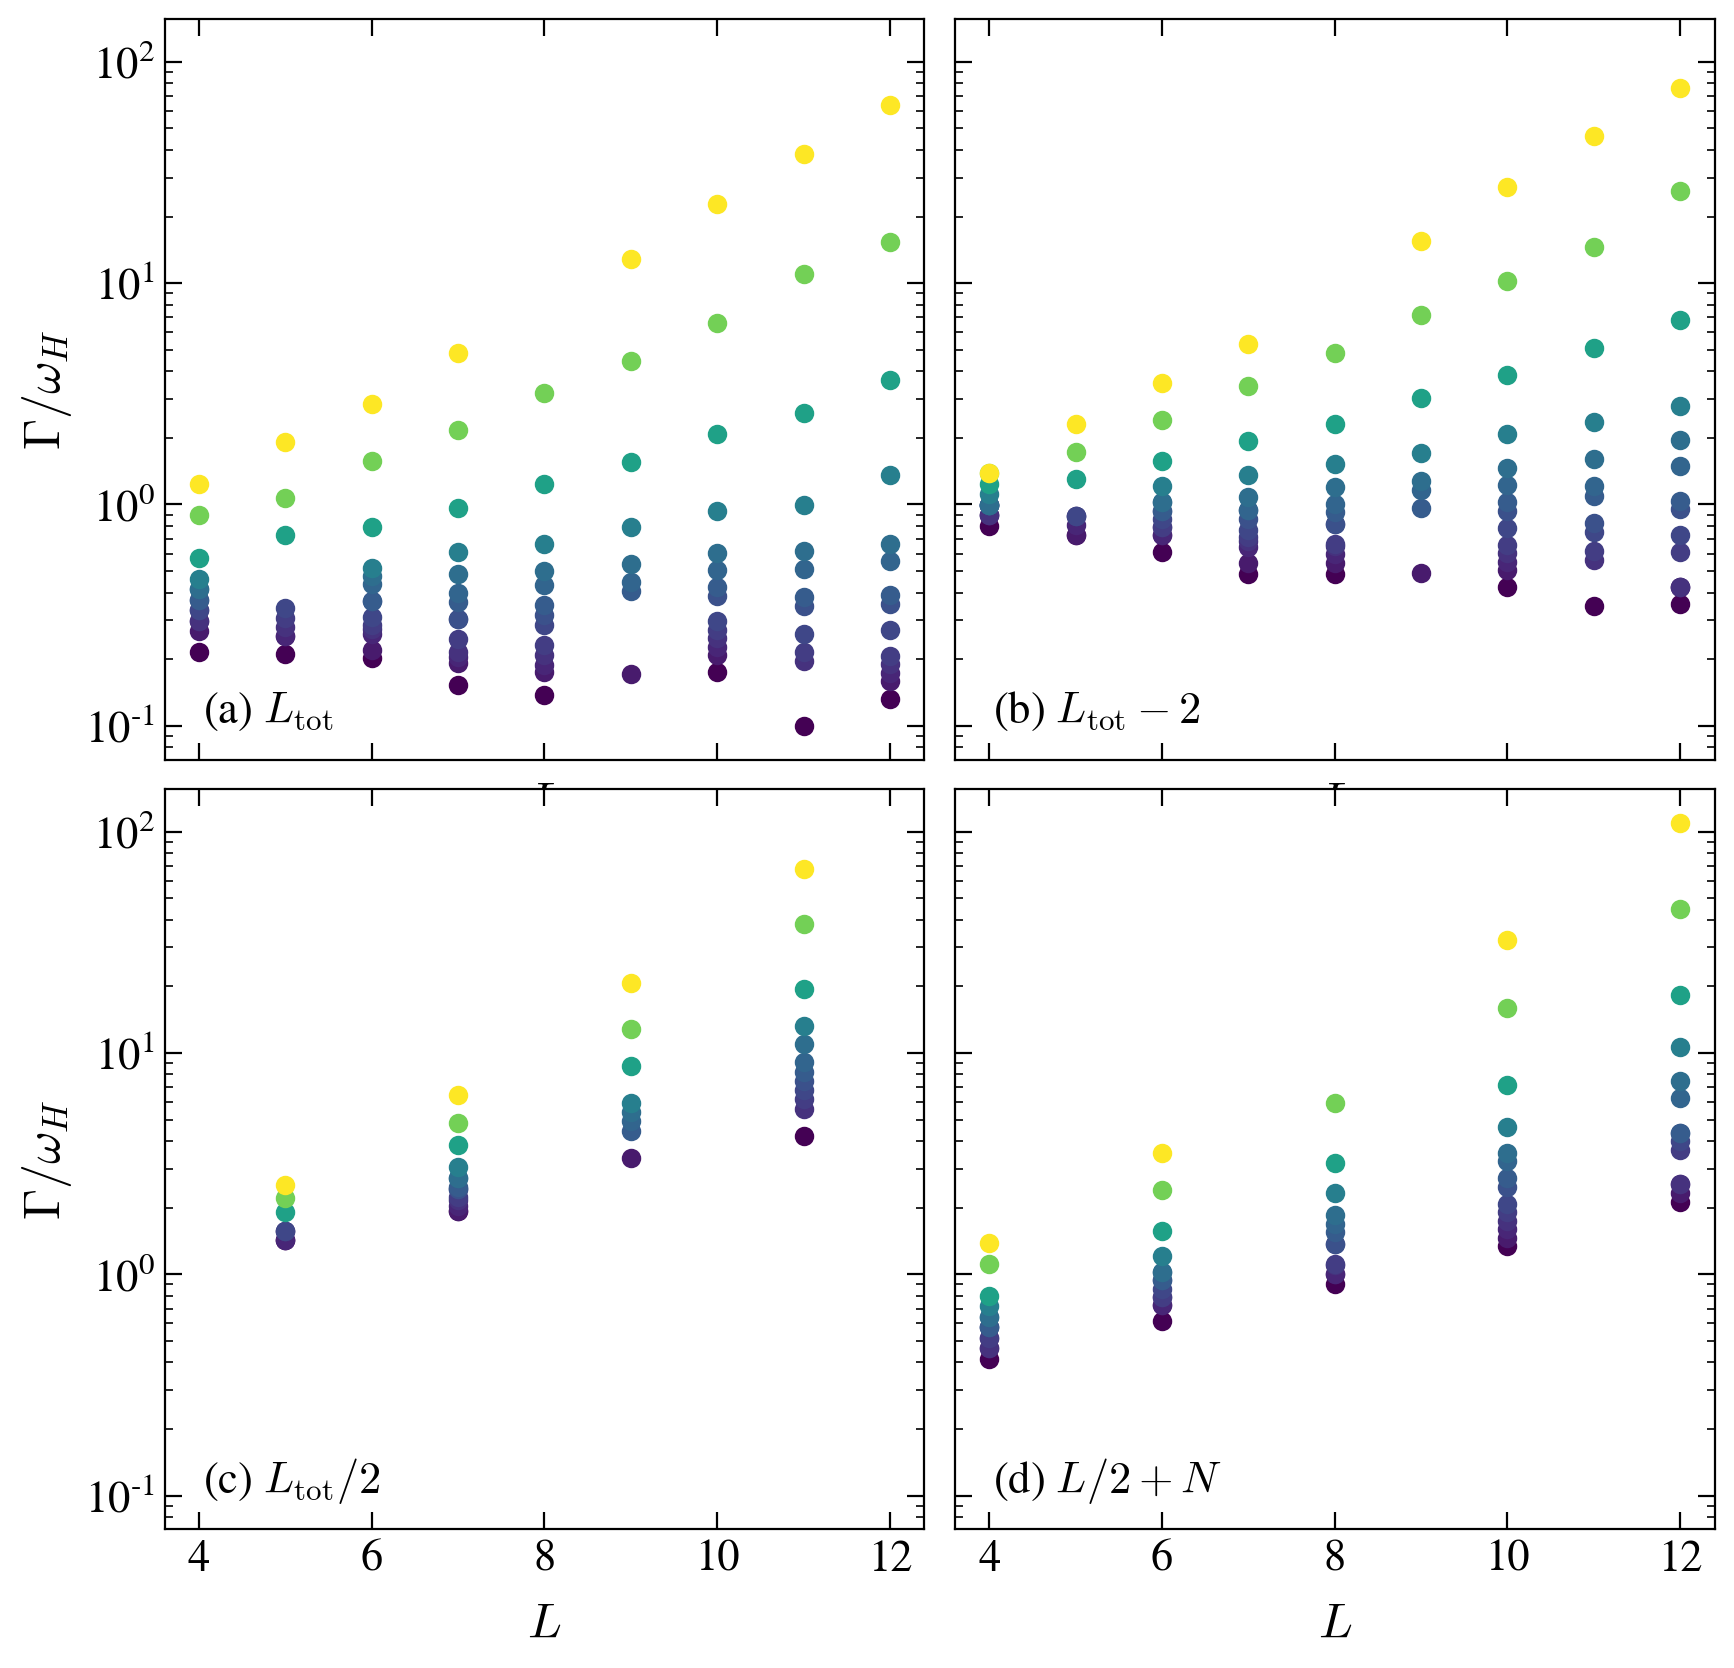

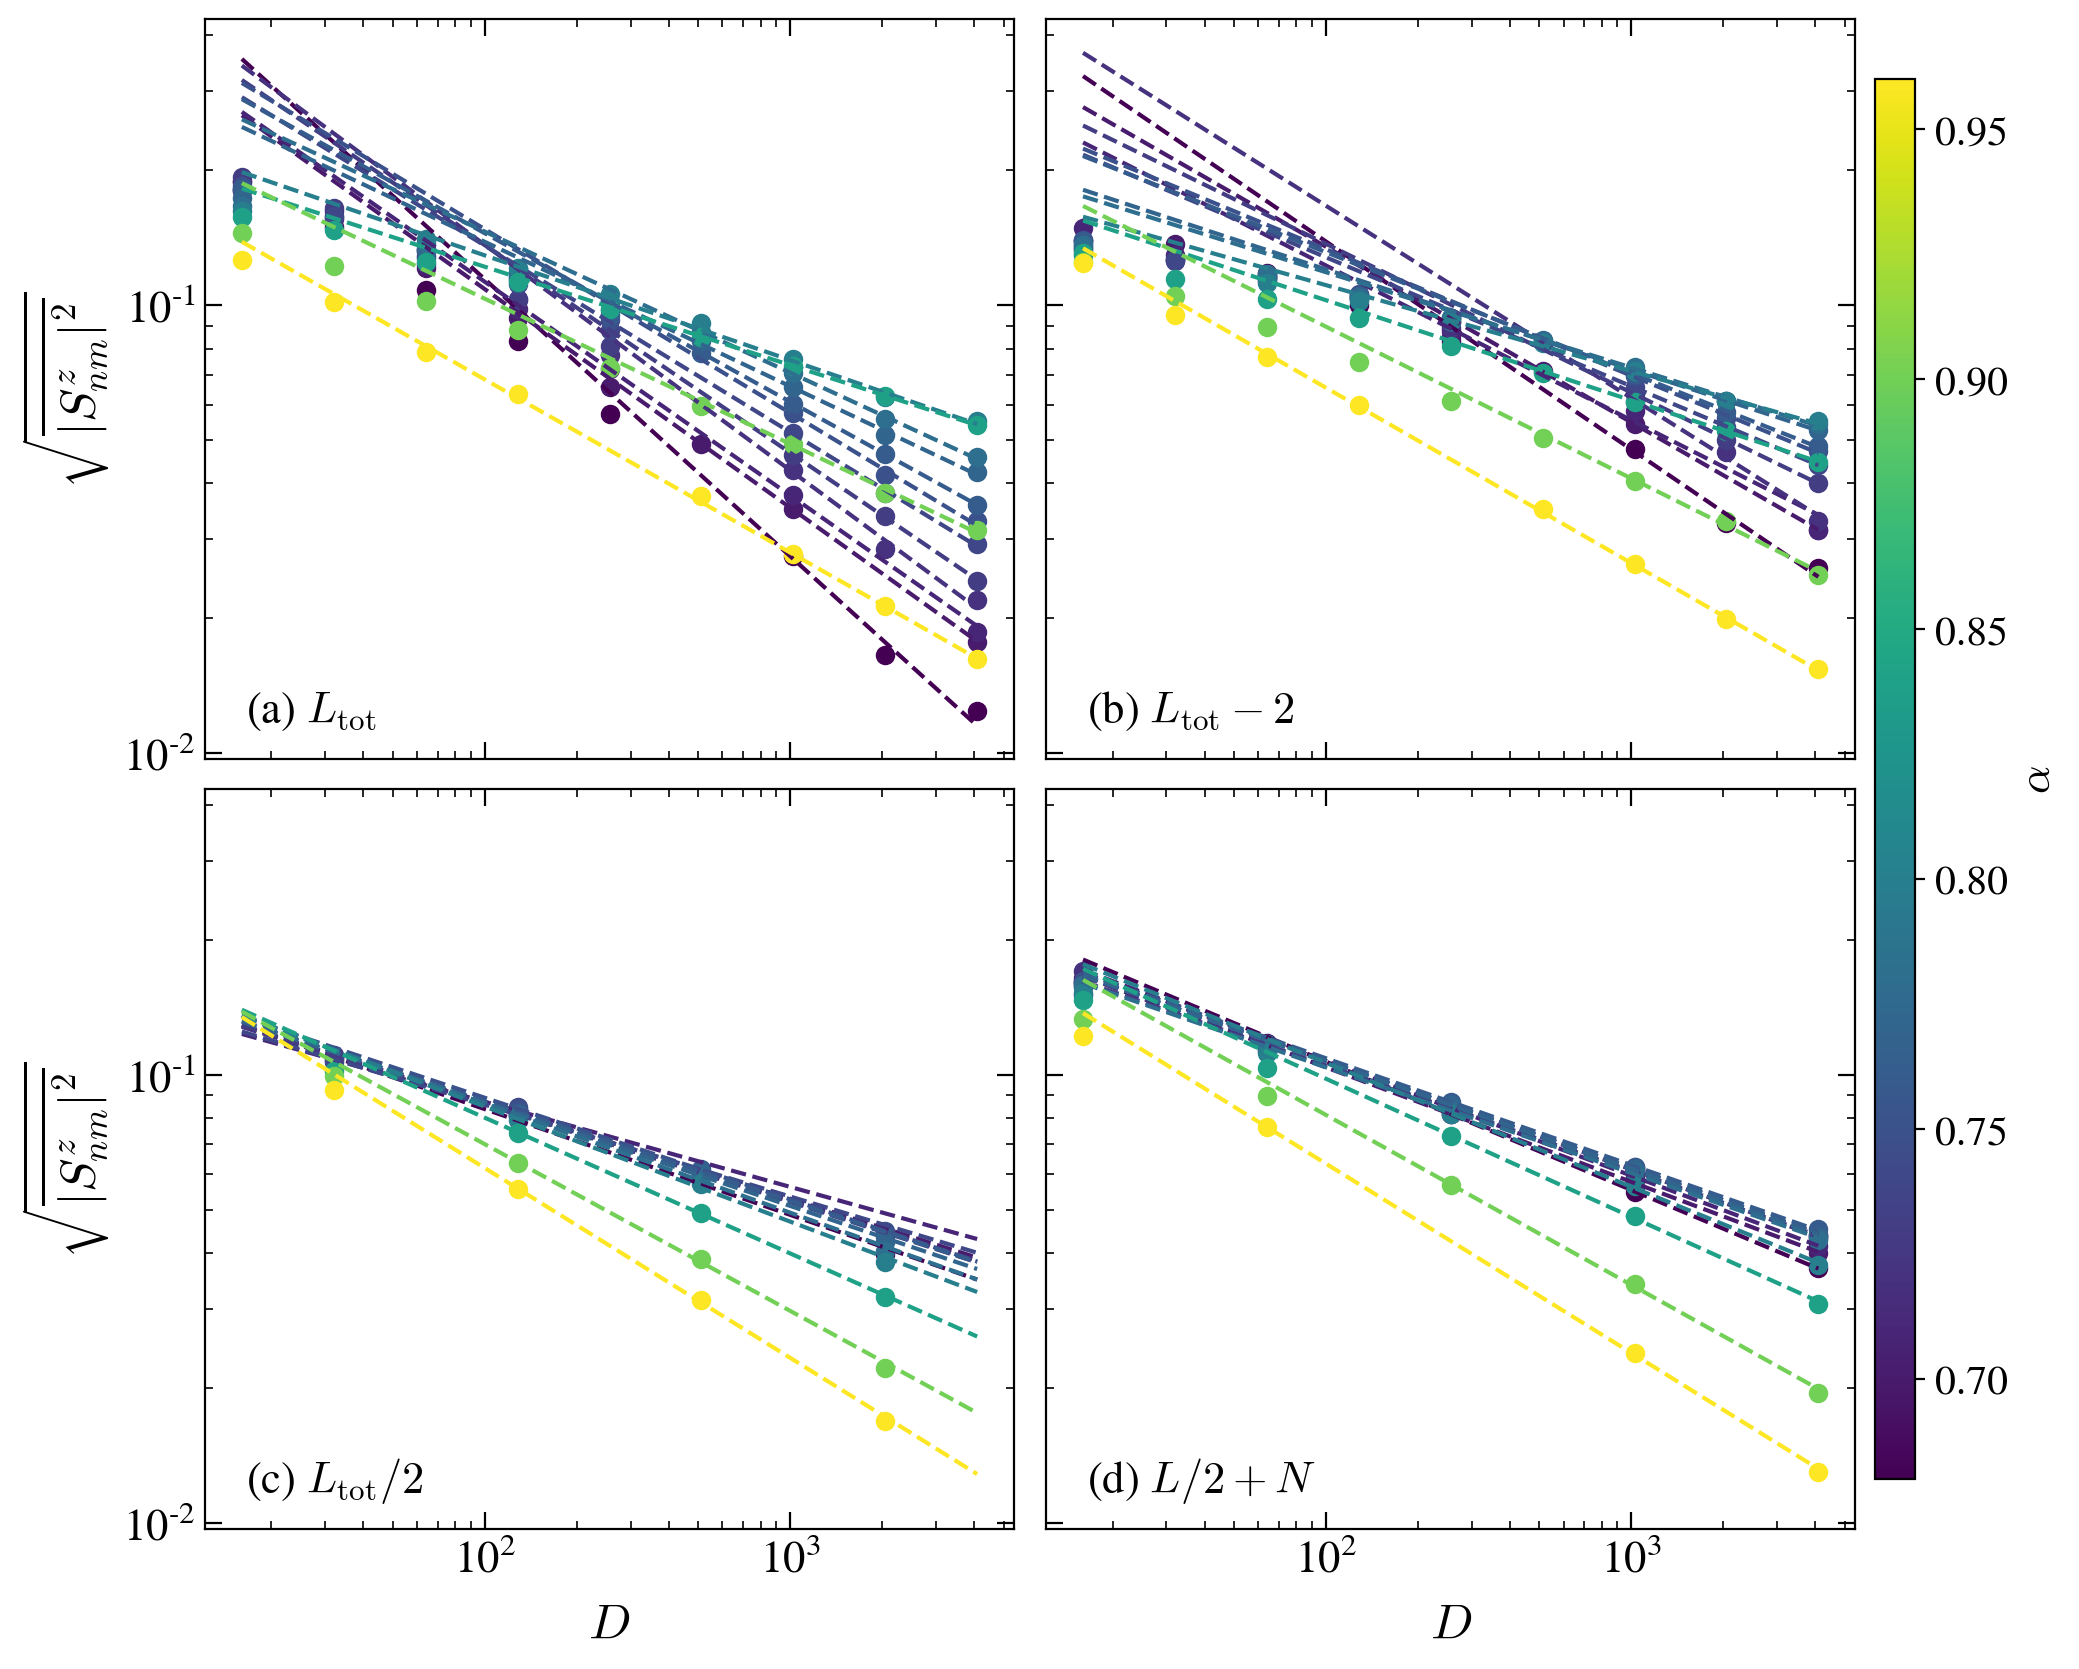

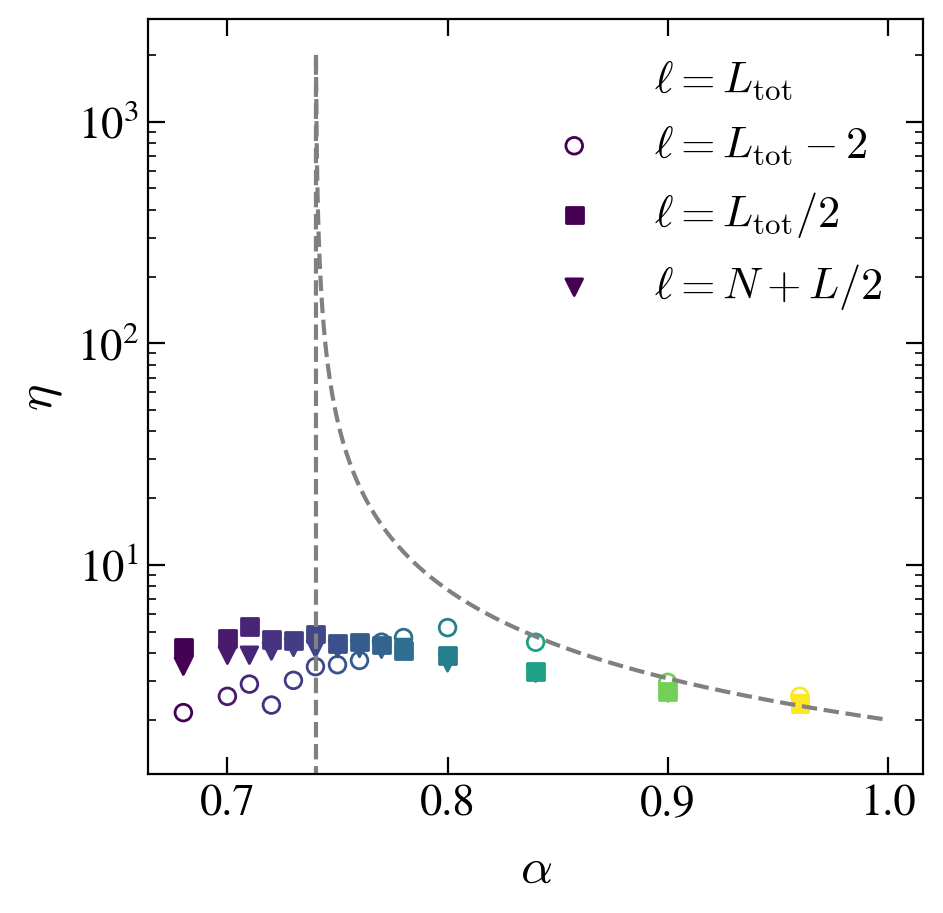

In [653]:

L_total=15

J=1

alfa = 0.84

g0=1
N=3
L = L_total - N
# print(foldername)

alfas = [0.68, *np.arange(0.7, 0.79, 0.01), 0.8, 0.84, 0.9, 0.96]
alfas = np.round(np.array(alfas), 2)
print(alfas)


sizes = np.arange(7, 16, 1) - N
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(vmin=min(alfas),vmax=max(alfas) ))
s_m.set_array([])

fig1, axis = plt.subplots( nrows=2, ncols=2, figsize=(10,10), dpi = 200, sharex = True, sharey=True)
axis = np.array(axis).flatten()

fig2, axis2 = plt.subplots( nrows=2, ncols=2, figsize=(10,10), dpi = 200, sharex = True, sharey=True)
axis2 = np.array(axis2).flatten()

fig3, axis3 = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)
axis = np.array(axis).flatten()

colors = []
eta_L = []
eta_L2 = []
eta_L_2 = []
eta_L_2_N = []

labels = [r"(a) $L_{\rm tot}$", r"(b) $L_{\rm tot}-2$", r"(c) $L_{\rm tot}/2$", r"(d) $L/2 + N}$"]
for alfa in alfas:
    col = s_m.to_rgba(alfa)
    colors.append(col)
    spec_at_plateau_L = []
    spec_at_plateau_L2= []
    spec_at_plateau_L_2 = []
    spec_at_plateau_L_2_N = []
    E_Th_L = []
    E_Th_L2 = []
    E_Th_L_2 = []
    E_Th_L_2_N = []
    sizes_found = []
    for L in sizes:
        Ltot = L+N
        dim = 2**Ltot
        
        foldername = folder_name(L, alfa, g0)
        if exists(foldername):
            print(foldername)
            name = ""
            for _name_ in os.listdir(foldername):
                # print(_name_)
                if os.path.isfile(os.path.join(foldername, _name_)) and 'hist' in _name_:
                    print(_name_)
                    name = foldername + _name_
                    try:
                        with h5py.File(name, "r") as file:
                            sizes_found.append(L)
                            R = np.array(file.get('realisations'))
                            
                            def get_spec_for_scaling(name):
                                omegas = np.array(file.get('omegas'))[0]
                                spec_fun = np.array(file.get(name))[0][1:]
                                omegas = omegas[~np.isnan(spec_fun)]
                                spec_fun = spec_fun[~np.isnan(spec_fun)]
                                
                                int_spec_fun = integrate.cumulative_trapezoid(spec_fun, omegas)
                                int_spec_fun = (int_spec_fun - int_spec_fun[0]) / (int_spec_fun[-1] - int_spec_fun[0])
                                E_Th = omegas[ np.argmin( np.abs(int_spec_fun - 0.5) ) ]
                                
                                idx_spec = min(range(len(omegas)), key=lambda i: abs(omegas[i] - np.sqrt(G * np.sqrt(L) / dim)))
                                spec_fun = np.array(file.get(name))[0][1:]
                                spec_fun = spec_fun[~np.isnan(spec_fun)]
                                return E_Th, np.sqrt(  np.mean(spec_fun[ idx_spec - 5 : idx_spec + 5])  )
                            if L % 2 == 0:
                                E_Th, _spec = get_spec_for_scaling('sz_%d_mean'%(N+L//2))
                                spec_at_plateau_L_2_N.append( _spec );  E_Th_L_2_N.append(E_Th)
                            else:
                                spec_at_plateau_L_2_N.append( np.nan );  E_Th_L_2_N.append(np.nan)
                            if Ltot % 2 == 0:
                                E_Th, _spec = get_spec_for_scaling('sz_%d_mean'%(Ltot//2))
                                spec_at_plateau_L_2.append( _spec );  E_Th_L_2.append(E_Th)
                            else:
                                spec_at_plateau_L_2.append( np.nan );  E_Th_L_2.append(np.nan)
                            
                            E_Th, _spec = get_spec_for_scaling('sz_%d_mean'%(Ltot-1))
                            spec_at_plateau_L.append( _spec );  E_Th_L.append(E_Th)
                            
                            E_Th, _spec = get_spec_for_scaling('sz_%d_mean'%(Ltot-3))
                            spec_at_plateau_L2.append( _spec );  E_Th_L2.append(E_Th)
                    except TimeoutError:
                        print(f"ERROR\n", name, "FileERROR")
                        
    sizes_found = np.array(sizes_found)
    if sizes_found.size > 0:
        spec_at_plateau_L = np.array(spec_at_plateau_L)
        spec_at_plateau_L2 = np.array(spec_at_plateau_L2)
        spec_at_plateau_L_2 = np.array(spec_at_plateau_L_2)
        spec_at_plateau_L_2_N = np.array(spec_at_plateau_L_2_N)
        
        _dimsX = 2**sizes_found
        print(spec_at_plateau_L, sizes)
        dims_dense = np.logspace(min(sizes_found), max(sizes_found), 100, base=2)
        dims = _dimsX[~np.isnan(spec_at_plateau_L)]
        spec_at_plateau_L = spec_at_plateau_L[~np.isnan(spec_at_plateau_L)]
        if spec_at_plateau_L.size > 1:
            pars, pconv= fit(matelem_fit,
                        xdata = dims[-3:],
                        ydata = spec_at_plateau_L[-3:],
                        maxfev = 20000)
            _etaX = np.abs(pars[-1]); 
            if _etaX > 1e6: _etaX = np.nan
            eta_L.append(_etaX)
        else:
            eta_L.append(np.nan)
        axis[0].scatter(sizes_found, E_Th_L / (np.sqrt(sizes_found) / _dimsX), color = col)
        axis2[0].scatter(dims, spec_at_plateau_L, color = col)
        axis2[0].plot(dims_dense, matelem_fit(dims_dense, *pars), color = col, ls='--')
        
        dims = _dimsX[~np.isnan(spec_at_plateau_L2)]
        spec_at_plateau_L2 = spec_at_plateau_L2[~np.isnan(spec_at_plateau_L2)]
        if spec_at_plateau_L2.size > 1:
            pars, pconv= fit(matelem_fit,
                        xdata = dims[-3:],
                        ydata = spec_at_plateau_L2[-3:],
                        maxfev = 20000)
            _etaX = np.abs(pars[-1]); 
            if _etaX > 1e6: _etaX = np.nan
            eta_L2.append(_etaX)
            axis2[1].plot(dims_dense, matelem_fit(dims_dense, *pars), color = col, ls='--')
        else:
            eta_L2.append(np.nan)
        axis[1].scatter(sizes_found, E_Th_L2 / (np.sqrt(sizes_found) / _dimsX), color = col)
        axis2[1].scatter(dims, spec_at_plateau_L2, color = col)
        
        dims = _dimsX[~np.isnan(spec_at_plateau_L_2)]
        spec_at_plateau_L_2 = spec_at_plateau_L_2[~np.isnan(spec_at_plateau_L_2)]
        if spec_at_plateau_L_2.size > 1:
            pars, pconv= fit(matelem_fit,
                        xdata = dims[-3:],
                        ydata = spec_at_plateau_L_2[-3:],
                        maxfev = 20000)
            _etaX = np.abs(pars[-1]); 
            if _etaX > 1e6: _etaX = np.nan
            eta_L_2.append(_etaX)
            axis2[2].plot(dims_dense, matelem_fit(dims_dense, *pars), color = col, ls='--')
        else:
            eta_L_2.append(np.nan)
        axis[2].scatter(sizes_found, E_Th_L_2 / (np.sqrt(sizes_found) / _dimsX), color = col)
        axis2[2].scatter(dims, spec_at_plateau_L_2, color = col)
        
        dims = _dimsX[~np.isnan(spec_at_plateau_L_2_N)]
        spec_at_plateau_L_2_N = spec_at_plateau_L_2_N[~np.isnan(spec_at_plateau_L_2_N)]
        if spec_at_plateau_L_2_N.size > 1:
            pars, pconv= fit(matelem_fit,
                        xdata = dims[-3:],
                        ydata = spec_at_plateau_L_2_N[-3:],
                        maxfev = 20000)
            _etaX = np.abs(pars[-1]); 
            if _etaX > 1e6: _etaX = np.nan
            eta_L_2_N.append(_etaX)
            axis2[3].plot(dims_dense, matelem_fit(dims_dense, *pars), color = col, ls='--')
        else:
            eta_L_2_N.append(np.nan)
        axis[3].scatter(sizes_found, E_Th_L_2_N / (np.sqrt(sizes_found) / _dimsX), color = col)
        axis2[3].scatter(dims, spec_at_plateau_L_2_N, color = col)
    else:
        eta_L.append(np.nan)
        eta_L2.append(np.nan)
        eta_L_2.append(np.nan)
        eta_L_2_N.append(np.nan)
axis3.scatter(alfas, eta_L,     marker = next(markers), color=colors, facecolor='None', label=r"$\ell=L_{\rm tot}$")
axis3.scatter(alfas, eta_L2,    marker = next(markers), color=colors, facecolor='None', label=r"$\ell=L_{\rm tot}-2$")
axis3.scatter(alfas, eta_L_2,   marker = next(markers), color=colors, label=r"$\ell=L_{\rm tot}/2$")
axis3.scatter(alfas, eta_L_2_N, marker = next(markers), color=colors, label=r"$\ell=N+L/2$")

zalfaz = np.linspace(0.68, 1, 1000)
axis3.plot(zalfaz, 2 / (1 - np.log(zalfaz) / np.log(0.74)), color='gray', ls='--')
for ii in range(4):
    fig_help.set_plot_elements(axis[ii], ylabel=r"$\Gamma/\omega_H$" if ii%2 == 0 else "", xlabel=r"$L$" if iie>1 else "", font_size=16, set_legend=False, xscale='linear', yscale='log')
    fig_help.set_plot_elements(axis2[ii], ylabel=r"$\sqrt{\overline{|S^z_{nm}|^2}}$" if ii%2 == 0 else "", xlabel=r"$D$" if ii>1 else "", font_size=16, set_legend=False, xscale='log', yscale='log')
    axis[ii].annotate(labels[ii],     fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')
    axis2[ii].annotate(labels[ii],     fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction')
    

fig_help.set_plot_elements(axis3, ylabel=r"$\eta$", xlabel=r"$\alpha$", font_size=16, set_legend=True, xscale='linear', yscale='log')

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.02, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\alpha$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig2.subplots_adjust(right=0.95)
cbar_ax = fig2.add_axes([0.96, 0.15, 0.02, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig2.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\alpha$", fontsize=16)
cbar.ax.tick_params(labelsize=15)


fig1.subplots_adjust(wspace = 0.04, hspace=0.04)
fig2.subplots_adjust(wspace = 0.04, hspace=0.04)